In [2]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop.frq.strat'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

## Explore 1000 genomes data

### Algorithm creation

In [3]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product
from joblib import Parallel, delayed
from functools import partial
import sys
import mlflow
import submitit
import random
from mlflow.tracking import MlflowClient
from datetime import datetime
from zoneinfo import ZoneInfo
intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
artifact_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs'
sys.path.append(code_dir)
import simulations.genomes1000_sim as sim_functions
import algorithms.SCoNE as SCoNE
import algorithms.SCoNE_noUC as SCoNE_noUC
import algorithms.MLFlowWrapper as MLFlowWrapper
import evaluation.cluster_evaluation as cluster_evaluation
import importlib
importlib.reload(SCoNE)
importlib.reload(sim_functions)
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.25,0.5,0.75,1]
num_markers_assoc_list = [100,500]
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
tuning = False # to run sparsity tuning step
testing = True # to run testing step
# PARAMETERS
np.random.seed(42)

# read in Z
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{sim_output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()



In [13]:
ps=True
e=1
g=10
dataset=0

# genetic_subgroups, phenotypic_subgroups, C, iid_order, markers_assoc_dict, clinical_assoc_df = sim_functions.sun_generate_sim_data(bfile_path, maf_by_superpop_filepath,igsr_samples_filepath,
#                           intermediate_plink_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),sim_output_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),
#                           ps,g,e,300,100,10,100, 2)
output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
with open(f'{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl','rb') as f:
    simulation_metadata = pickle.load(f)
iid_order = simulation_metadata['iid_order']
fam_df = pd.read_csv(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
iid_index = fam_df[fam_df['IID'].isin(iid_order)].index # some samples removed due to overlap btwn subgroups, need correct length

G = np.loadtxt(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.raw',  usecols=range(6, 100+6), dtype=np.int8, skiprows=1) # TODO: switch back to 10k, and change
# G = (G>0).astype(np.int8). - binarize

# create random inits
# Use Gamma(shape=2, scale=mean/2) -> mean = 2*scale = desired mean - how to do this with Z added in?
W = np.random.uniform(low=0.1,high=1,size=(G.shape[0], rank))# aorund 0 to 1e-2
H_G = np.random.uniform(low=0.1,high=1,size=(G.shape[1], rank))
H_C = np.random.uniform(low=0.1,high=1,size=(100, rank)) # fixed: 100 clinical vars
U_G = np.random.uniform(low=0.1,high=1,size=(G.shape[1], Z.shape[1]))
U_C = np.random.uniform(low=0.1,high=1,size=(100, Z.shape[1]))
# if C_loss_type and G_loss_type are None, shouldn't be any change in factor matrices from random
factor_matrices, loss_function = SCoNE.alternating_opt(G[iid_index,:],C,Z[iid_index,:],
    W[iid_index,:], H_G, H_C, U_G, U_C,lambda_W=0, lambda_H_G=0, lambda_H_C=0, lambda_Gloss=0.5,
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True, C_loss_type='kl_div', G_loss_type=None,min_outer=0)

In [14]:
W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
        .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
ground_truth = {"W":W_true}


In [15]:
cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)

{'purity': 0.8200956937799043,
 'norm_cond_entropy': 0.6641397170370558,
 'nmi': 0.2639464077067433}

In [16]:
C.sum()/G.sum()

0.14364134296002576

# Working on test code

In [4]:
# test code setup

# DEFINE PATHS
intermediate_plink_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
graph_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
# DEFINE PATHS


# read in 
G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)

In [6]:
from collections import defaultdict


In [18]:
        
genetic_subgroups = (data['genetic_subgroups'].pivot(index='IID',columns='genetic_subgroup',values='subgroup')
    .reindex(data['iid_order']).to_numpy().astype(int))
genetic_subgroups

array([[0, 1],
       [0, 0],
       [0, 0],
       ...,
       [0, 0],
       [0, 0],
       [0, 1]])

In [25]:
# genetic markers and phenotypic subgroup
ps_list = [True,False]
e_list = [0.25, 0.50, 0.75, 1]
g_list = [10] # g represents the number of linked markers
dataset_list = range(11) # 11 random datasets for each combination
overall = []
for ps, g, dataset in list(product(ps_list,g_list,dataset_list)):
    print(f'ps: {ps}, g:{g}, dataset:{dataset}')
    e_corr = defaultdict(list) # correlation of phenotypic gi w/ linked snps (take mean over two gi subgroups) for different e values
    e_corr_genosubgp_phenosubgp = defaultdict(list)
    for e in e_list:
        output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
        with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
            data = pickle.load(f)
        fam_df = pd.read_csv(f'{bfile_path}.fam',sep='\s+',header=None)
        fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
        iid_index = fam_df[fam_df['IID'].isin(data['iid_order'])].index # some samples removed due to overlap btwn subgroups, need correct length
            
        phenotypic_subgroups = (data['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
            .reindex(data['iid_order']).to_numpy().astype(int))
        phenotypic_subgroups_centered = (phenotypic_subgroups - phenotypic_subgroups.mean(axis=0)) / phenotypic_subgroups.std(axis=0, ddof=1)

        # get correlation between genotypic and phenotypic subgroup
        genetic_subgroups = (data['genetic_subgroups'].pivot(index='IID',columns='genetic_subgroup',values='subgroup')
        .reindex(data['iid_order']).to_numpy().astype(int))
        for subgp in range(2):
            e_corr_genosubgp_phenosubgp[e].append(np.corrcoef(phenotypic_subgroups[:,subgp], genetic_subgroups[:,subgp])[0, 1])
        

#         # correlation matrix: (n_phenotypic_subgroupscols × n_Gcols)
#         G_centered = (G[iid_index,:] - G[iid_index,:].mean(axis=0)) / G[iid_index,:].std(axis=0, ddof=1)
#         corr = phenotypic_subgroups_centered.T @ G_centered / (G.shape[0] - 1)
#         for k,v in data["markers_assoc"].items():
#             gi_idx = bim_df[bim_df['SNP'].isin(v)].index.values.tolist() # get index of true linked markers
#             e_corr[e].append(corr[k,gi_idx])
#             gi_corr = corr[k,gi_idx].mean()
#             rand_idx = np.random.choice([i for i in range(G.shape[1]) if i not in gi_idx], size=g, replace=False) 
#             rand_corr = corr[k,rand_idx].mean()
#             non_gi_corr = corr[k+2,gi_idx].mean()
#             # correlation w/ linked snps greater than random snps for genetically informed (gi) subgroup
#             assert gi_corr>rand_corr
#             # correlation of linked snps w/ gi subgroup greater than that with non-gi phenotypic subgroup (compare gi=0 with non-gi=2 and gi=1 with non-gi=3)
#             assert gi_corr>non_gi_corr

#     print([np.mean(e_corr[i]) for i in e_corr.keys()])
#     overall.append(np.mean(np.concatenate(e_corr[1]))>np.mean(np.concatenate(e_corr[0.25])))
# # assert that more often than not, stronger correlation when e=1 vs. 0.25
# assert (sum(overall) / len(overall))>0.5

ps: True, g:10, dataset:0
ps: True, g:10, dataset:1
ps: True, g:10, dataset:2
ps: True, g:10, dataset:3
ps: True, g:10, dataset:4
ps: True, g:10, dataset:5
ps: True, g:10, dataset:6
ps: True, g:10, dataset:7
ps: True, g:10, dataset:8
ps: True, g:10, dataset:9
ps: True, g:10, dataset:10
ps: False, g:10, dataset:0
ps: False, g:10, dataset:1
ps: False, g:10, dataset:2
ps: False, g:10, dataset:3
ps: False, g:10, dataset:4
ps: False, g:10, dataset:5
ps: False, g:10, dataset:6
ps: False, g:10, dataset:7
ps: False, g:10, dataset:8
ps: False, g:10, dataset:9
ps: False, g:10, dataset:10


In [26]:
e_corr_genosubgp_phenosubgp

defaultdict(list,
            {0.25: [0.7604425882920426, 0.788757614621172],
             0.5: [0.8262910164966076, 0.9688920828982721],
             0.75: [0.9950644534635904, 1.0],
             1: [0.9704080218121839, 0.9853372035345742]})

# ML Flow 

In [4]:
import mlflow
from mlflow.tracking import MlflowClient

In [5]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_tuning")
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs['params.ps'] = all_runs["params.ps"].map({"True": True, "False": False}).astype("boolean")  # columns you want as bools (nullable)
all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs['G_plus_C_loss'] = all_runs['metrics.G_loss'] + all_runs['metrics.C_loss']
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]
idx = all_runs.groupby(["run_name", "ps", "e", "g"])["G_plus_C_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","run_name", "ps", "e", "g"])
      .reset_index(drop=True)
)

In [6]:
all_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,cpu time,U_G_sparsity,H_C_sparsity,nmi,...,lambda_Gloss,min_outer,tags.trainer,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.type,tags.num_epochs,experiment_name,G_plus_C_loss
0,d26a2356aefb477ebe76d587ca27f029,793190699563717912,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:32:10.606000+00:00,2025-10-01 20:35:29.032000+00:00,332.476514,0.00,29.666667,4.683278e-01,...,0.039837220436358664,5,<function alternating_opt at 0x7f0cf4df0b80>,anewbury,sHNMF,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,50,7,144981.045225
1,a2857fdd216a47e88df0a4c71cd9844d,793190699563717912,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:32:09.867000+00:00,2025-10-01 20:32:44.344000+00:00,57.653983,3.68,0.000000,-4.443258e-16,...,0.039837220436358664,5,<function alternating_opt at 0x7fea42439b80>,anewbury,SCoNE,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,6,7,148381.949278
2,bb2ca4e287dd4ef38a158388ae3c27fd,793190699563717912,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:32:09.329000+00:00,2025-10-01 20:32:18.851000+00:00,15.679061,0.00,0.000000,-4.443258e-16,...,0.039837220436358664,5,<function alternating_opt at 0x7faaaeb74b80>,anewbury,SCoNE(Fro),/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,6,7,31245.739513
3,63bab2f553ba4b17a6fb1c518db3746f,793190699563717912,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:32:03.060000+00:00,2025-10-01 20:33:14.996000+00:00,130.186287,0.00,30.000000,4.650253e-01,...,0.039837220436358664,5,<function alternating_opt at 0x7f96f766eb80>,anewbury,sHNMF,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,50,7,144981.963778
4,fda7058592fb494dbe7a18a74a96bdfd,793190699563717912,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:32:03.060000+00:00,2025-10-01 20:32:06.817000+00:00,5.024499,0.00,100.000000,-4.443258e-16,...,0.039837220436358664,5,<function alternating_opt at 0x7fe250a68b80>,anewbury,SCoNE(Fro),/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,6,7,31245.739513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,d87159323b594105af89180fa3110fd0,318756224924479436,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:19:59.178000+00:00,2025-10-01 20:20:02.405000+00:00,4.371282,0.00,0.000000,-2.227355e-16,...,0.02352451490638275,5,<function alternating_opt at 0x7f2540321b80>,anewbury,SCoNE(Fro),/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,6,0,38186.939965
1508,e6f41c546cd744e5967df2001a8ac93c,318756224924479436,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:19:59.178000+00:00,2025-10-01 20:21:25.825000+00:00,158.019710,4.76,50.666667,2.772284e-01,...,0.02352451490638275,5,<function alternating_opt at 0x7fbe32c9ab80>,anewbury,SCoNE,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,50,0,146352.815120
1509,f1ca0eadb6ed4f0aac22d37a2b8e17d6,318756224924479436,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:19:59.178000+00:00,2025-10-01 20:21:24.718000+00:00,155.718542,4.58,49.666667,2.670893e-01,...,0.02352451490638275,5,<function alternating_opt at 0x7fdd6312eb80>,anewbury,SCoNE,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,50,0,146354.697103
1510,f2c63b530a0c4dfab803b0a5e873106d,318756224924479436,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-01 20:19:59.178000+00:00,2025-10-01 20:21:15.693000+00:00,144.730601,0.00,8.000000,4.414661e-01,...,0.02352451490638275,5,<function alternating_opt at 0x7f6c7e0f5b80>,anewbury,sHNMF,/gpfs/commons/home/anewbury/miniconda/envs/jup...,LOCAL,28,0,151602.111722


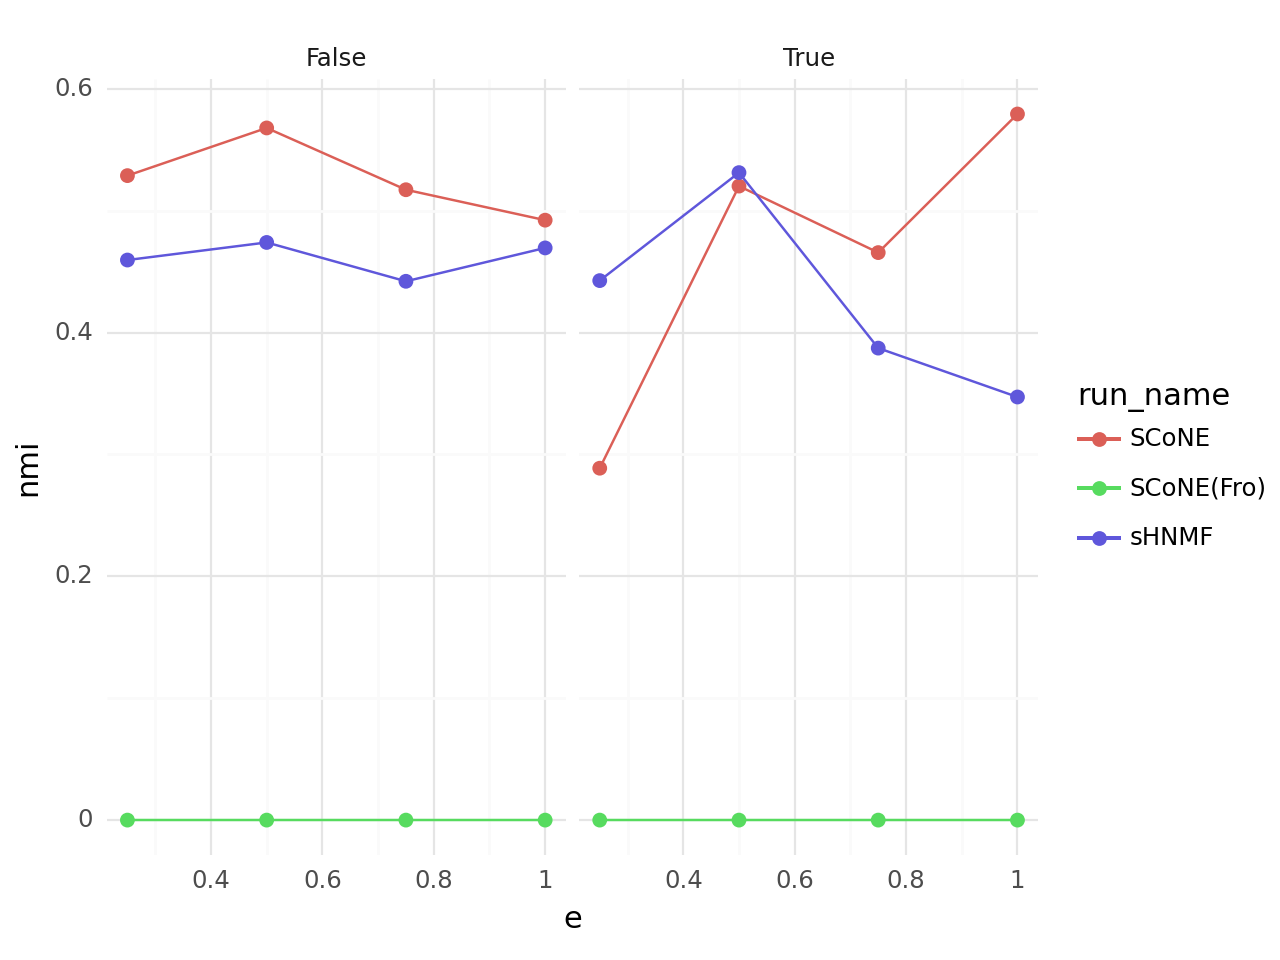

In [7]:
p = (
ggplot(best, aes(x="e", y="nmi", color="run_name", group="run_name"))
+ geom_point(size=2)
+ geom_line()
+ facet_wrap('ps')
+ theme_minimal()
+ theme()
)
print(p)

We do see norm decrease generally with increase lambda value for W - this is not the case for H_G

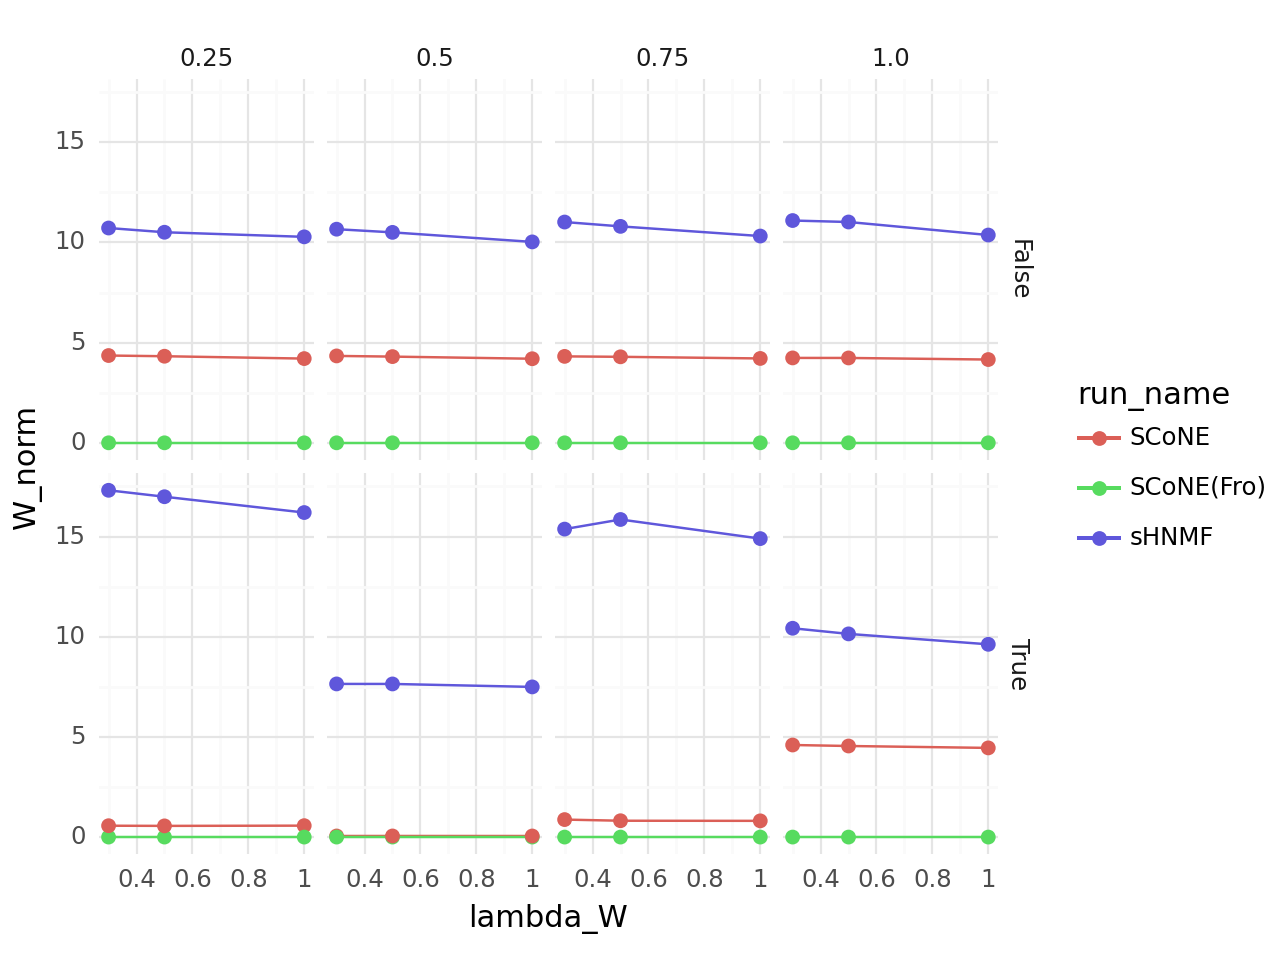

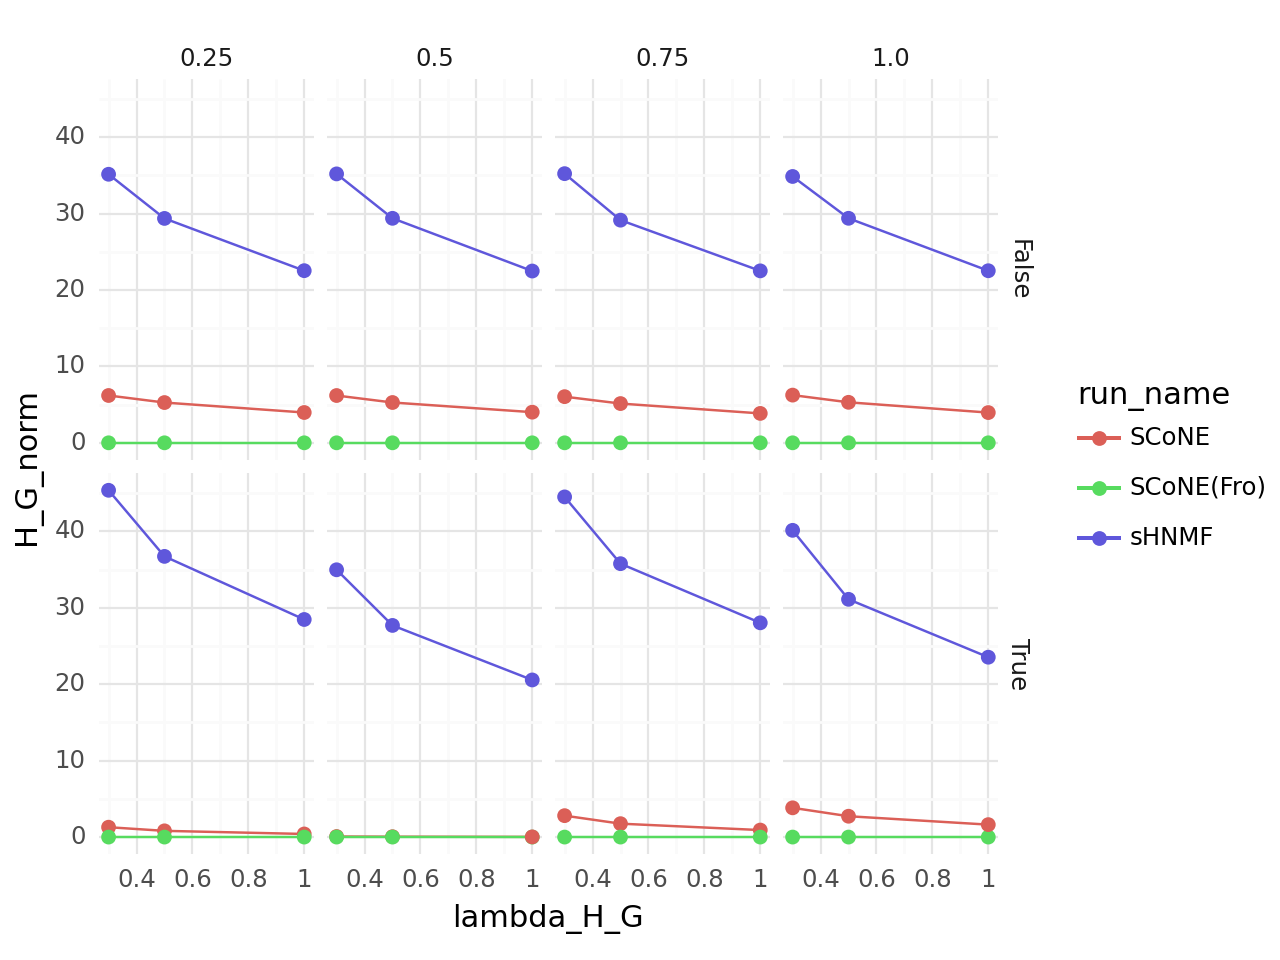

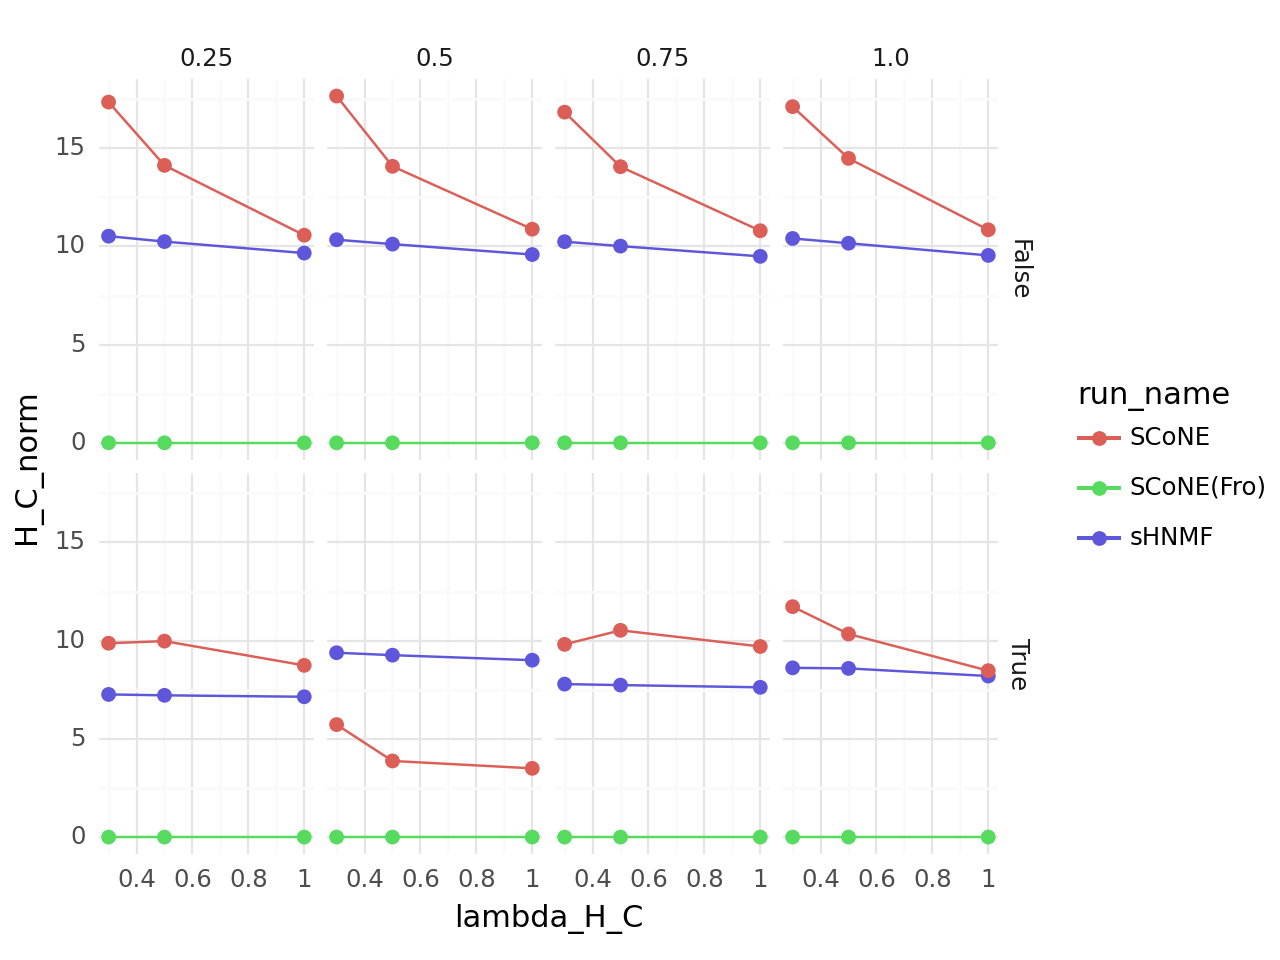

In [11]:
corresponding_norm = {'lambda_W':'W_norm','lambda_H_G':'H_G_norm','lambda_H_C':'H_C_norm'}
for param in ['lambda_W','lambda_H_G','lambda_H_C']: # maybe instead look when others are 0
    null_params = [i for i in ['lambda_W','lambda_H_G','lambda_H_C'] if i!=param]
    summary = all_runs[(all_runs[null_params[0]]==0)&(all_runs[null_params[1]]==0)]

    dodge = position_dodge(width=0.35)
    p = (
    ggplot(summary, aes(x=param, y=corresponding_norm[param], color="run_name", group='run_name'))
    + geom_line()
    + geom_point(size=2)
    #+ geom_errorbar(aes(ymin="ymin",ymax="ymax"))
    + theme_minimal()
    + theme()
    + facet_grid('ps ~ e')
    )
    print(p)

In [13]:
best[["experiment_id","run_id",'run_name','ps','lambda_W','lambda_H_G','lambda_H_C','nmi','norm_cond_entropy','purity', 'W_norm','H_G_norm','H_C_norm']]

,experiment_id,run_id,run_name,ps,lambda_W,lambda_H_G,lambda_H_C,nmi,norm_cond_entropy,purity,W_norm,H_G_norm,H_C_norm
0,168188151524110865,56953fd394fa4bb4b243c670861342e4,SCoNE,True,0.5,0.0,0.0,5.792708e-01,0.284504,0.925974,4.546039,13.687696,2.193427e+01
1,168188151524110865,f8c0e222643f44689001063cbfc945a6,SCoNE(Fro),True,1.0,1.0,0.0,0.000000e+00,0.985762,0.570130,0.000000,0.000000,1.019988e+01
2,168188151524110865,5158b28b46514414ad5d1999adcd7e18,sHNMF,True,0.5,0.0,1.0,3.471030e-01,0.562816,0.832468,10.894267,149.588285,8.742362e+00
3,250603317347287887,fcb166c37439493581a957e3343508f9,SCoNE,True,0.3,0.0,1.0,5.201358e-01,0.371358,0.898673,17.109336,5.415403,5.164392e+00
4,250603317347287887,4973fd33791e444ba7d9832b5fa788e5,SCoNE(Fro),True,1.0,1.0,0.5,2.221680e-16,0.999445,0.513872,0.000000,0.000000,3.361647e-16
5,250603317347287887,58b5ee0e616d4500b2d1a468781acf90,sHNMF,True,0.3,0.0,0.3,5.311852e-01,0.364674,0.909530,7.832453,214.753483,9.449916e+00
6,318756224924479436,36f3d15db87b4f4ba0ebe5b7b241a6f2,SCoNE,True,0.5,0.5,0.5,2.886857e-01,0.638298,0.814505,16.676233,2.866008,7.082029e+00
7,318756224924479436,cc415f9e6dd04b069b794c12b1beebd9,SCoNE(Fro),True,1.0,0.0,1.0,-2.227355e-16,0.996898,0.532775,0.000000,33.486010,2.308552e-15
8,318756224924479436,6fd7dd9eadce4247b097b3dc2dbe4173,sHNMF,True,0.5,0.0,0.0,4.425922e-01,0.465961,0.898187,16.988318,96.093583,7.776429e+00
9,400963438676737246,e1838a11a7ce42689754e4ac5b84a0e9,SCoNE,False,0.0,0.3,0.0,5.171430e-01,0.368701,0.908537,5.961476,6.041241,1.891964e+01


# Reading in test runs

In [14]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs")
client = MlflowClient()
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    print(exp)
    df = mlflow.search_runs([exp.experiment_id])
    df["experiment_id"] = exp.experiment_id
    df["experiment_name"] = exp.name
    all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
#all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs['params.ps'] = all_runs["params.ps"].map({"True": True, "False": False}).astype("boolean")  # columns you want as bools (nullable)
all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/506751578910854380', creation_time=1759351750563, experiment_id='506751578910854380', last_update_time=1759351750563, lifecycle_stage='active', name='7', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/343594918309752497', creation_time=1759351750557, experiment_id='343594918309752497', last_update_time=1759351750557, lifecycle_stage='active', name='6', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/777970162328257407', creation_time=1759351750552, experiment_id='777970162328257407', last_update_time=1759351750552, lifecycle_stage='active', name='5', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/159658722827642069', creation_time=1759351750548, experiment_id='15

In [19]:
all_runs['lambda_Gloss'] = all_runs['lambda_Gloss'].astype("float64") 

In [22]:
other_losses = all_runs[(all_runs['lambda_Gloss']==0.5)|(all_runs['lambda_Gloss']==1)].copy()
all_runs = all_runs[(all_runs['lambda_Gloss']!=0.5)&(all_runs['lambda_Gloss']!=1)].copy()

In [24]:
normal = other_losses[other_losses['lambda_Gloss']==1].copy()

In [ ]:
from evaluation import cluster_evaluation
from scipy.optimize import linear_sum_assignment

results_list = []
# look at correlation btwn columns of af and UG
af_variance_df = pd.read_csv(f'{af_df_filepath}.P',header=None,sep='\s+')
# get marker id
df_map = pd.read_csv(map_filepath,sep='\s+',header=None,names=["chrom", "SNP", "cm", "bp"])
af_variance_df['SNP'] = df_map['SNP'].values
# make sure af variance df and bim df have same snps (incase of subsetting)
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2'])
af_variance_df = af_variance_df.merge(bim_df[['SNP']], on='SNP', how='inner')
assert all(af_variance_df['SNP'].values == bim_df['SNP'].values)
for i, row in all_runs.iterrows():
    # re-calc some params
    with open(f'{output_dir}/logs/{row["experiment_id"]}/{row["run_id"]}/artifacts/state_info/final_state.pkl','rb') as f:
        final_state = pickle.load(f)
    with open(f'{sim_output_dir}/simulation_metadata_{sim_functions.get_output_file_suffix(row["ps"],row["e"],row["dataset"],int(row["g"]))}.pkl','rb') as f:
        simulation_metadata = pickle.load(f)
    W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
        .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
    mask = (W_true.sum(axis=1) == 1)
    ground_truth = {"W":W_true[mask]}
    factor_matrices = {"W":final_state["W"][mask]}
    assert ground_truth["W"].shape[0] == factor_matrices["W"].shape[0]
    results = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)


    # # look at metrics by superpopulation
    # igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath,bfile_path=bfile_path)
    # igsr_samples = igsr_samples[igsr_samples['IID'].isin(simulation_metadata['phenotypic_subgroups']['IID'])].copy()
    # phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    # phenotypic_subgroups = phenotypic_subgroups.merge(igsr_samples,on='IID')
    # for pop_code in phenotypic_subgroups['Superpopulation code'].unique():
    #     mask2 = (igsr_samples['Superpopulation code'].values == pop_code)
    #     other_col = ((W_true.sum(axis=1) == 0).astype(int)).reshape(-1, 1)
    #     ground_truth = {"W":np.hstack([W_true, other_col])[mask2]}
    #     factor_matrices = {"W":final_state["W"][mask2]}
    #     pop_results = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)
    #     results[f'purity_{pop_code}'] = pop_results['purity']
    #     results[f'entropy_{pop_code}'] = pop_results['norm_cond_entropy']
    #     results[f'nmi_{pop_code}'] = pop_results['nmi']
    # look at correctly identifying markers - calculte max overlap with markers0 and markers1
    marker_matrix = np.zeros((2,3))
    for i_true in range(2):
        for j_pred in range(3):
            true_col = bim_df['SNP'].isin(simulation_metadata['markers_assoc'][i_true]).astype(int)
            pred_col = final_state["H_G"][:,j_pred]
            cos = np.dot(true_col, pred_col) / (np.linalg.norm(true_col) * np.linalg.norm(pred_col))
            marker_matrix[i_true,j_pred] = cos
    i_col, j_col = linear_sum_assignment(-marker_matrix)
    results = {}
    for i,j in list(zip(i_col, j_col)):
        results[f'marker_overlap_{i}'] = marker_matrix[i,j]


    # for cone methods, there should be some non-zero correlation between U_G and superpopulation allele frequency
    A = final_state["U_G"]
    B = af_variance_df[range(5)].to_numpy()
    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)
    A_hat = A0 / np.linalg.norm(A, axis=0, keepdims=True)
    B_hat = B0 / np.linalg.norm(B, axis=0, keepdims=True)
    cos_sim =  A_hat.T @ B_hat   # shape (n, k)
    results['ug_af_cossim_mean'] = cos_sim.mean()



    results_list.append(results)




all_runs[pd.DataFrame(results_list, index=all_runs.index).columns] = pd.DataFrame(results_list, index=all_runs.index)


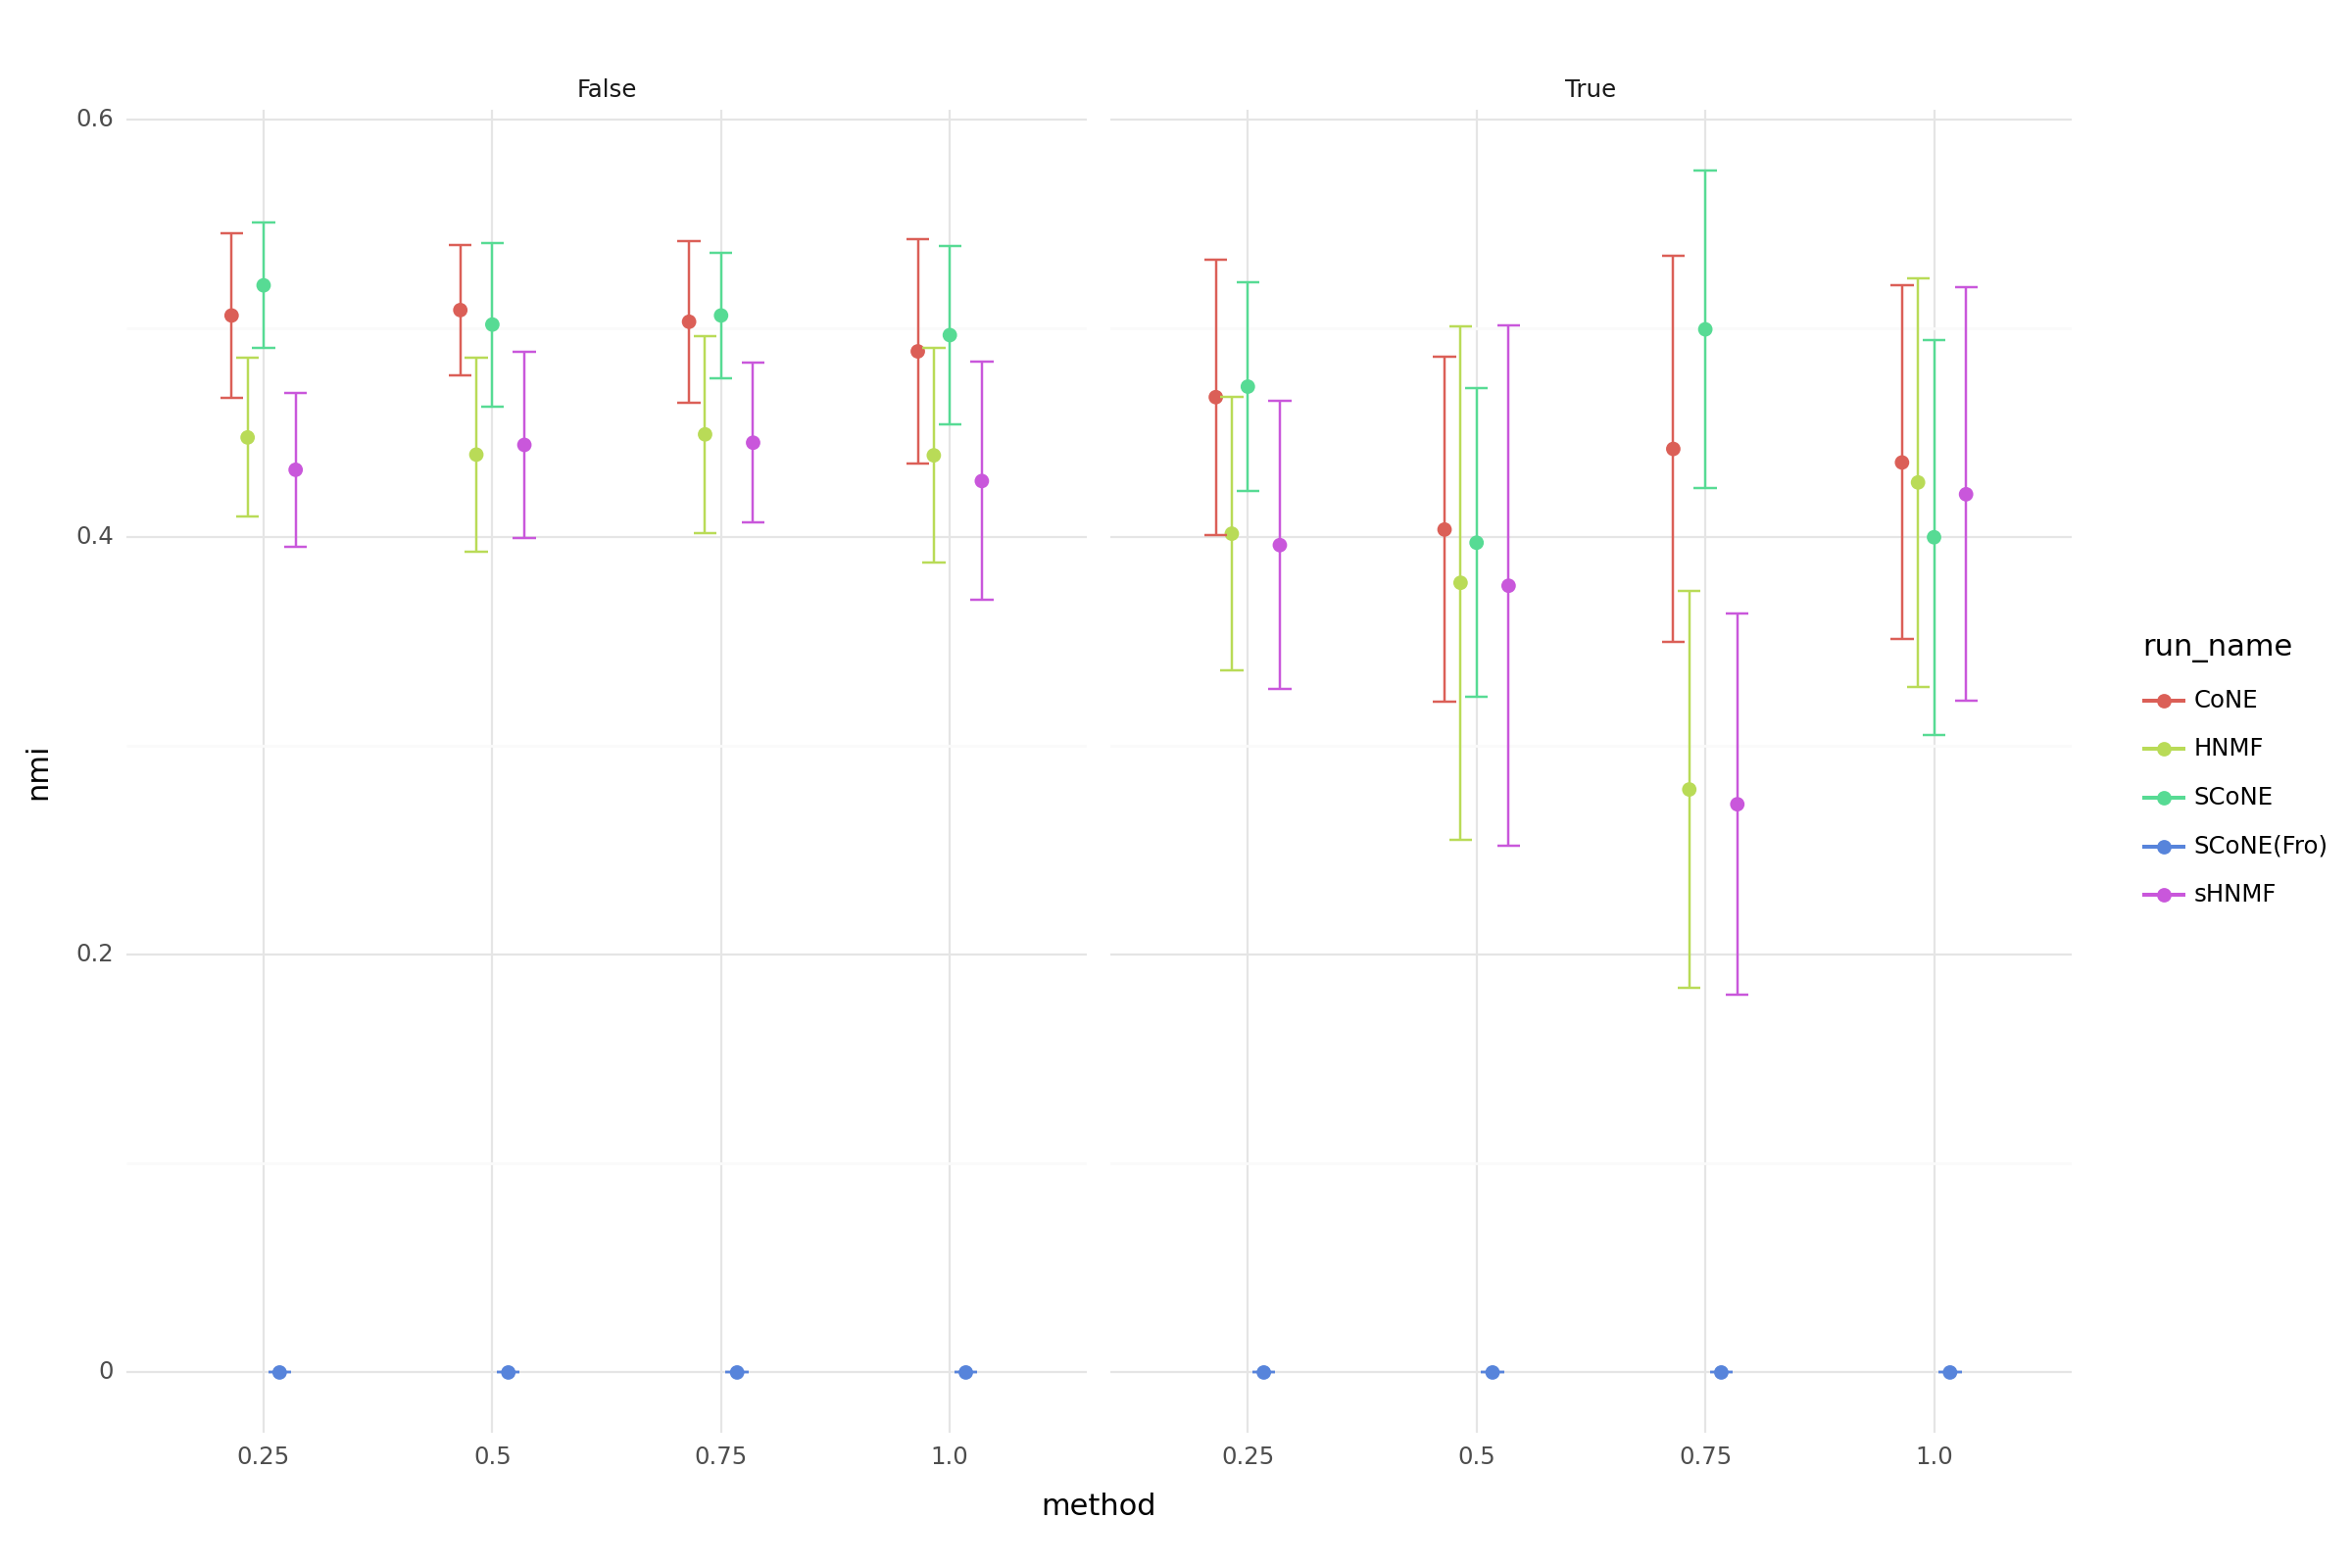

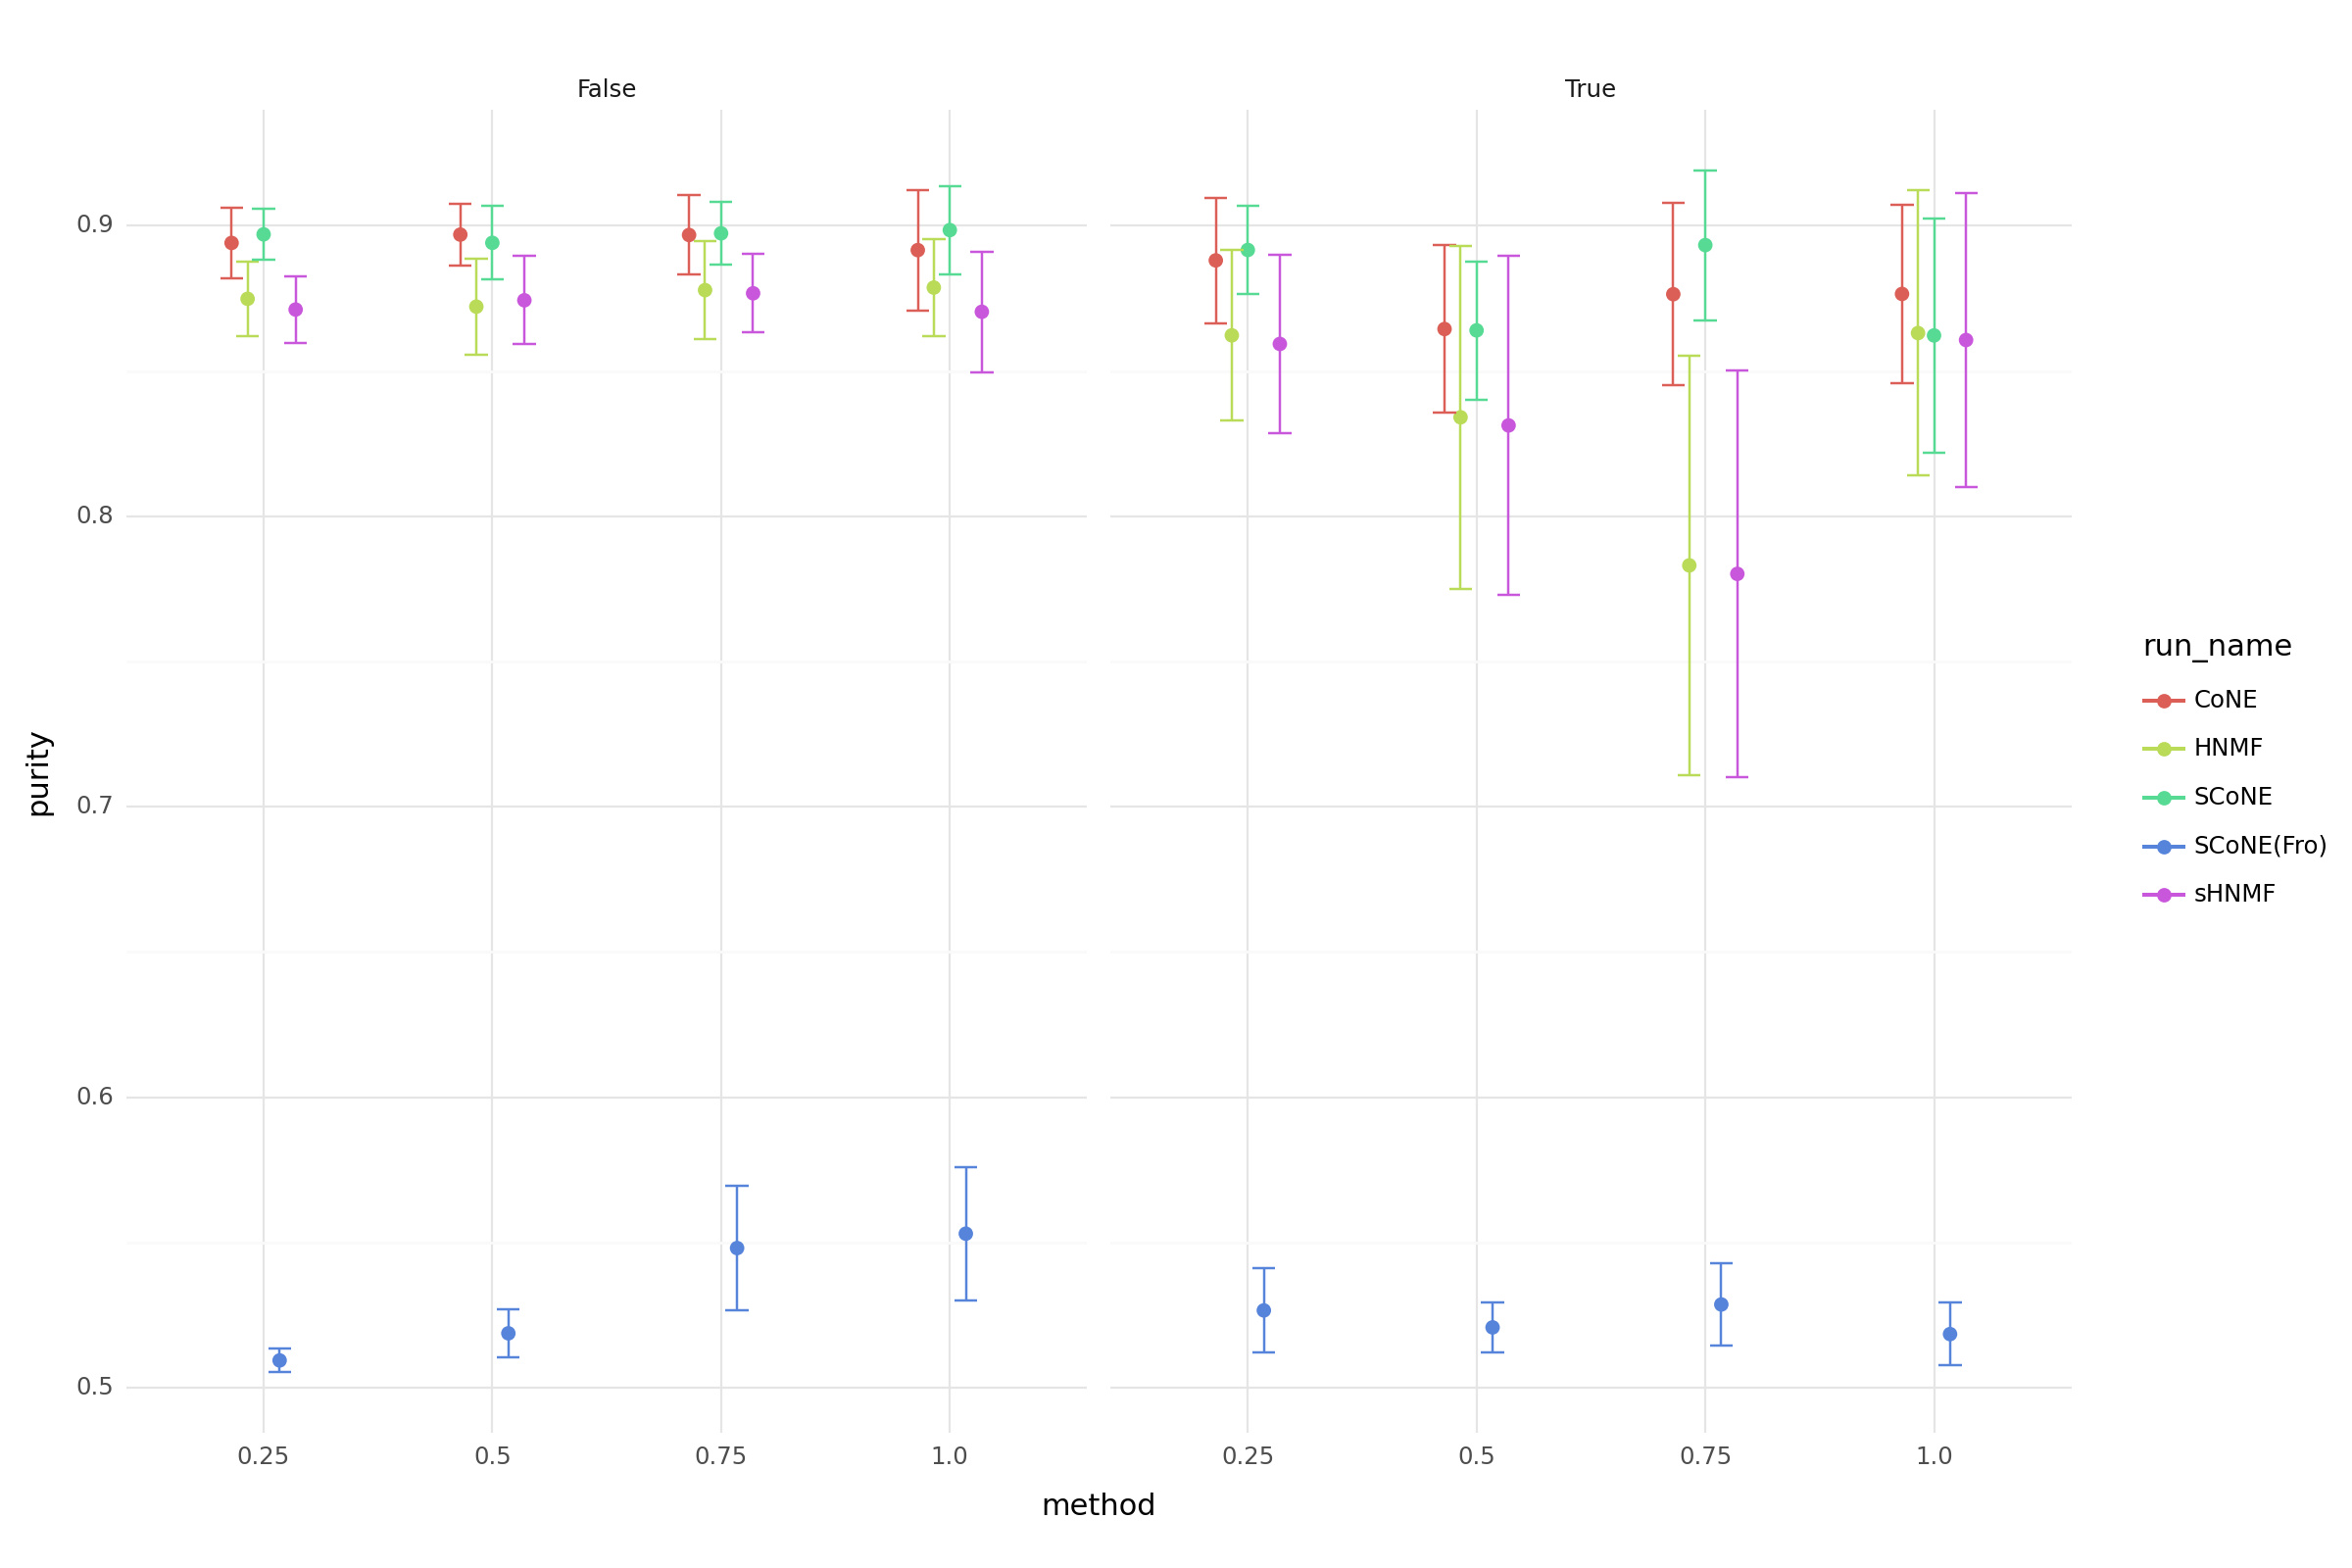

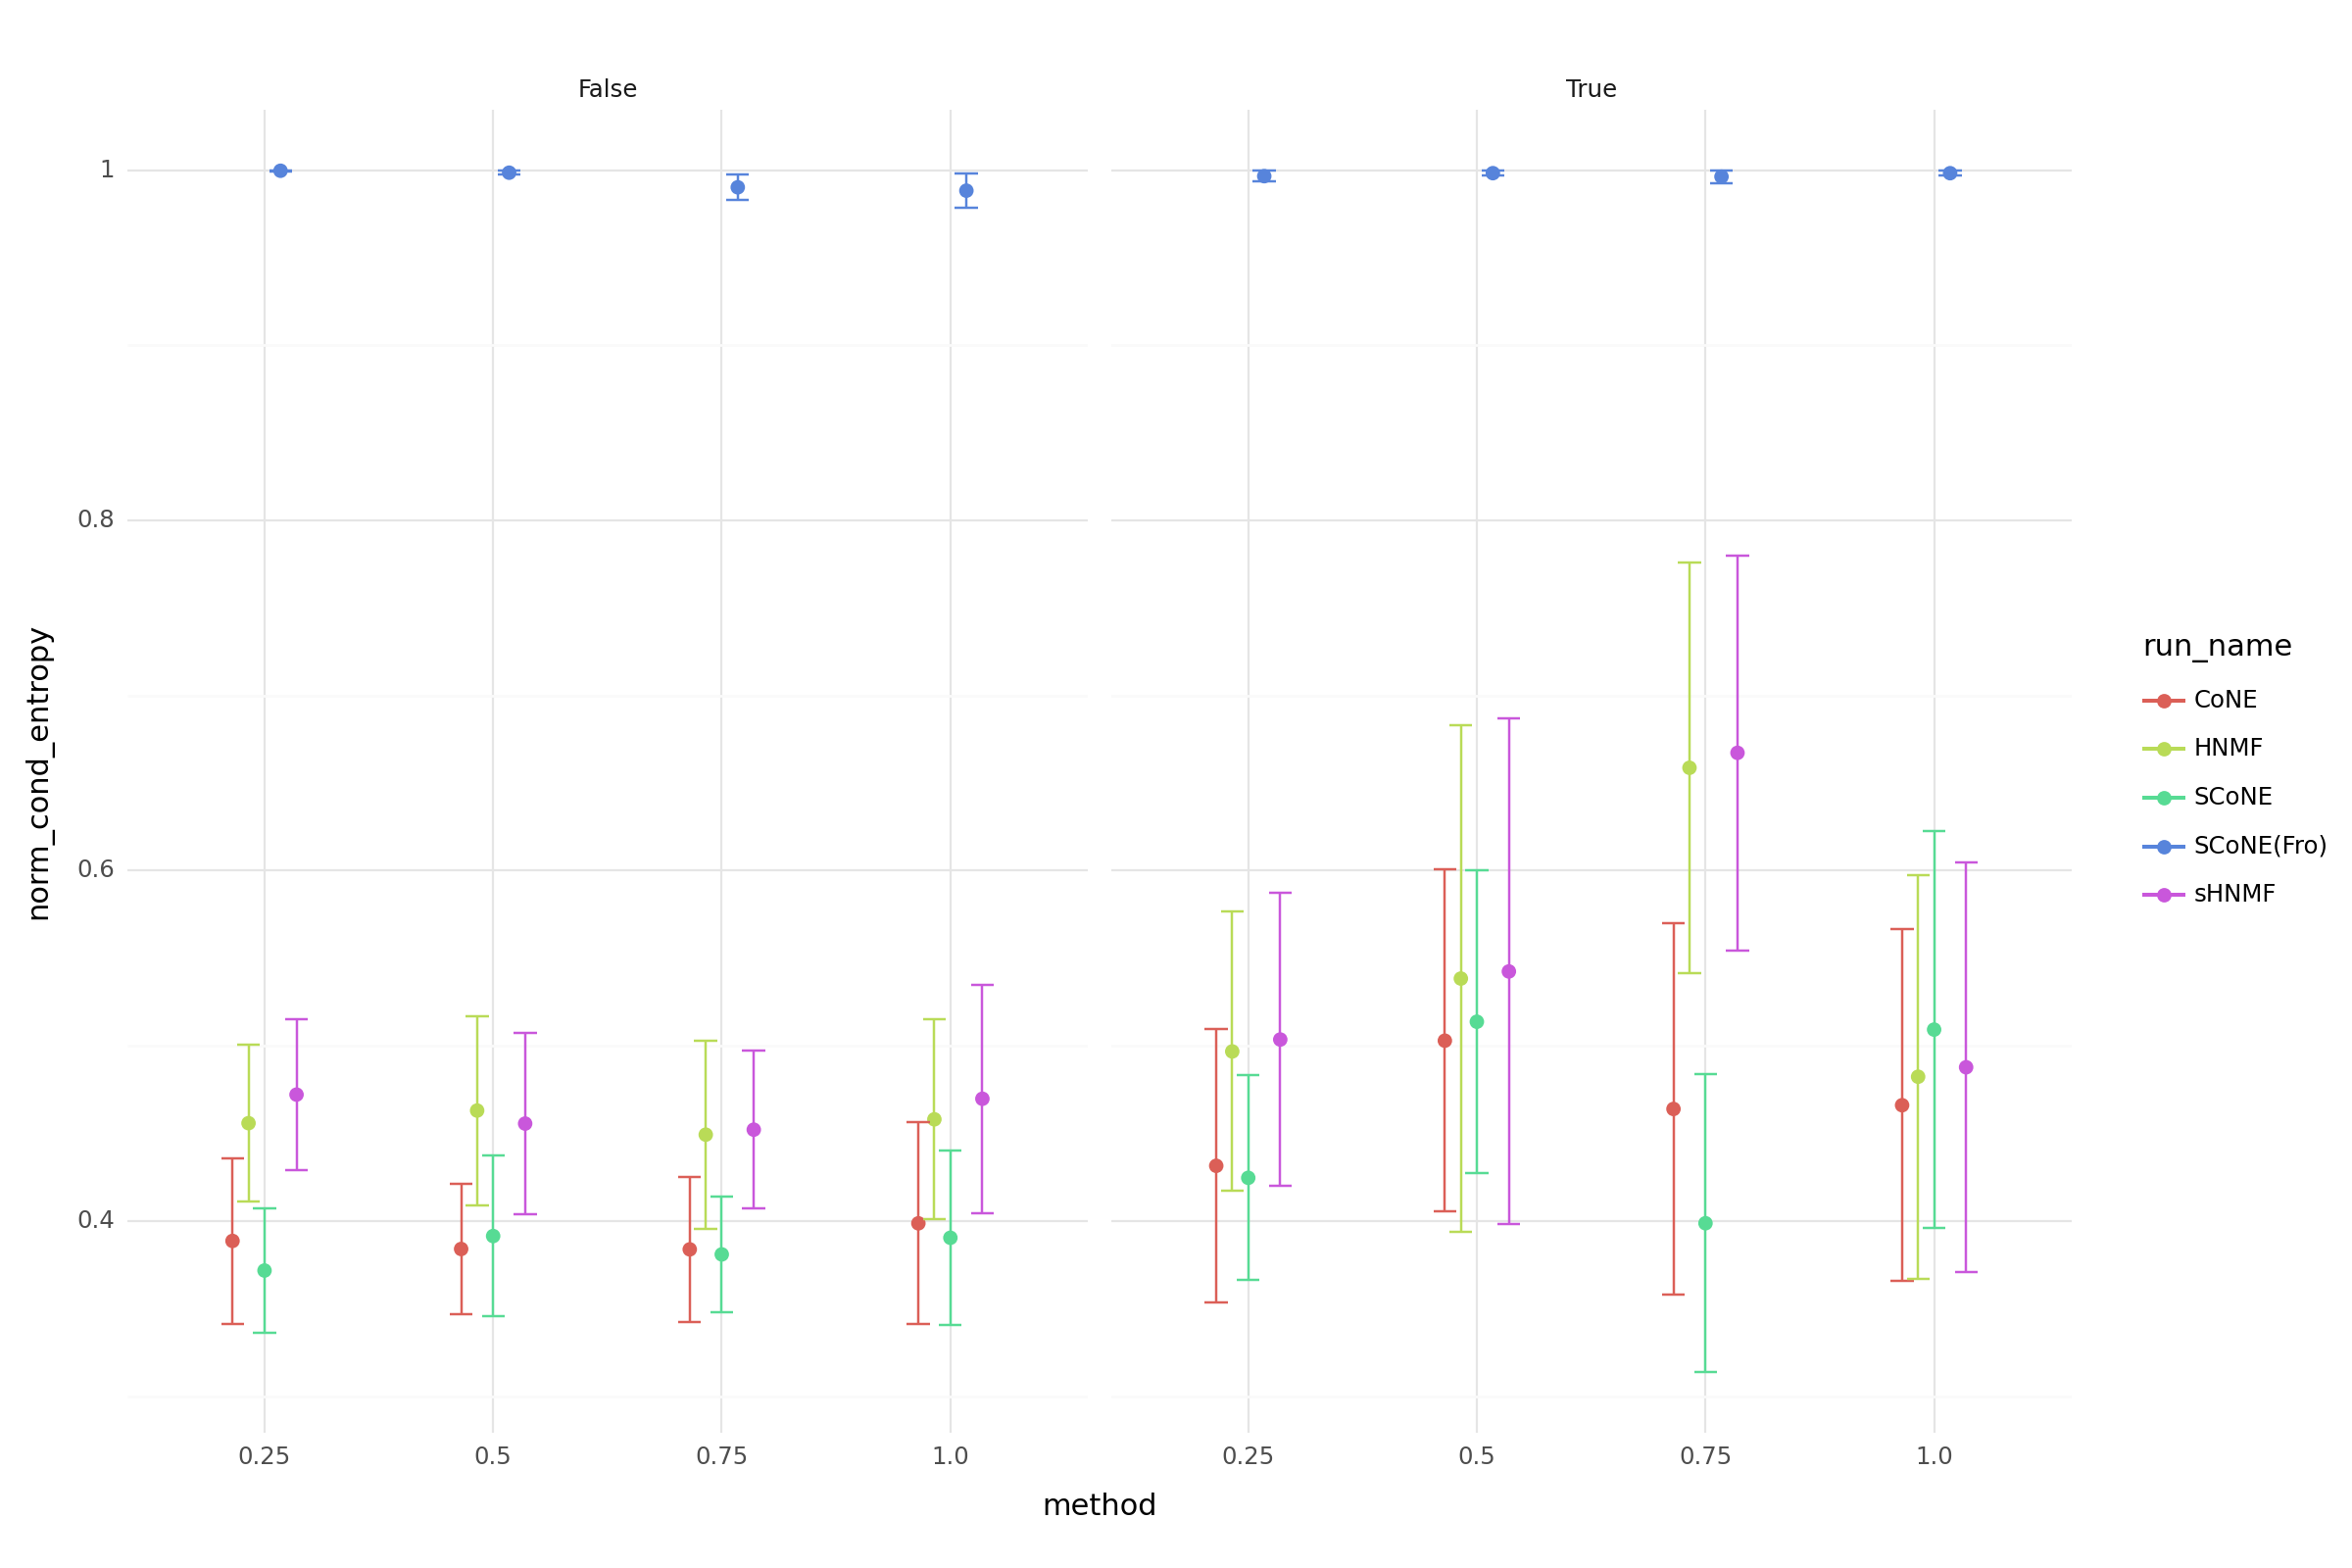

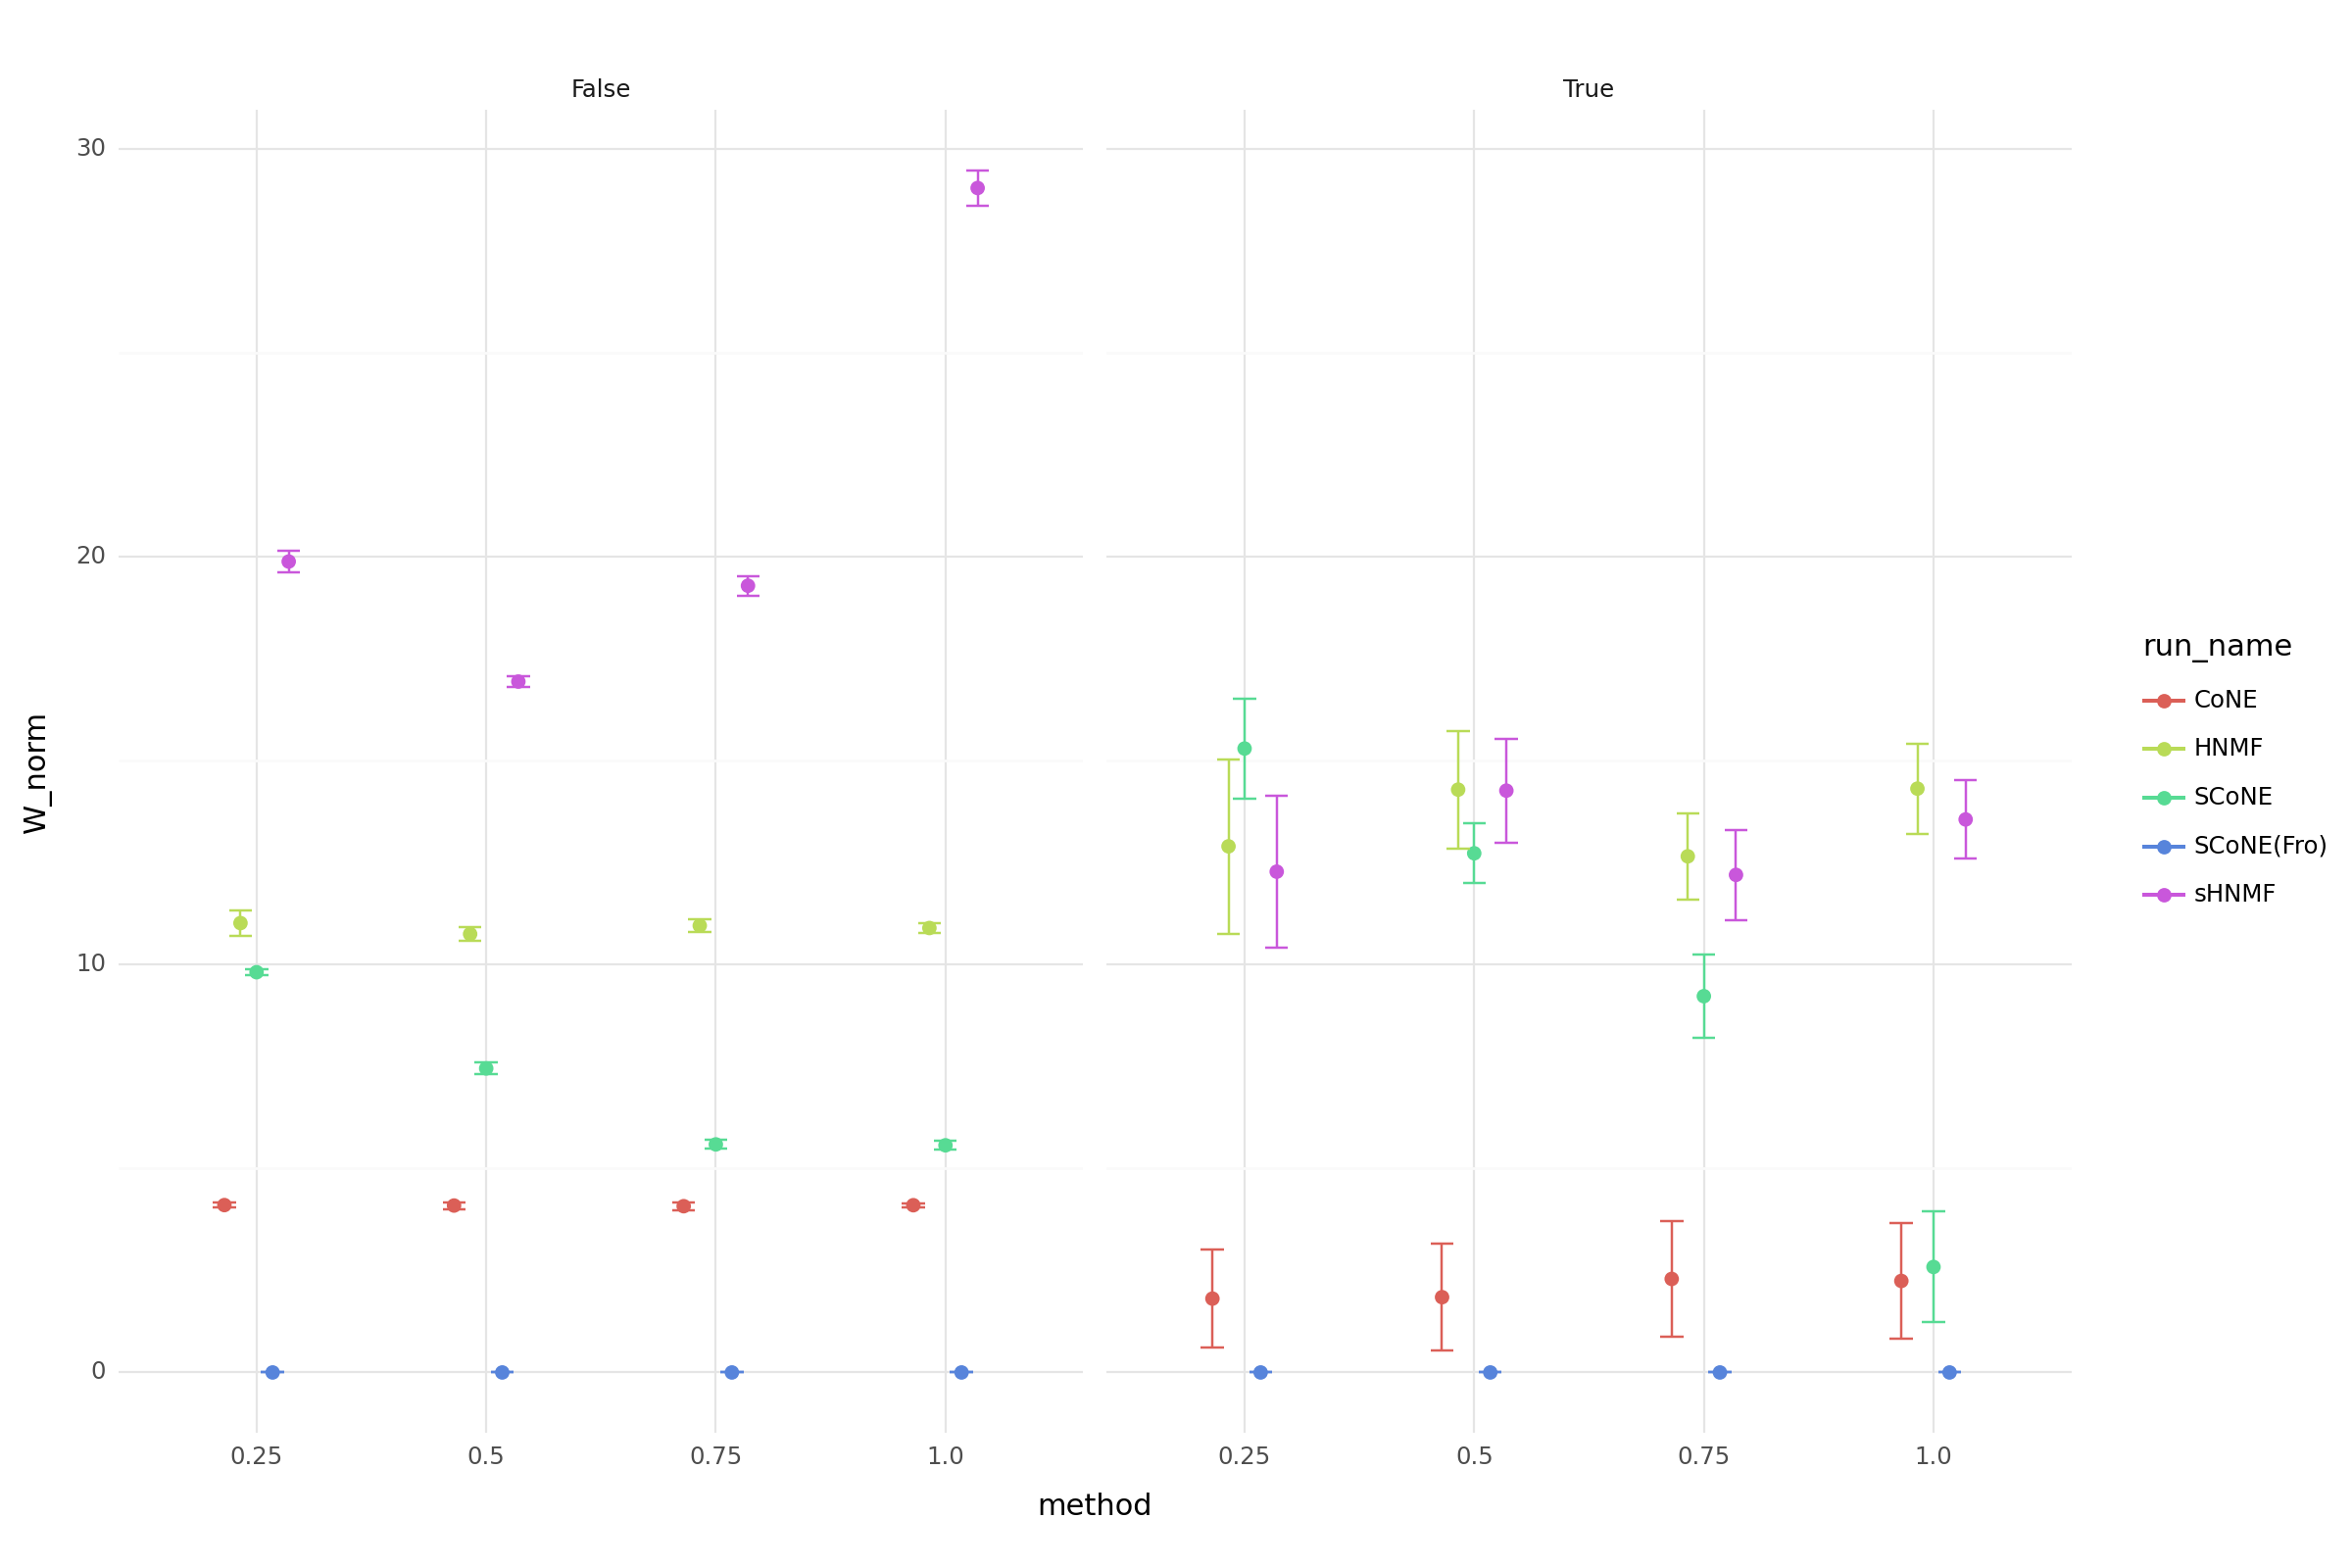

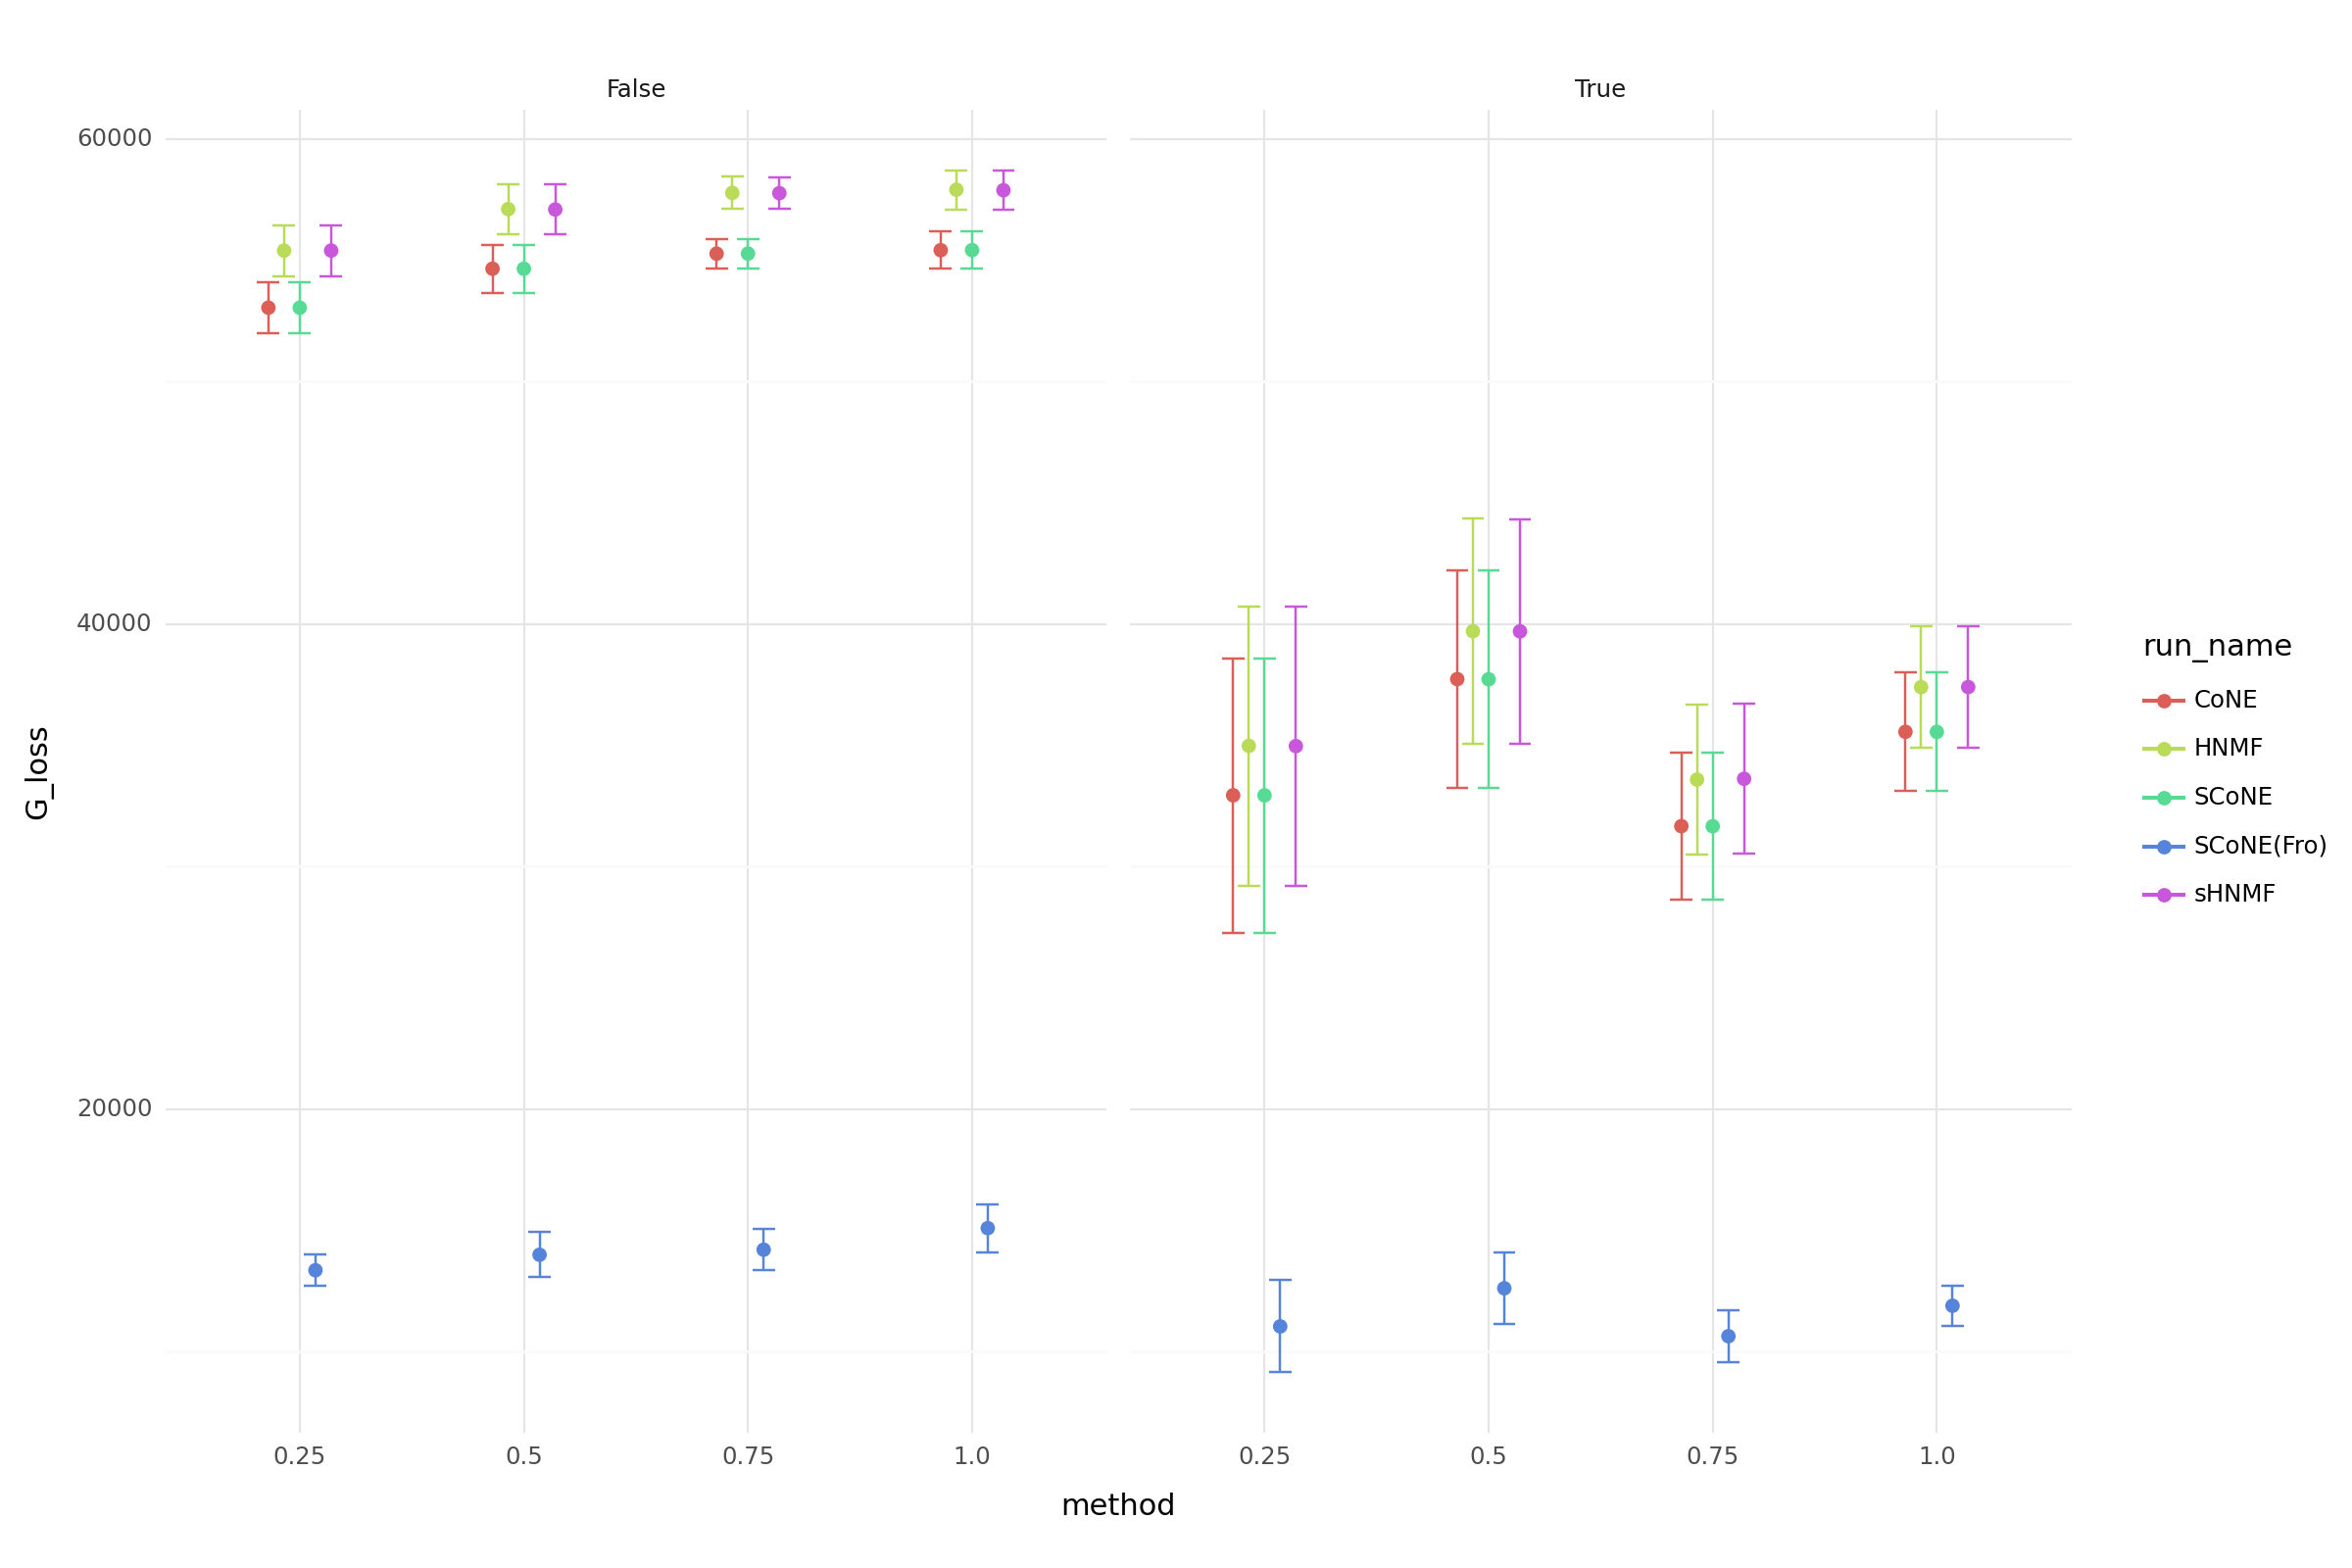

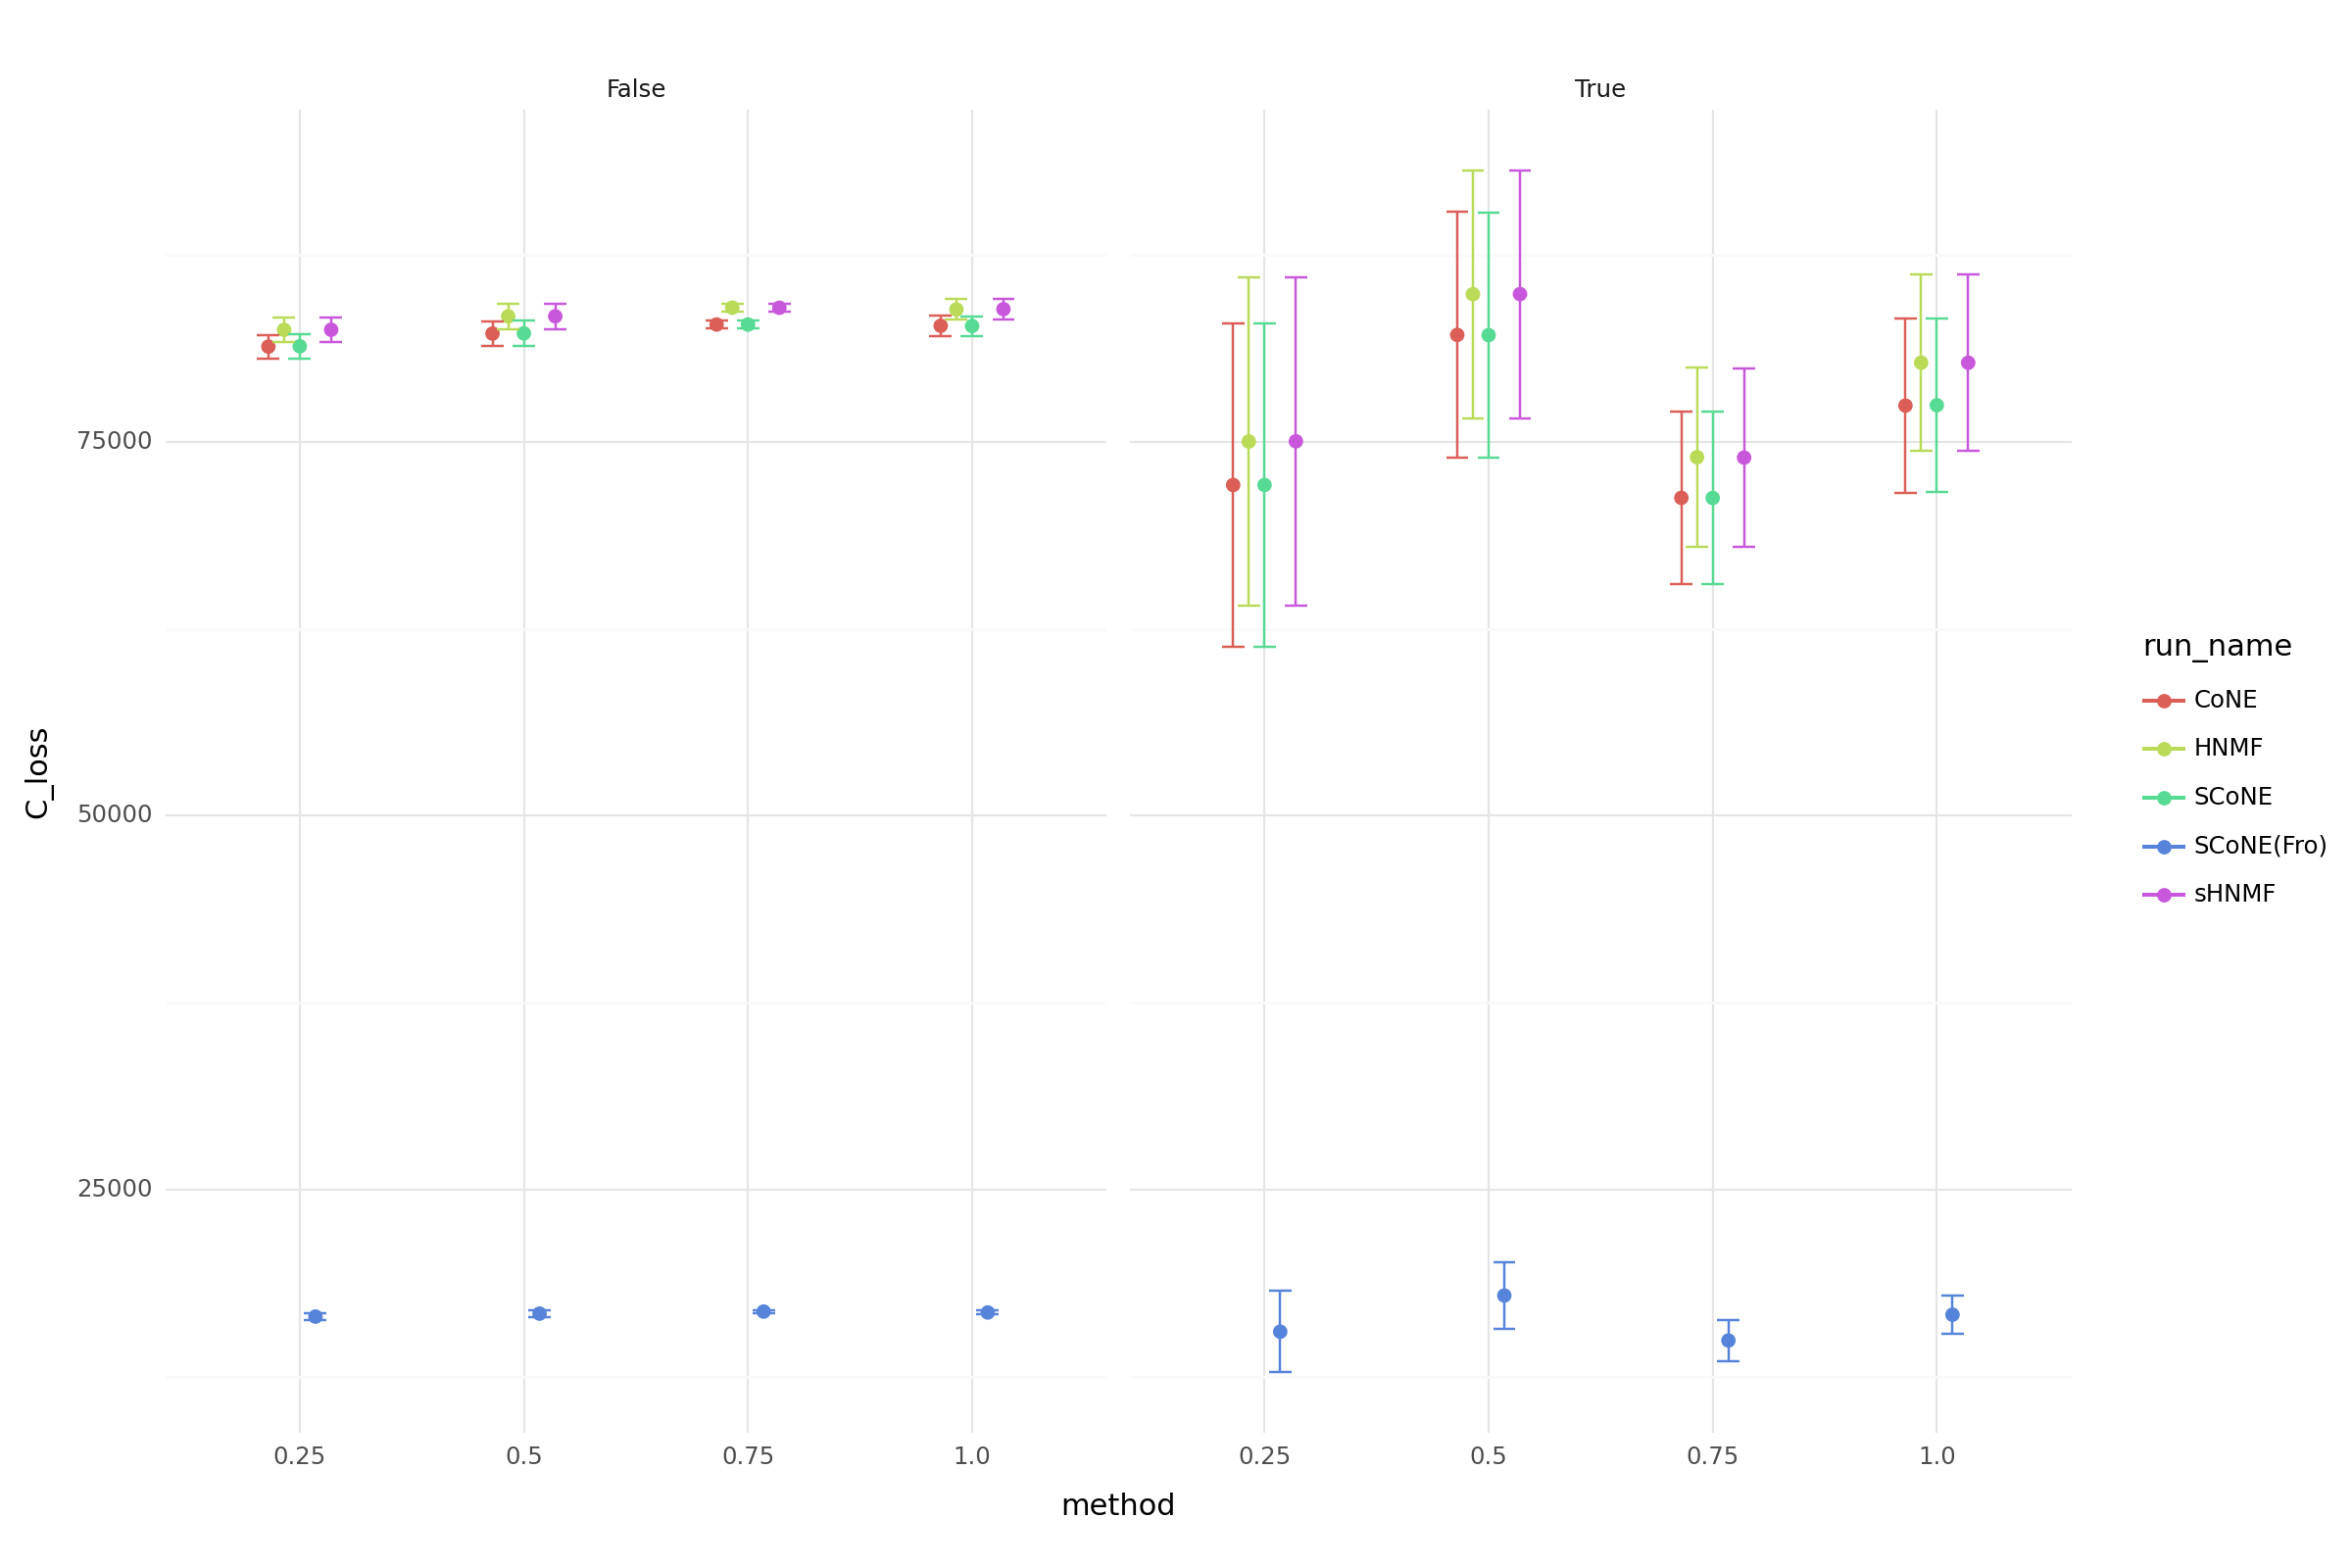

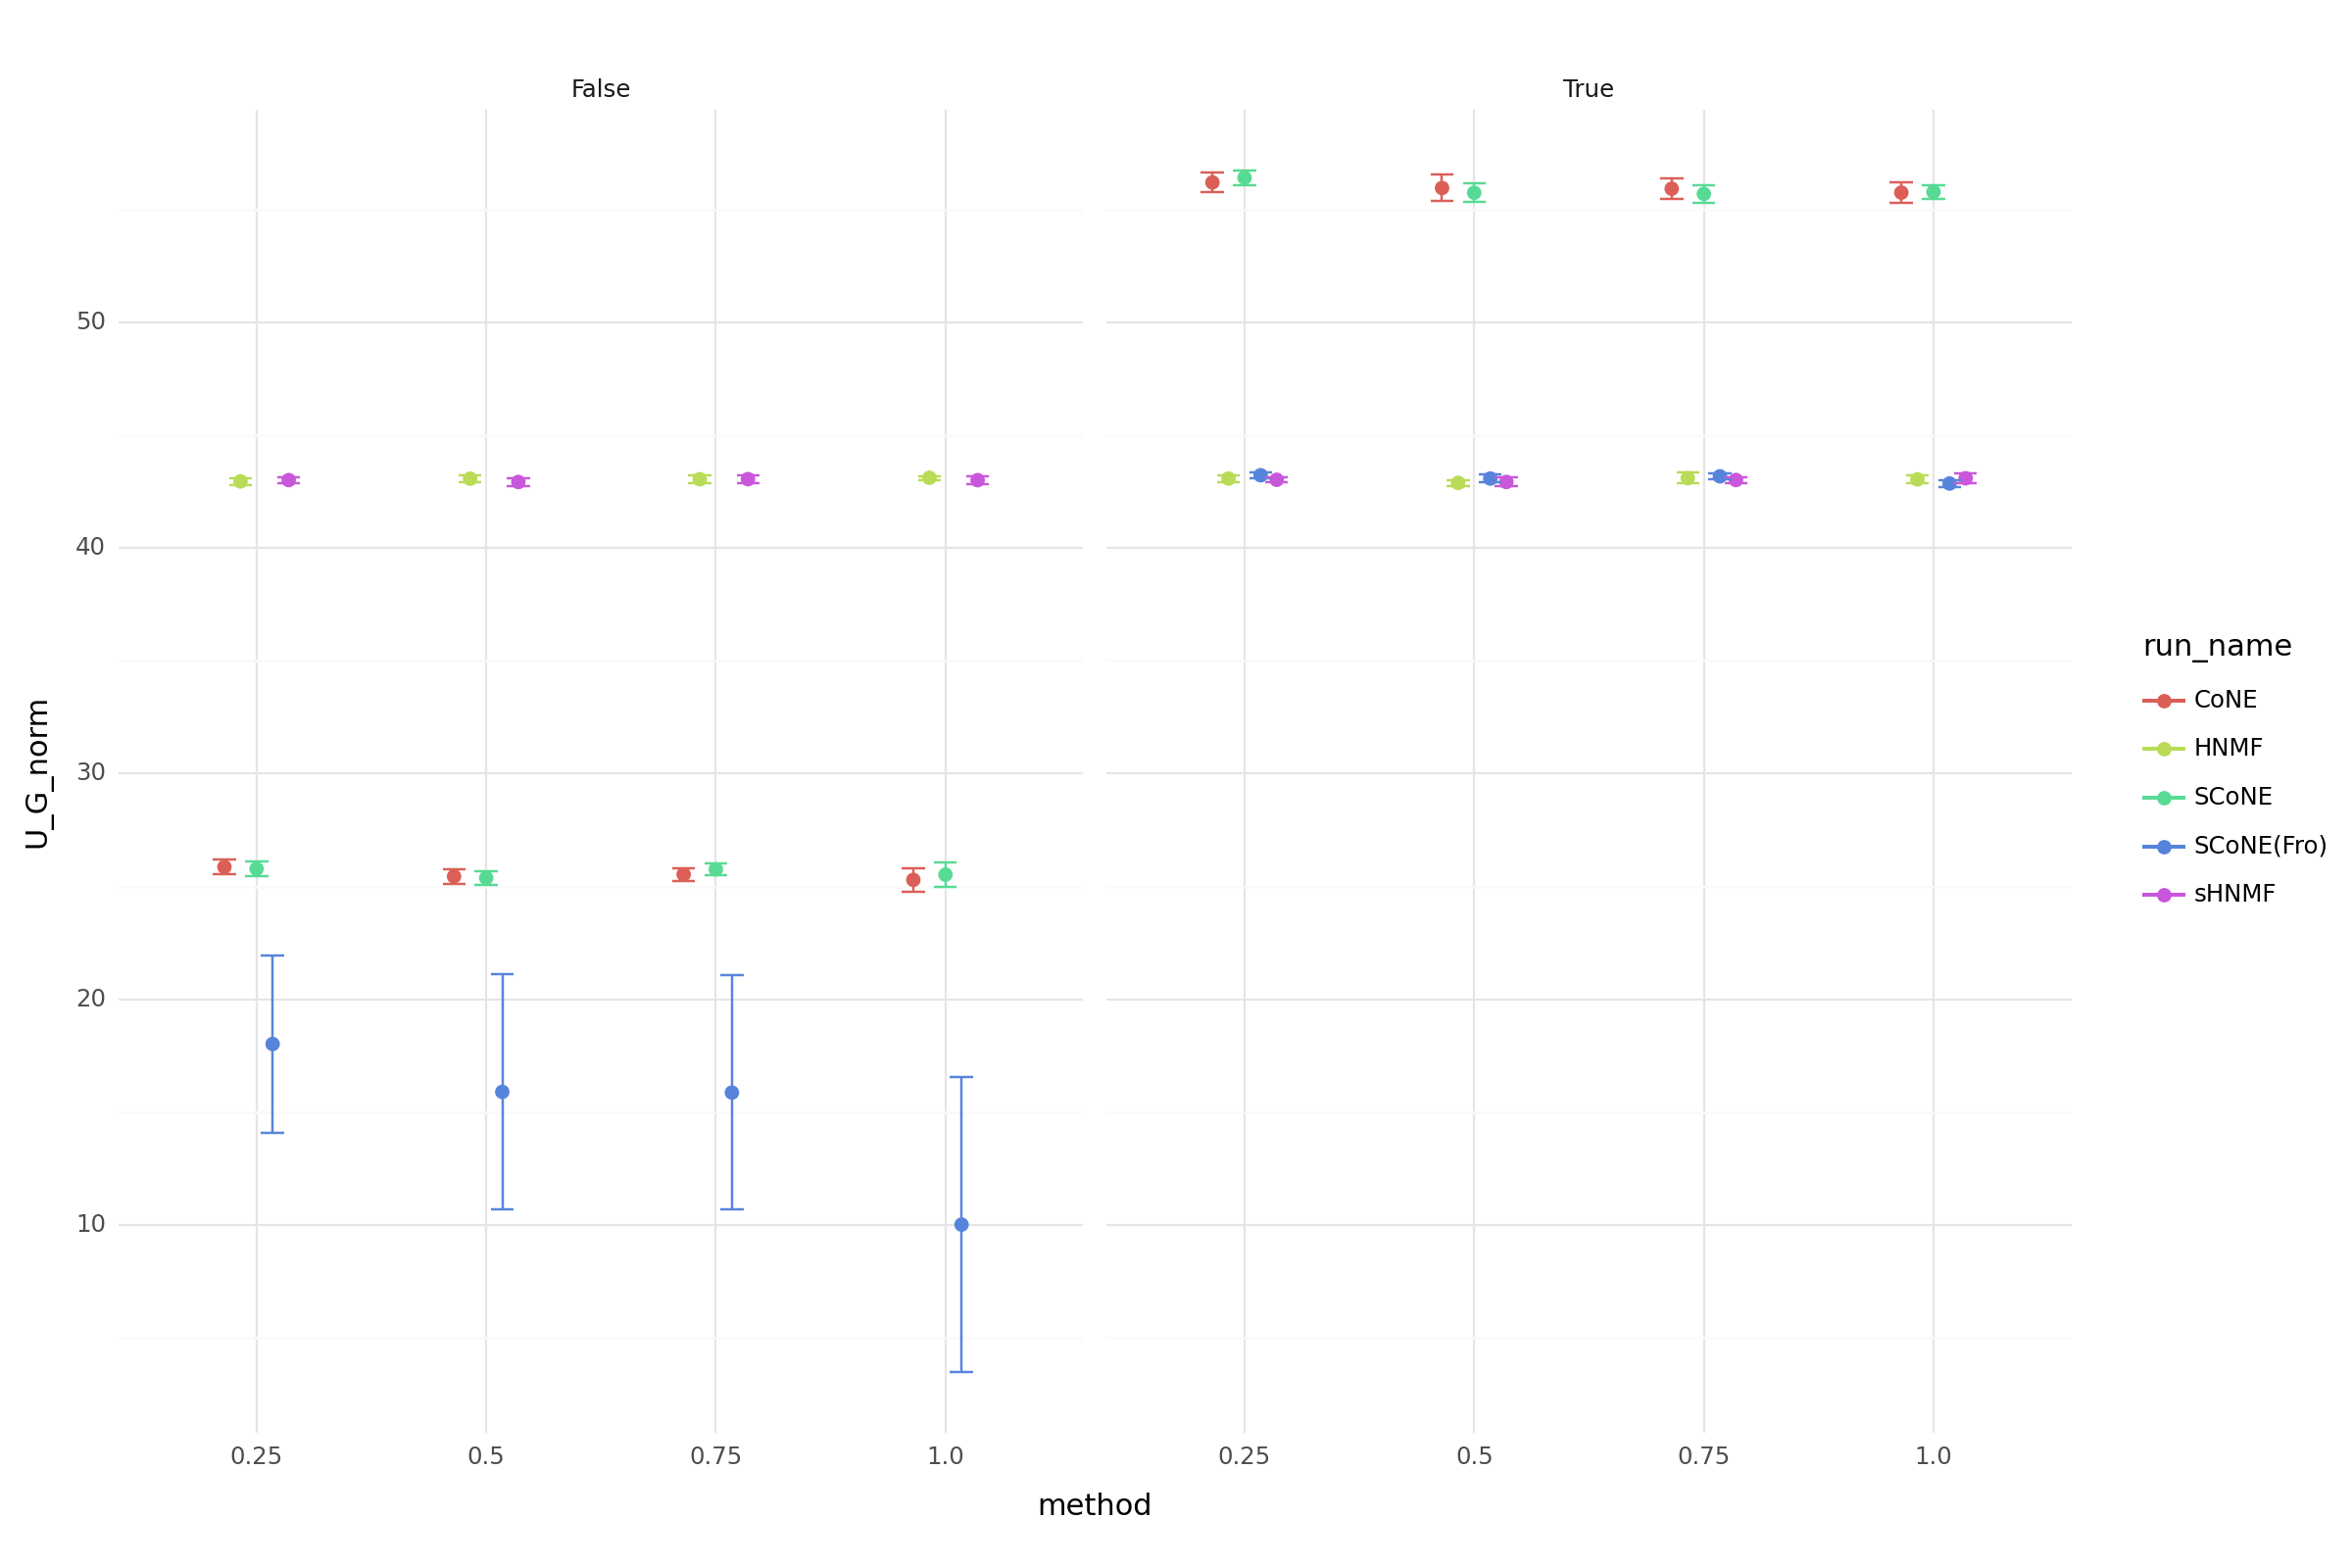

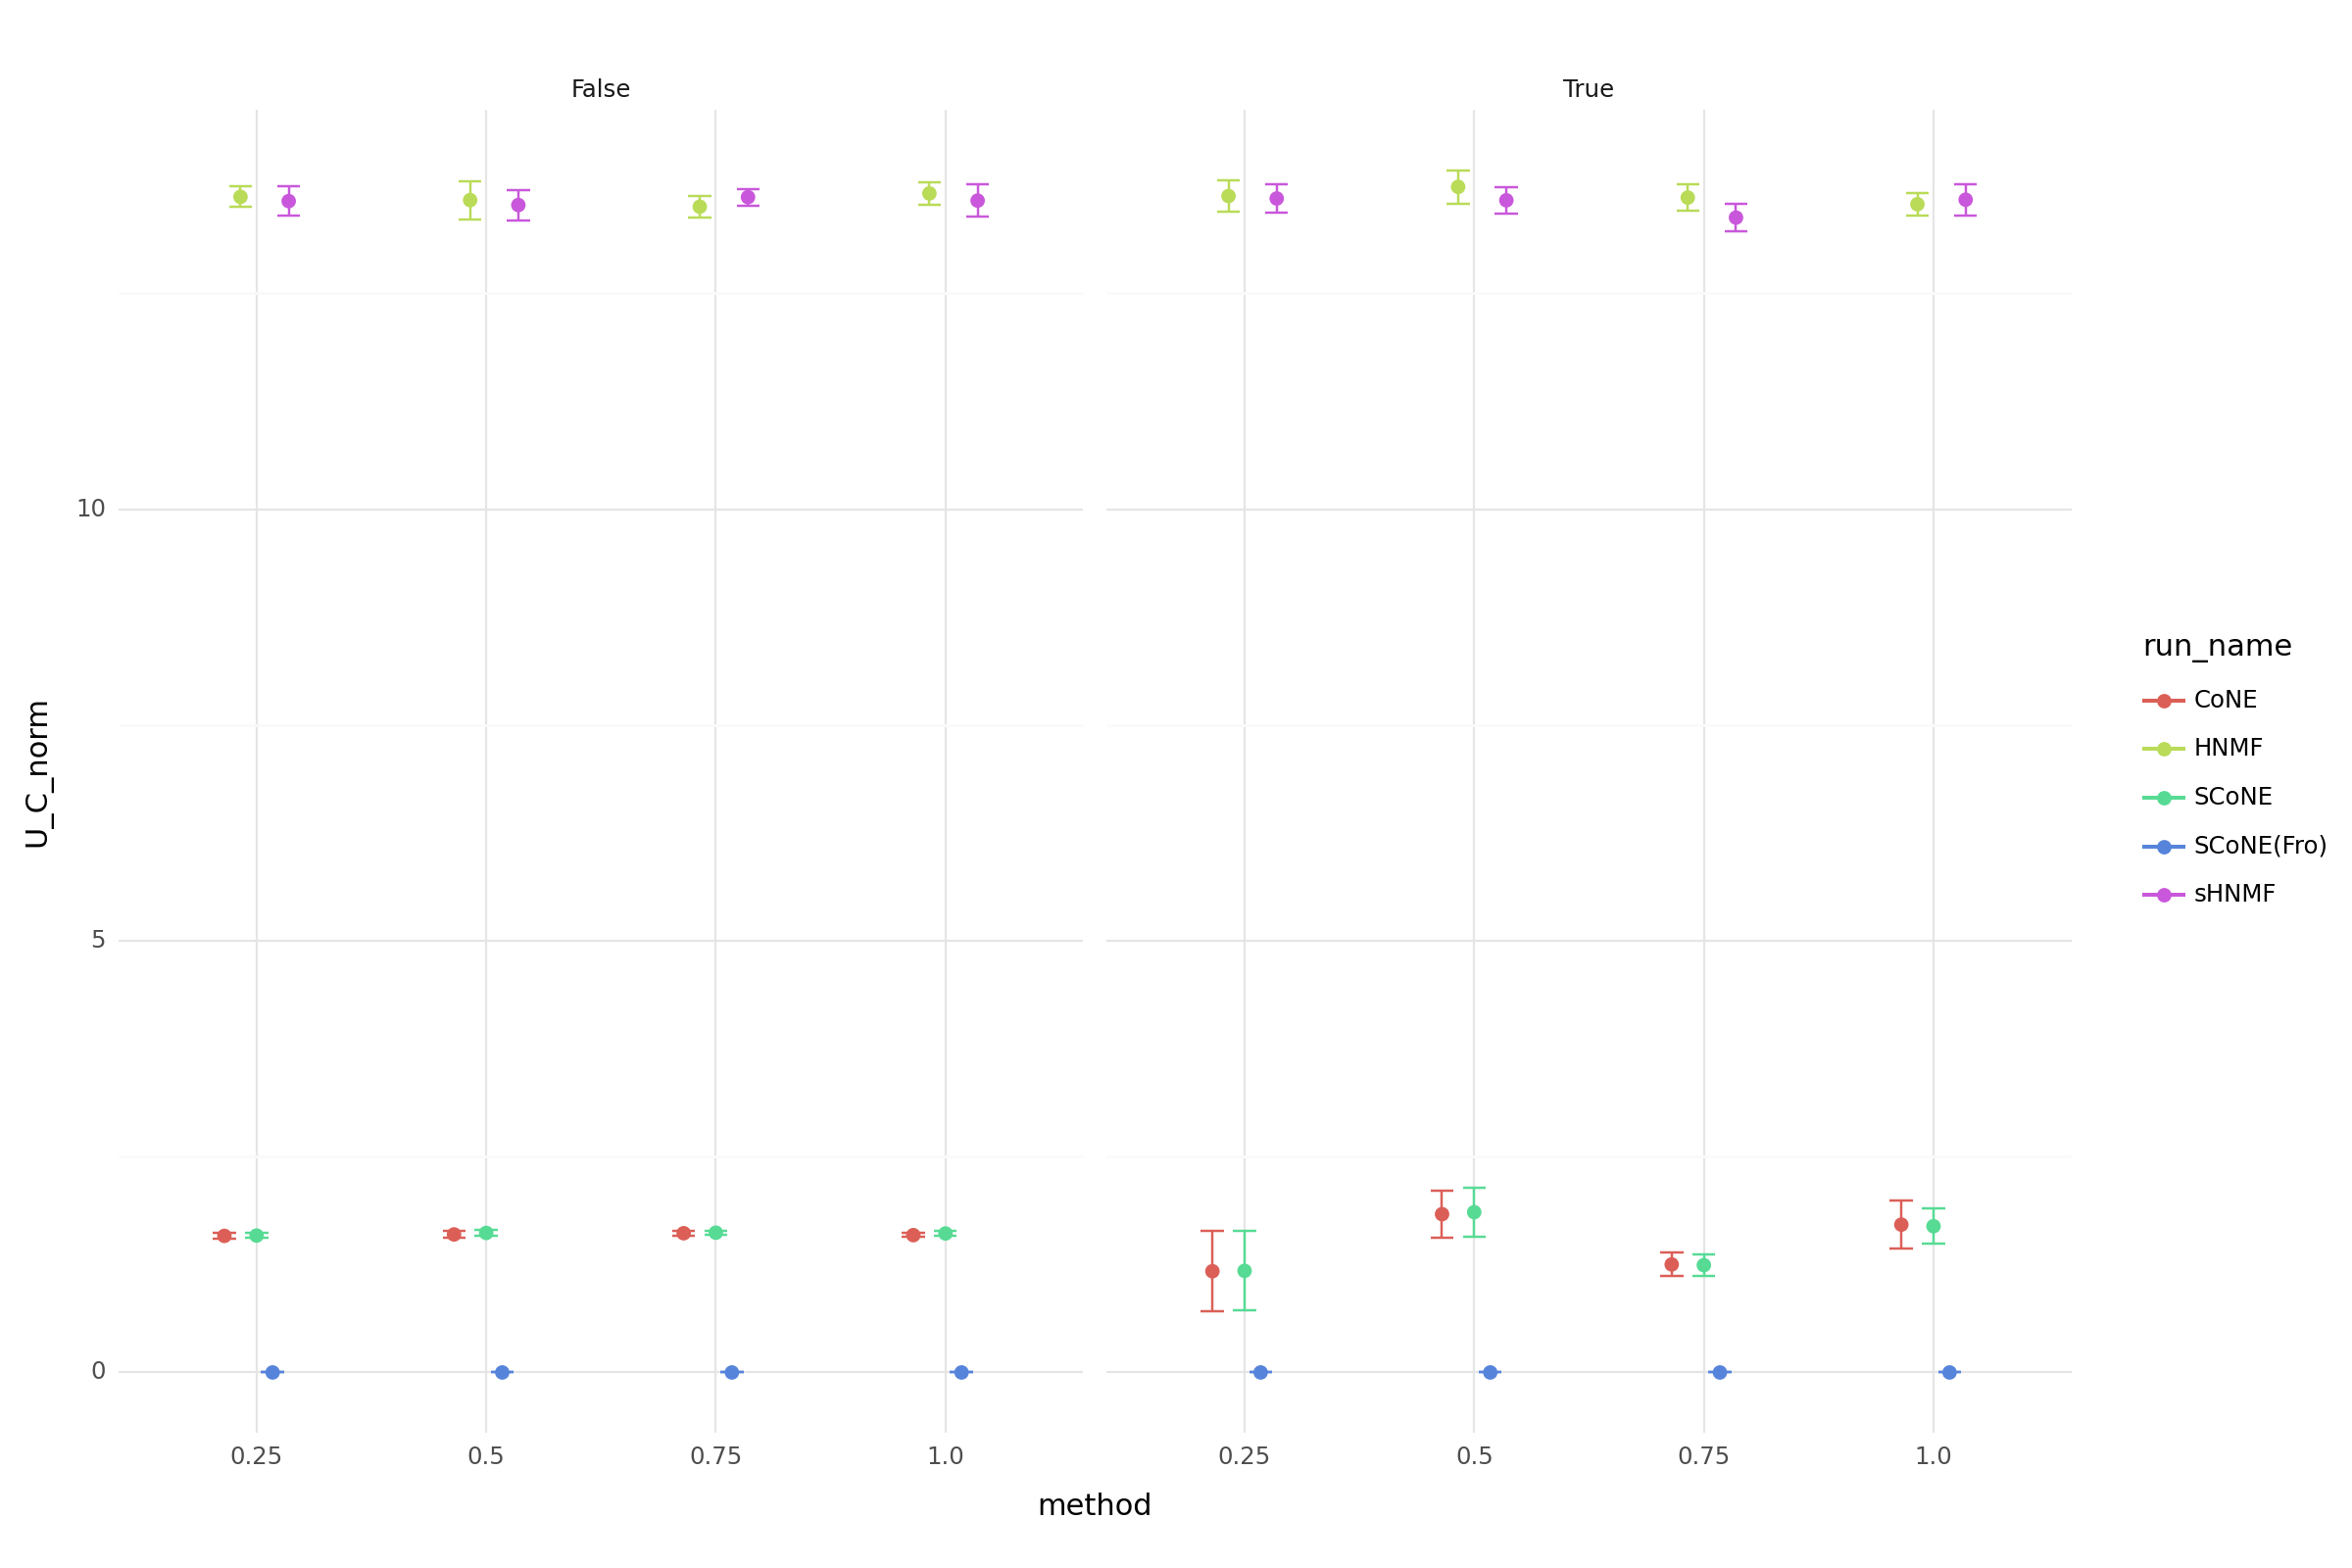

In [26]:
# get best model per total loss (since sparsity params fixed per run now) over initializations (within one experiment, dataset, run_name)
idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","run_name", "ps", "e", "g"])
      .reset_index(drop=True)
)
dodge = position_dodge(width=0.35)

# get CI over 10 random datasets
for metric in ['nmi','purity','norm_cond_entropy','W_norm','G_loss','C_loss','U_G_norm','U_C_norm']:
    summary = (
        best.groupby(["run_name", "ps", "e", "g"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    p = (
    ggplot(summary, aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="method", y=metric, title='')
    + facet_wrap('ps')
    + theme_minimal()
    + theme(figure_size=(12,8))
    )
    print(p)


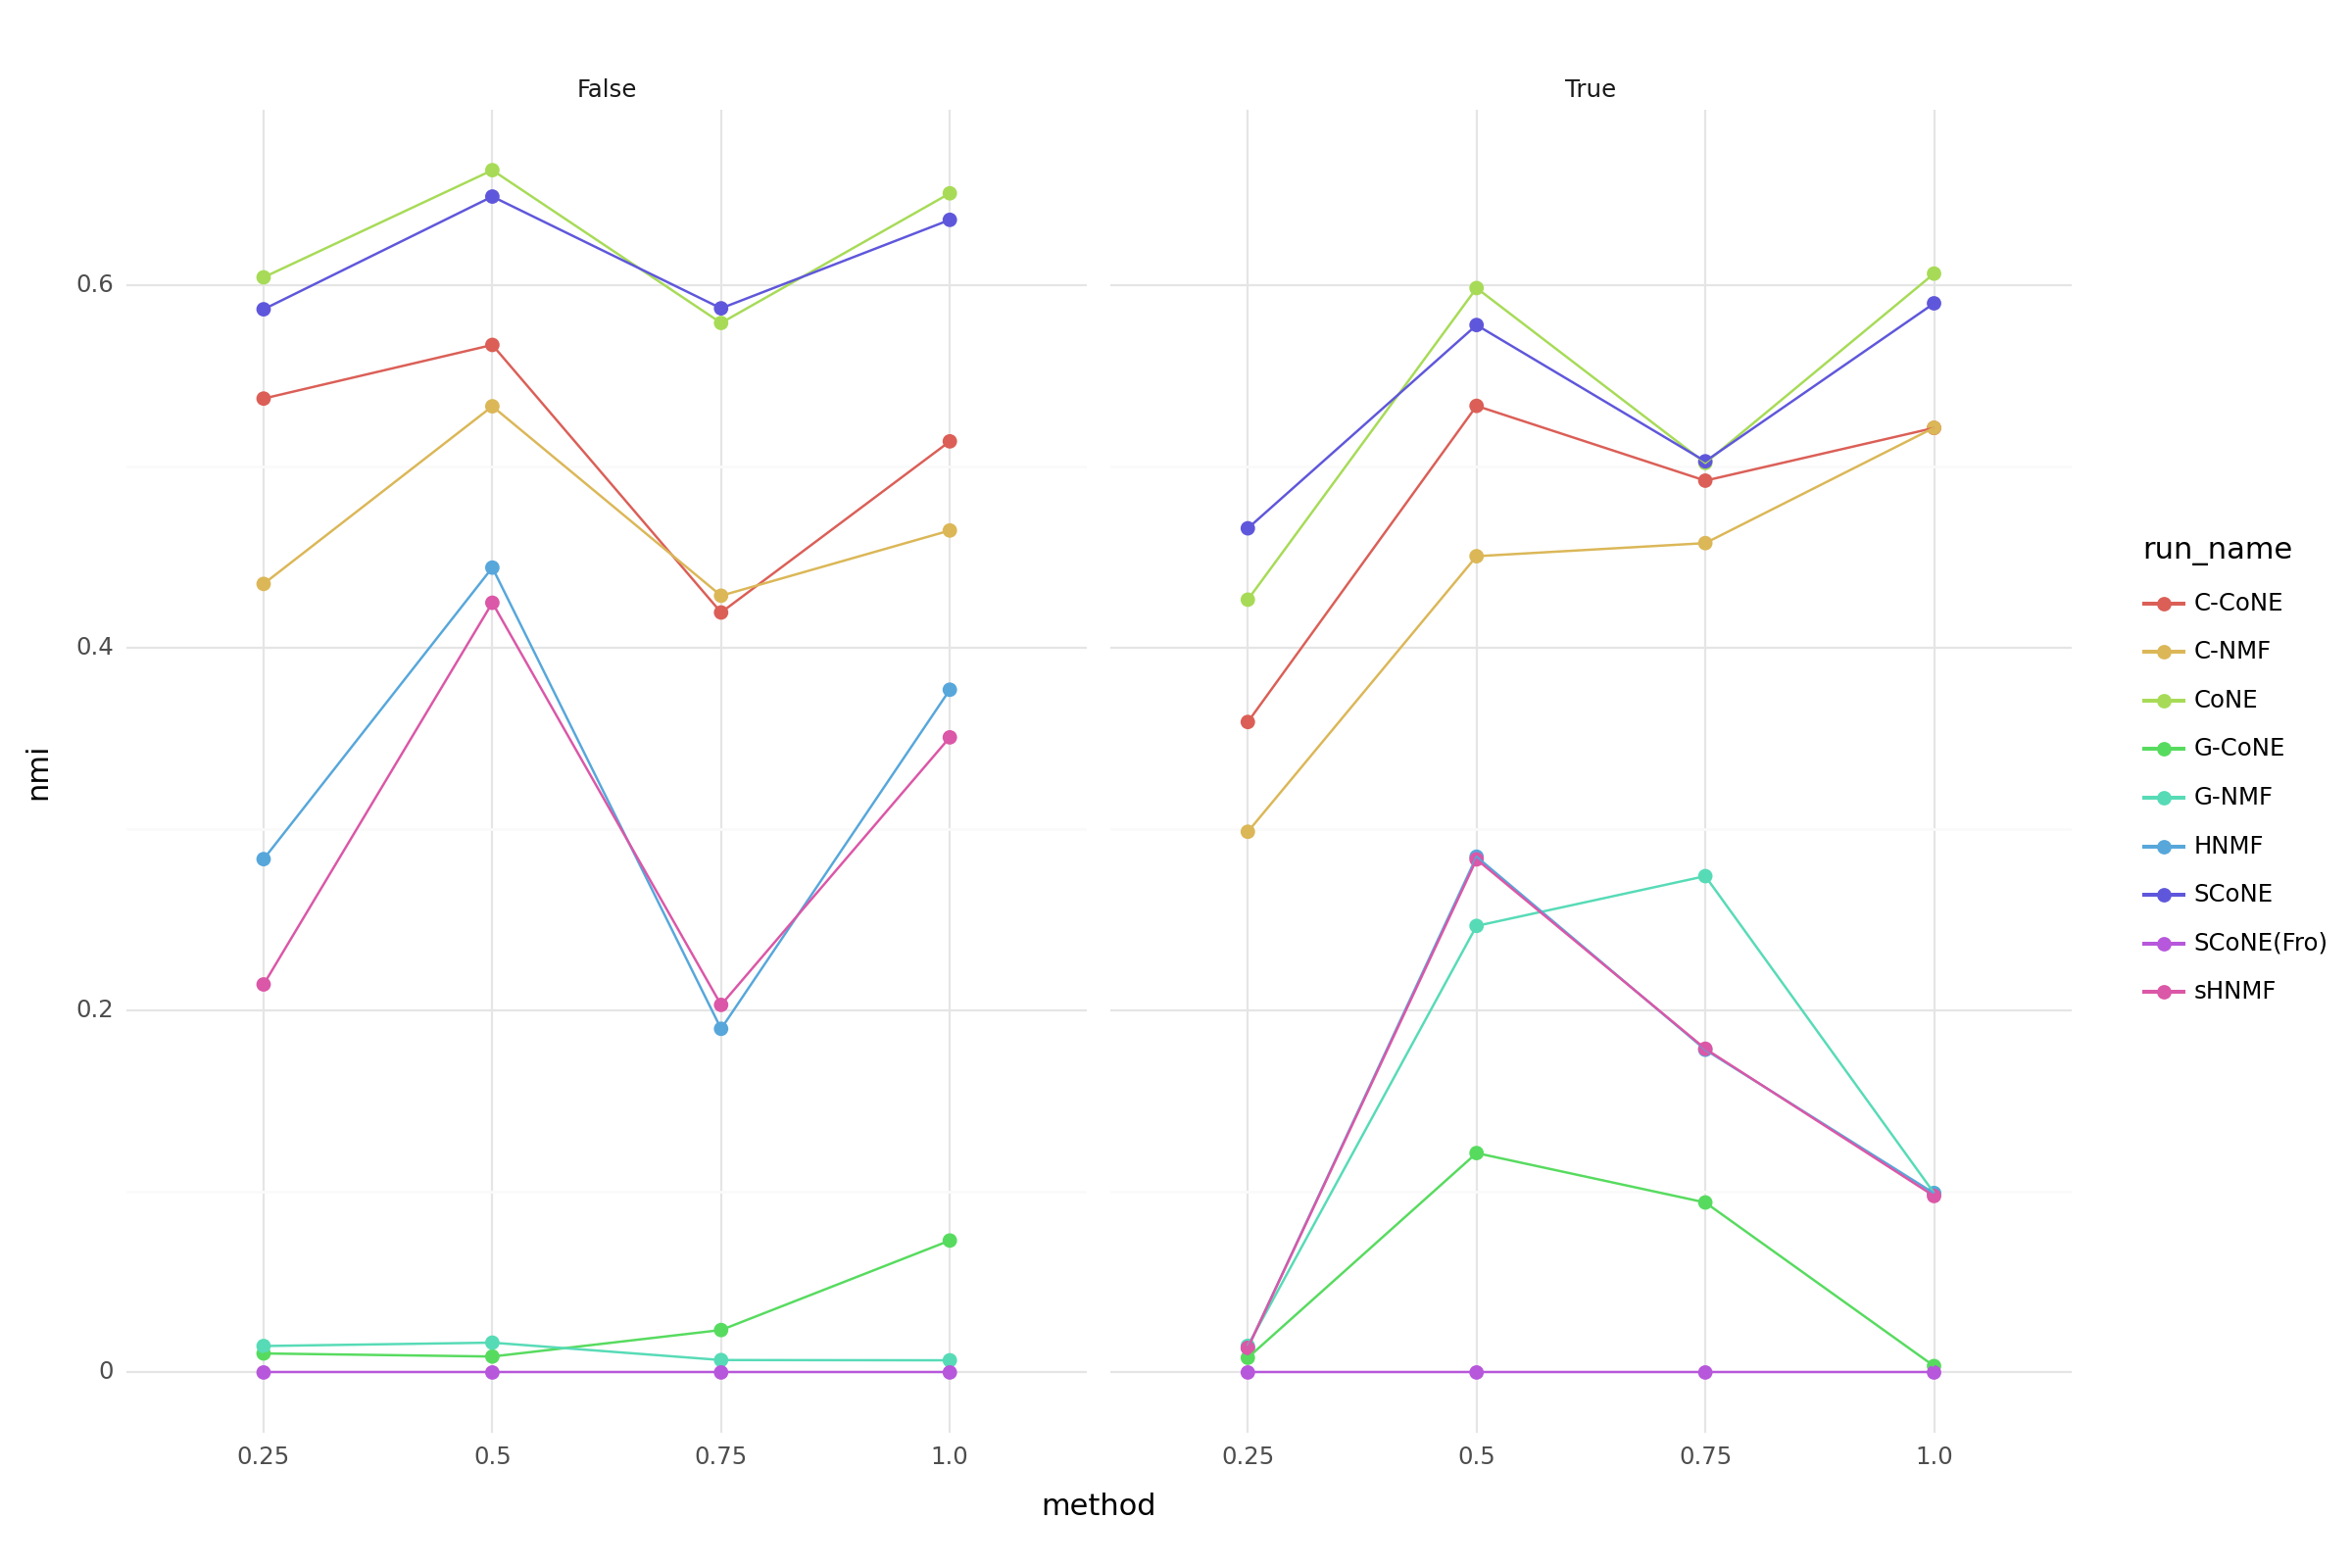

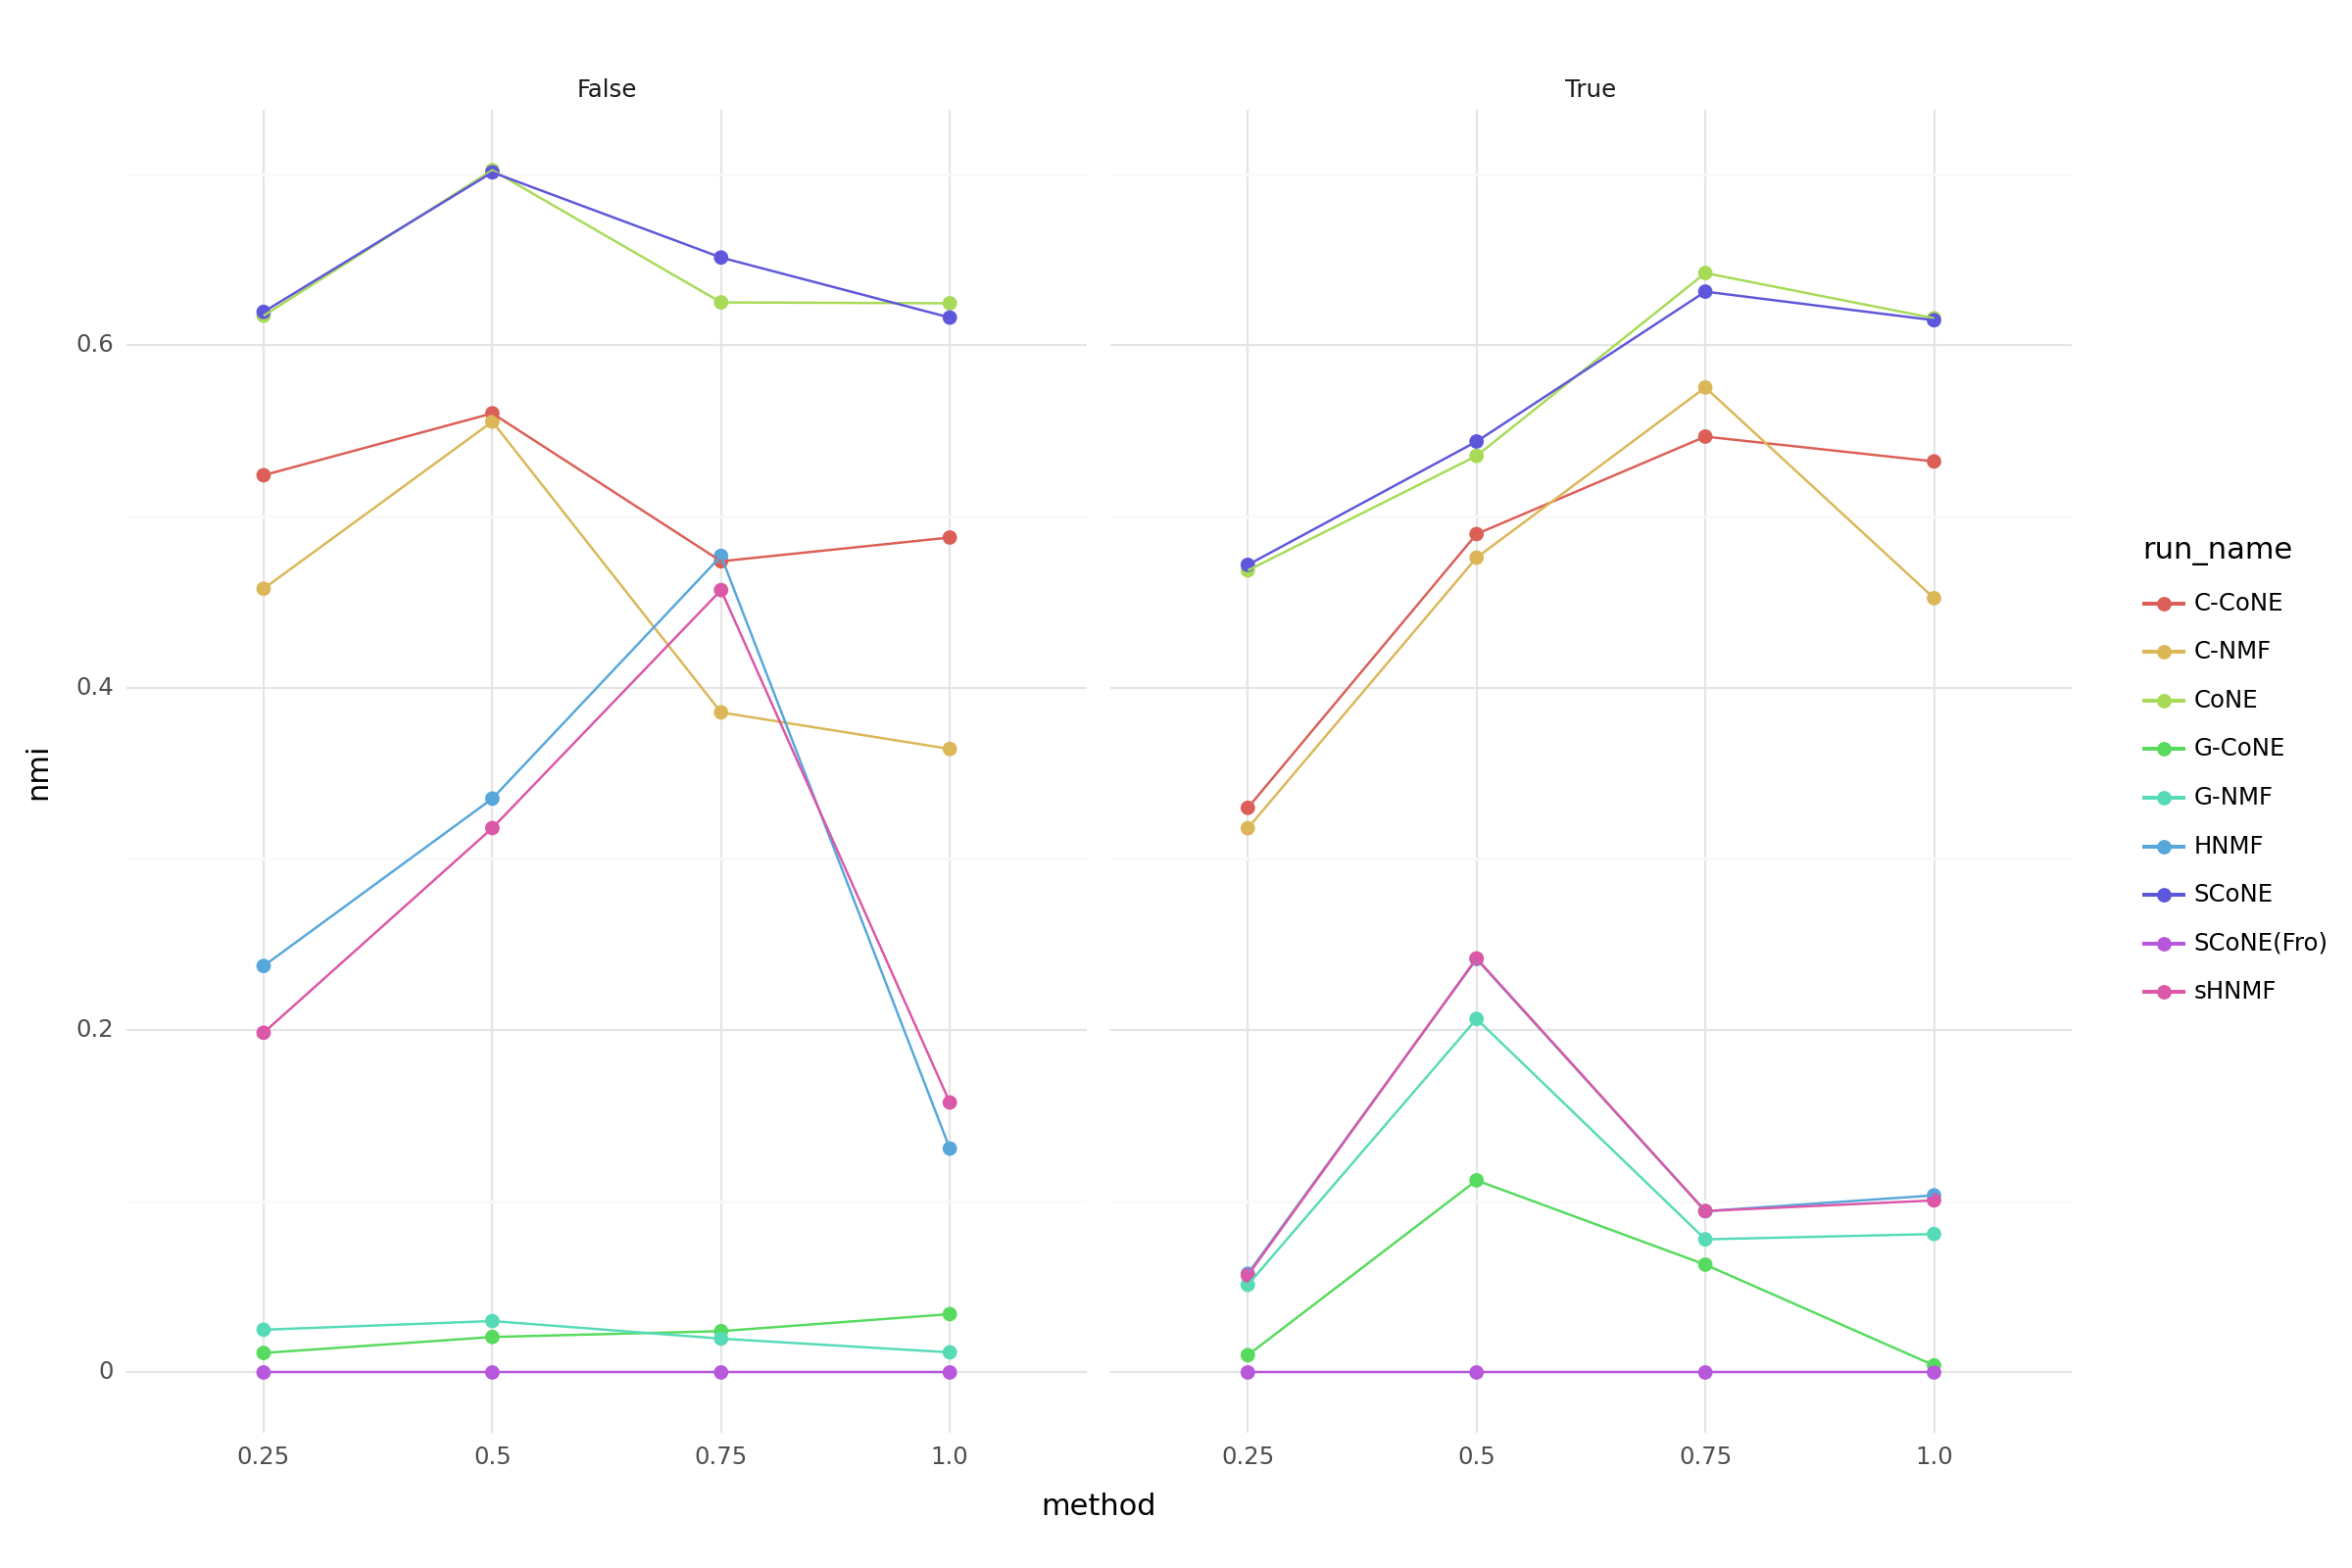

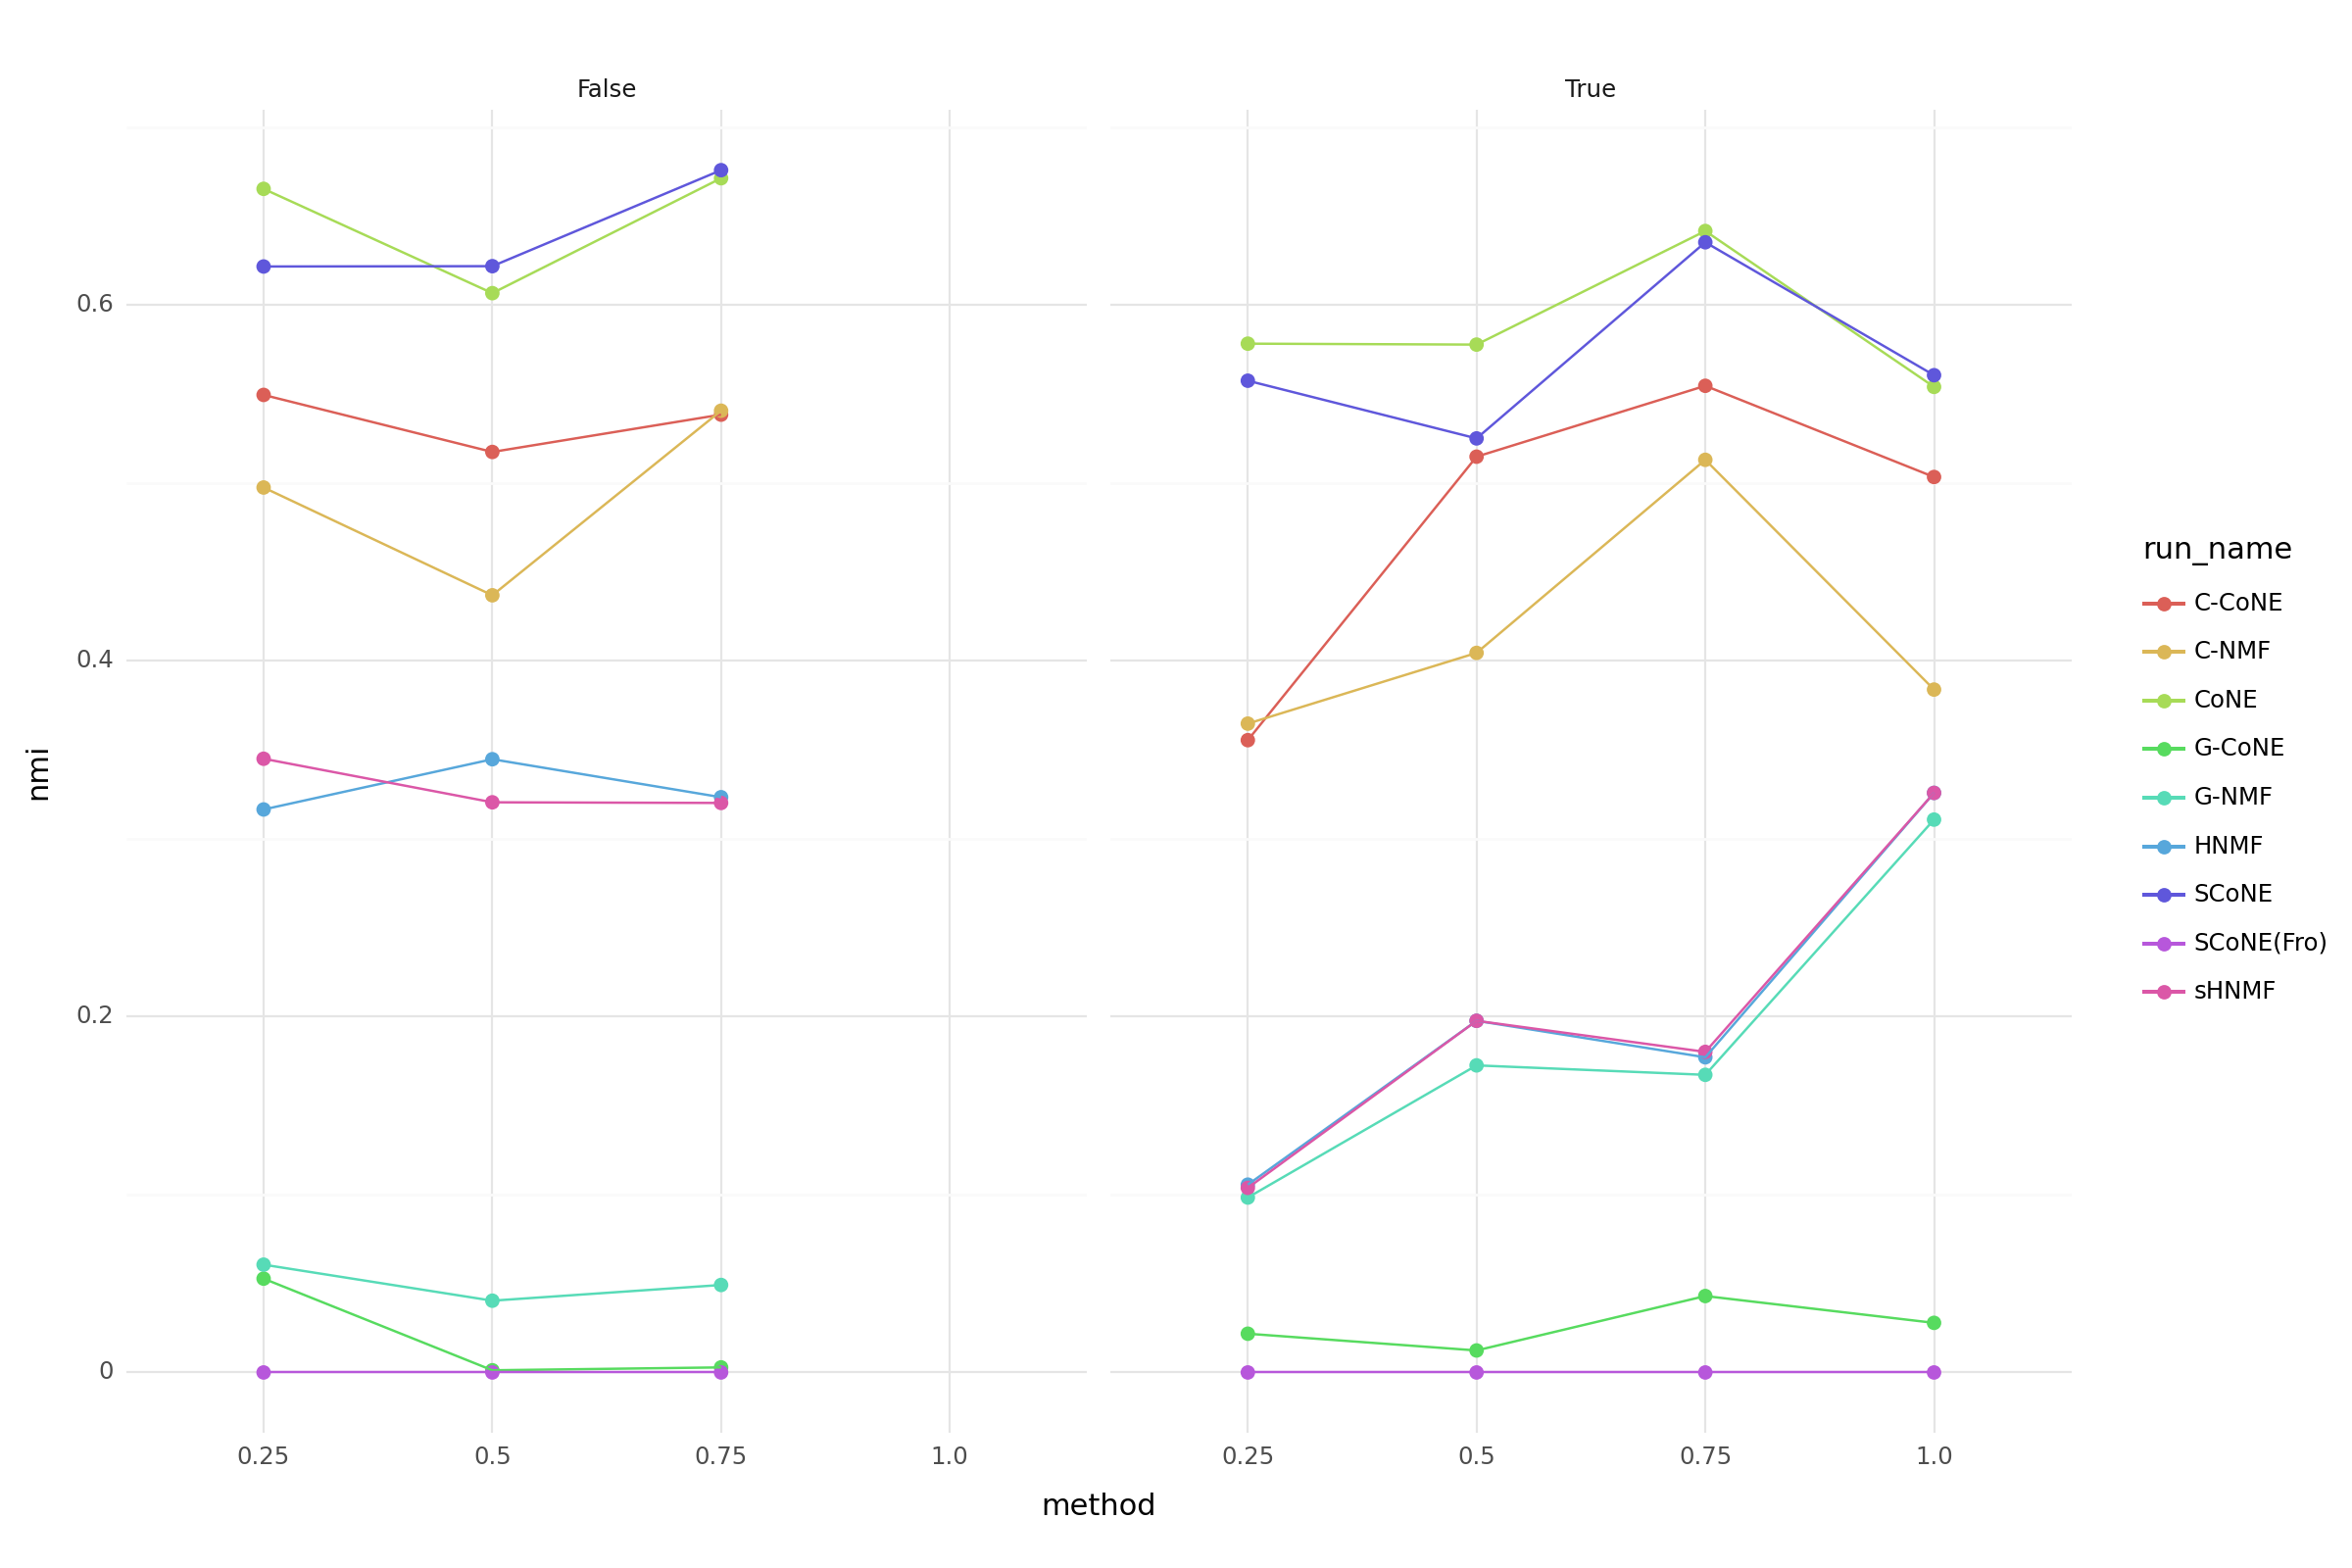

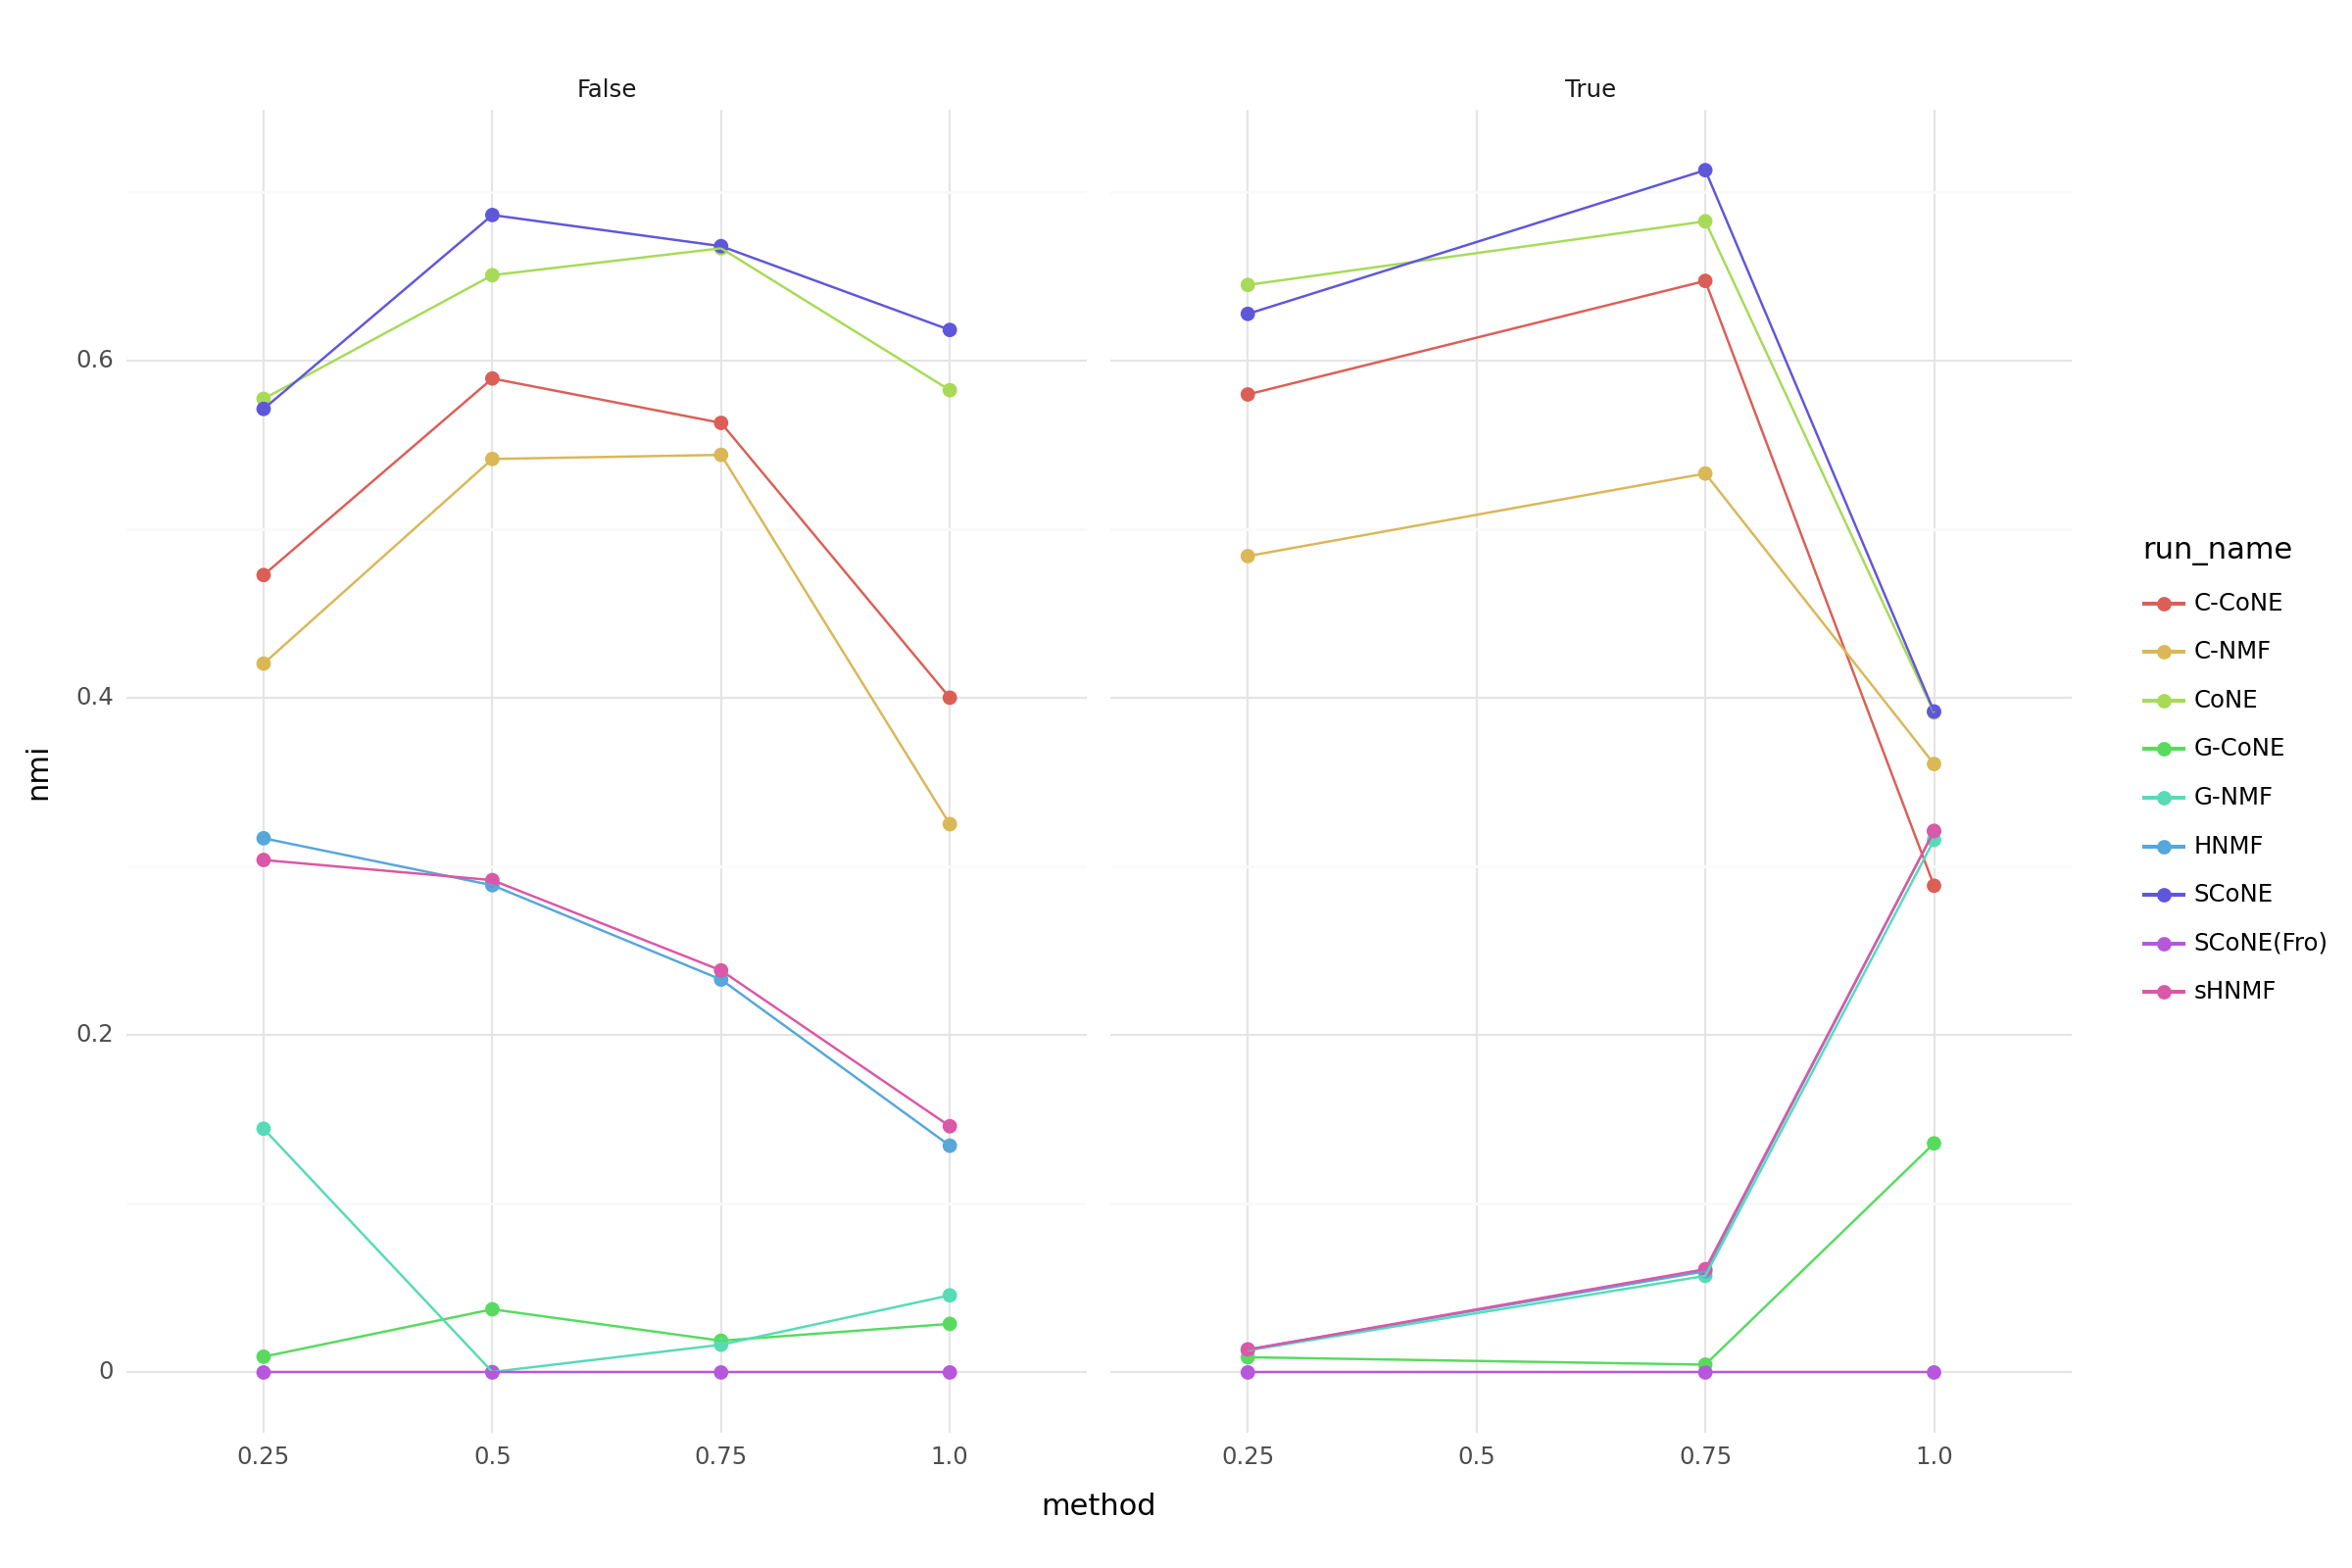

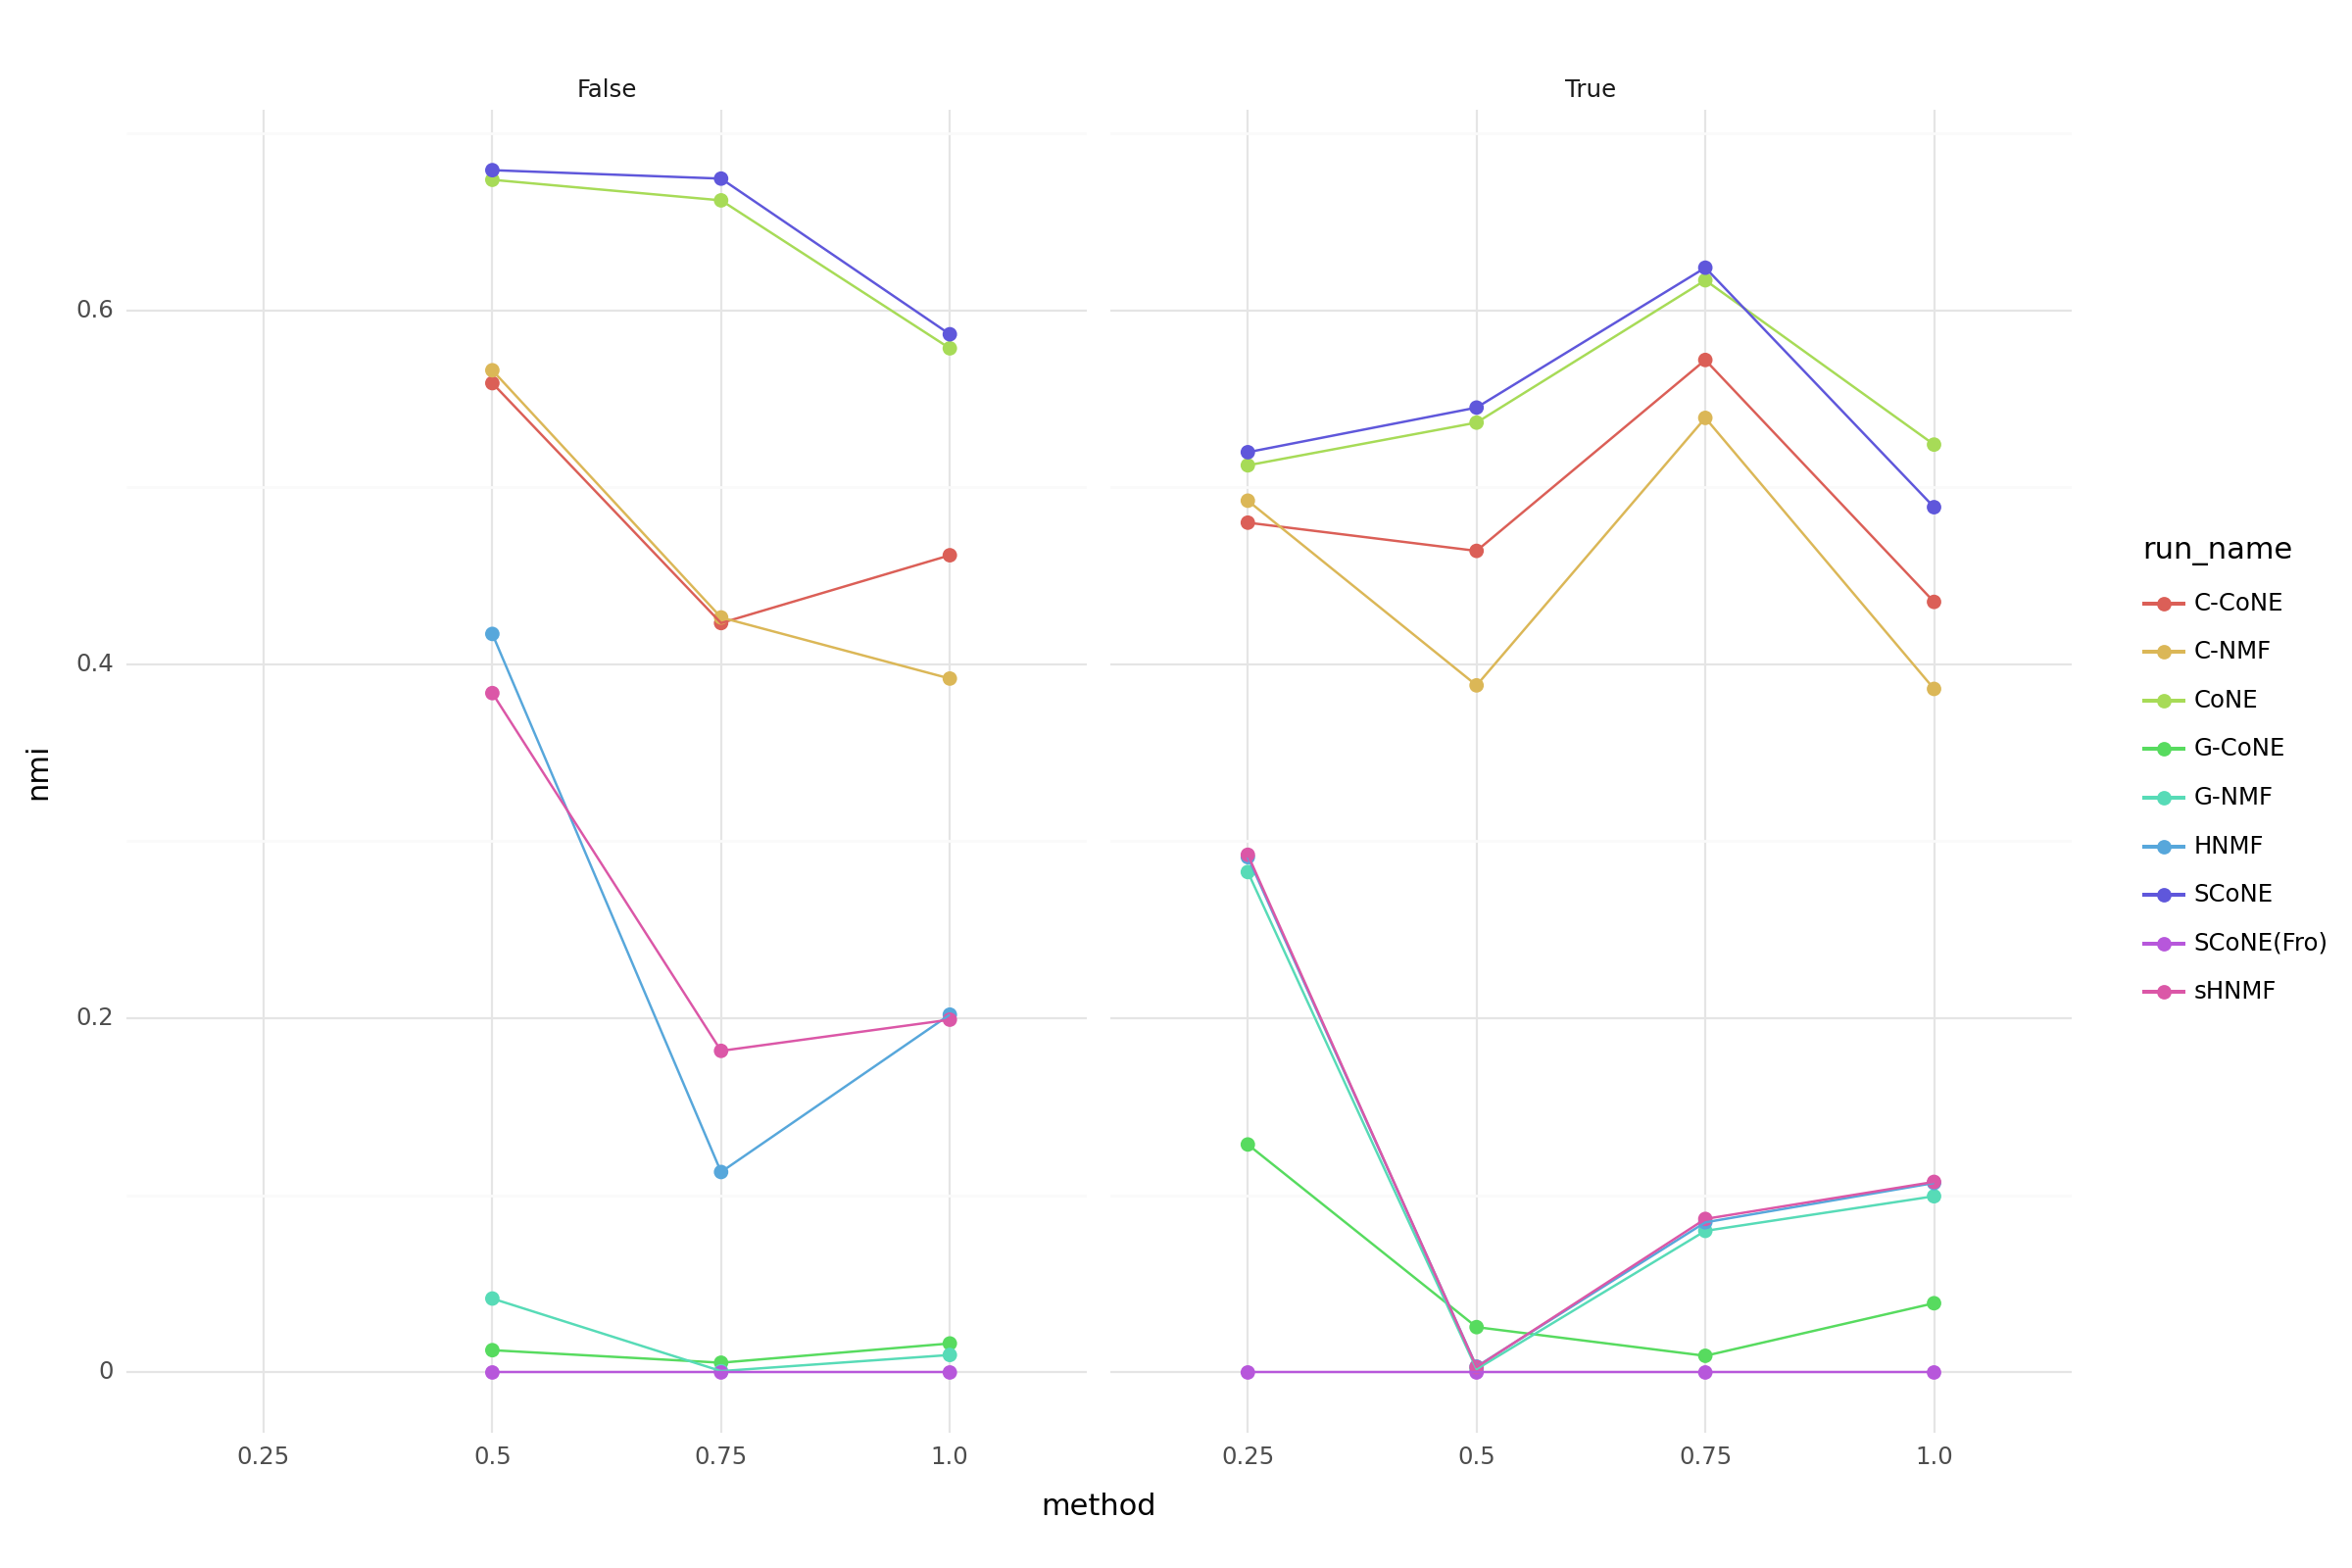

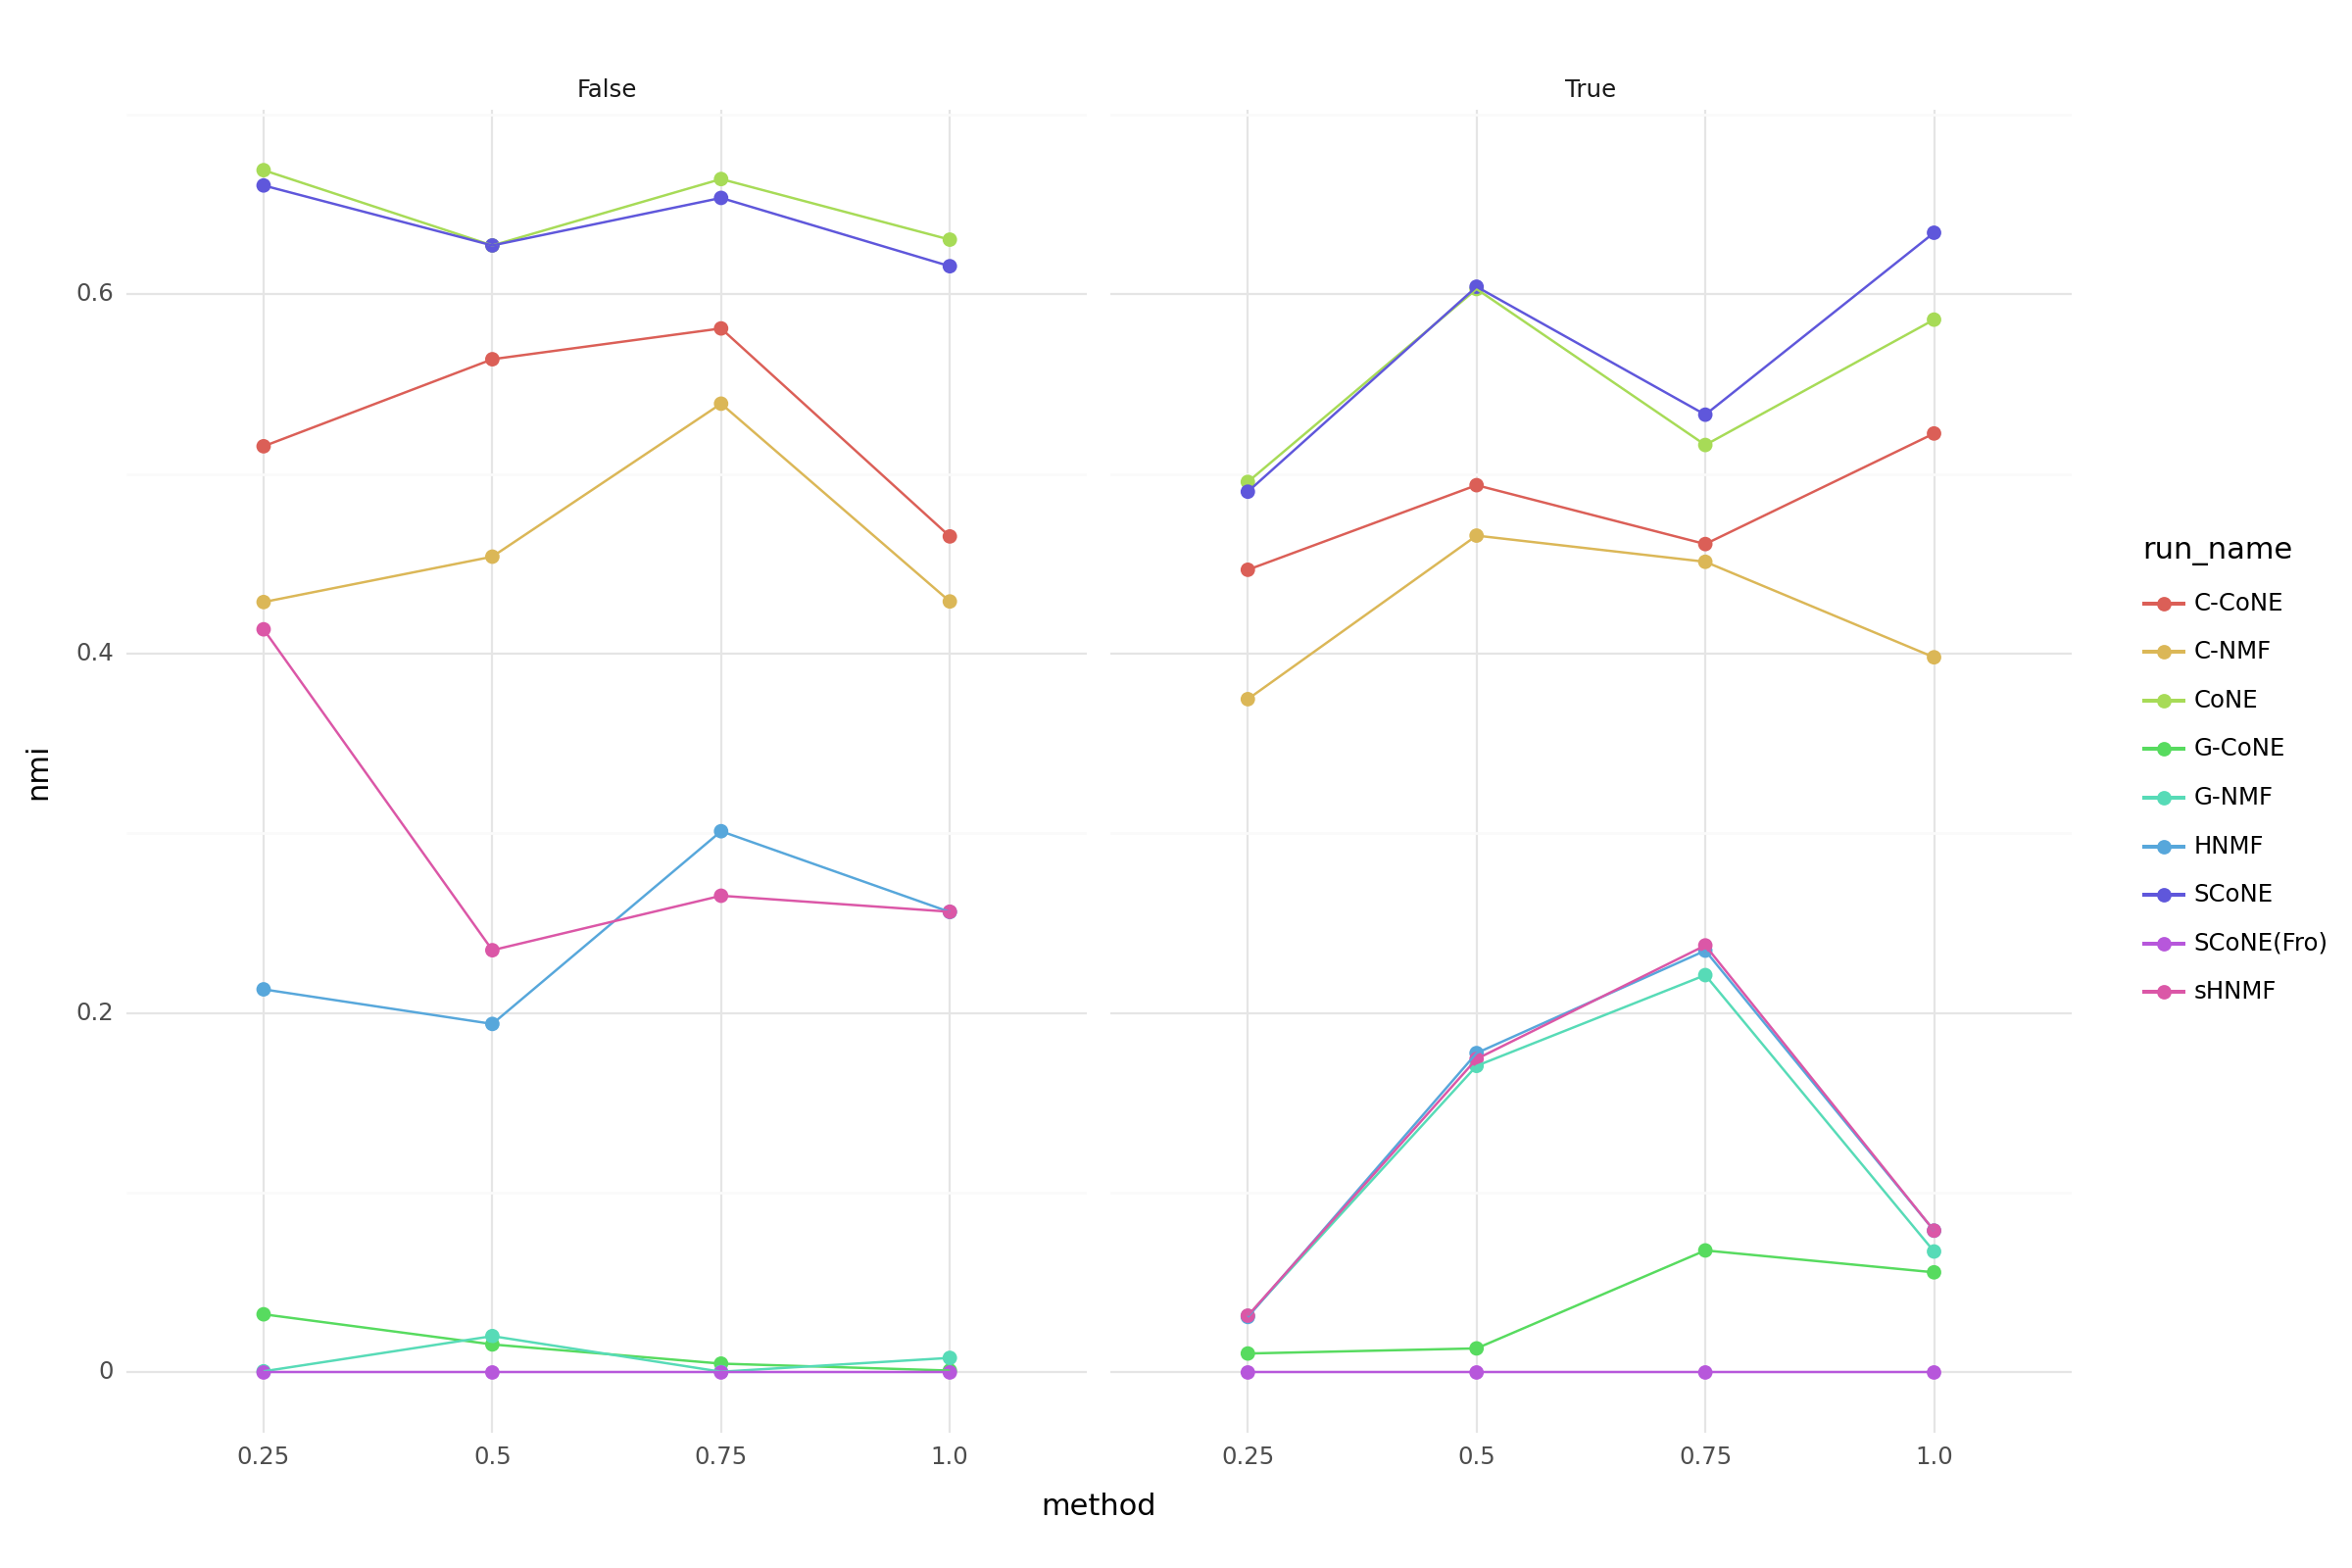

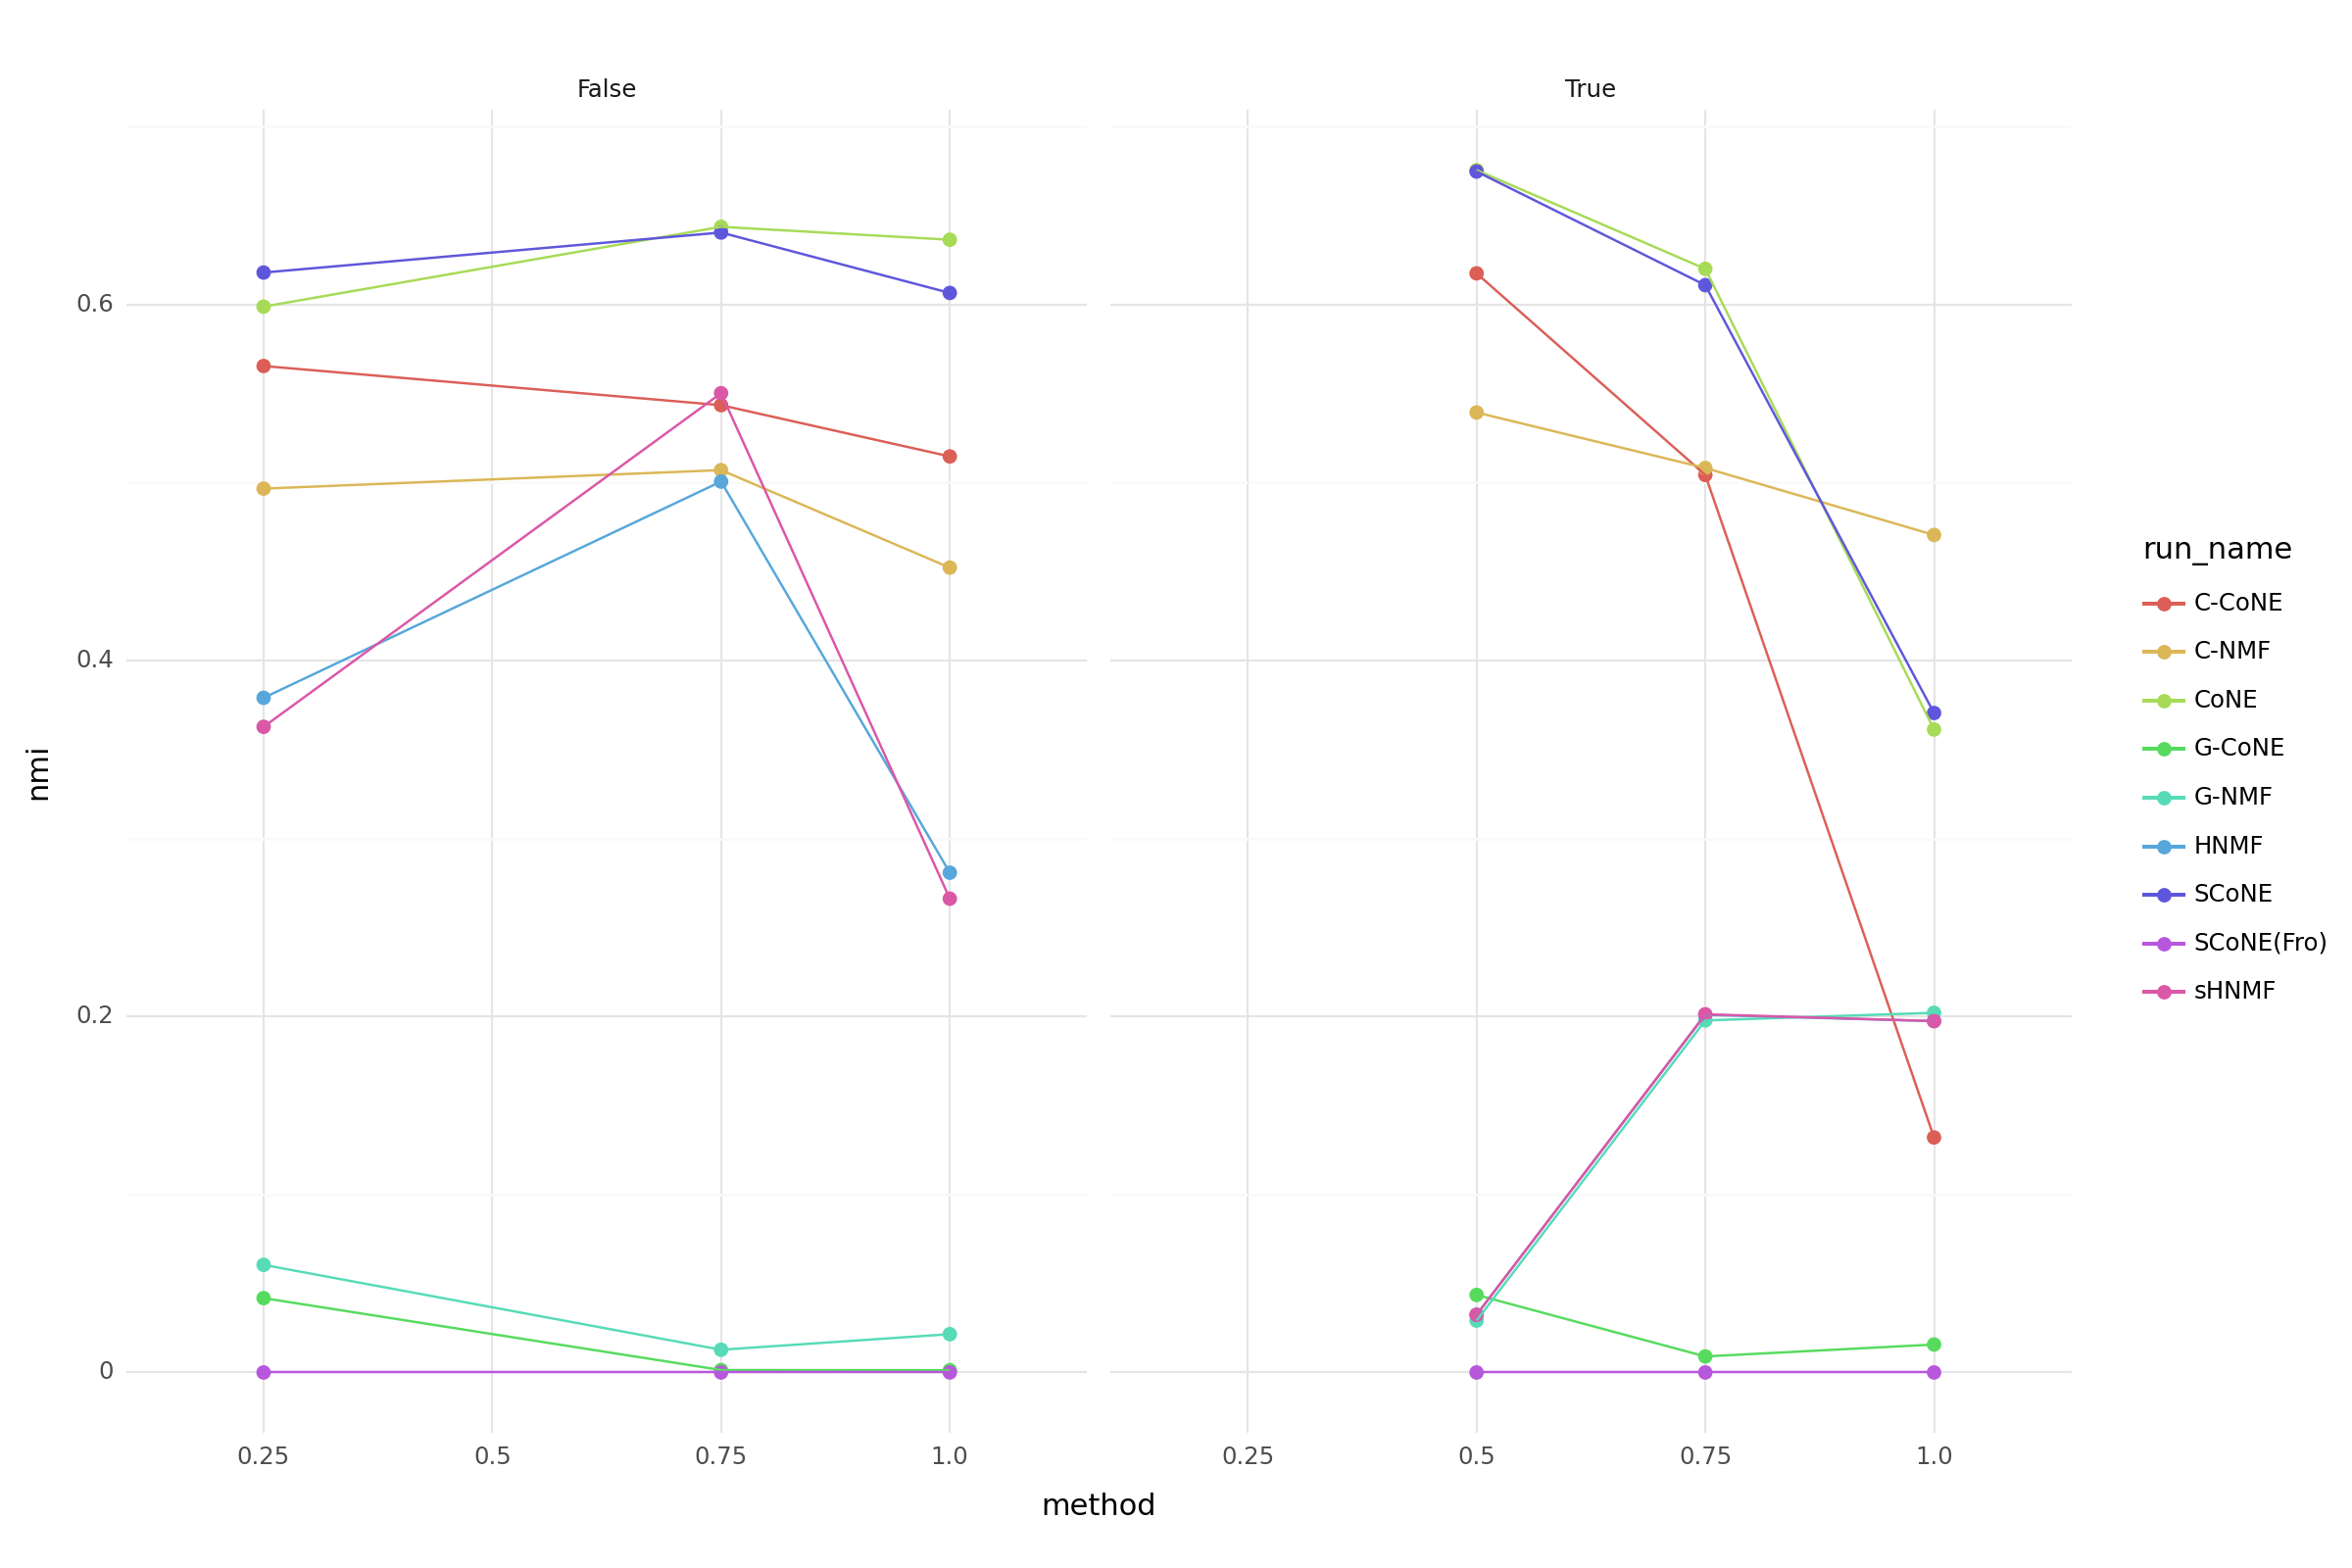

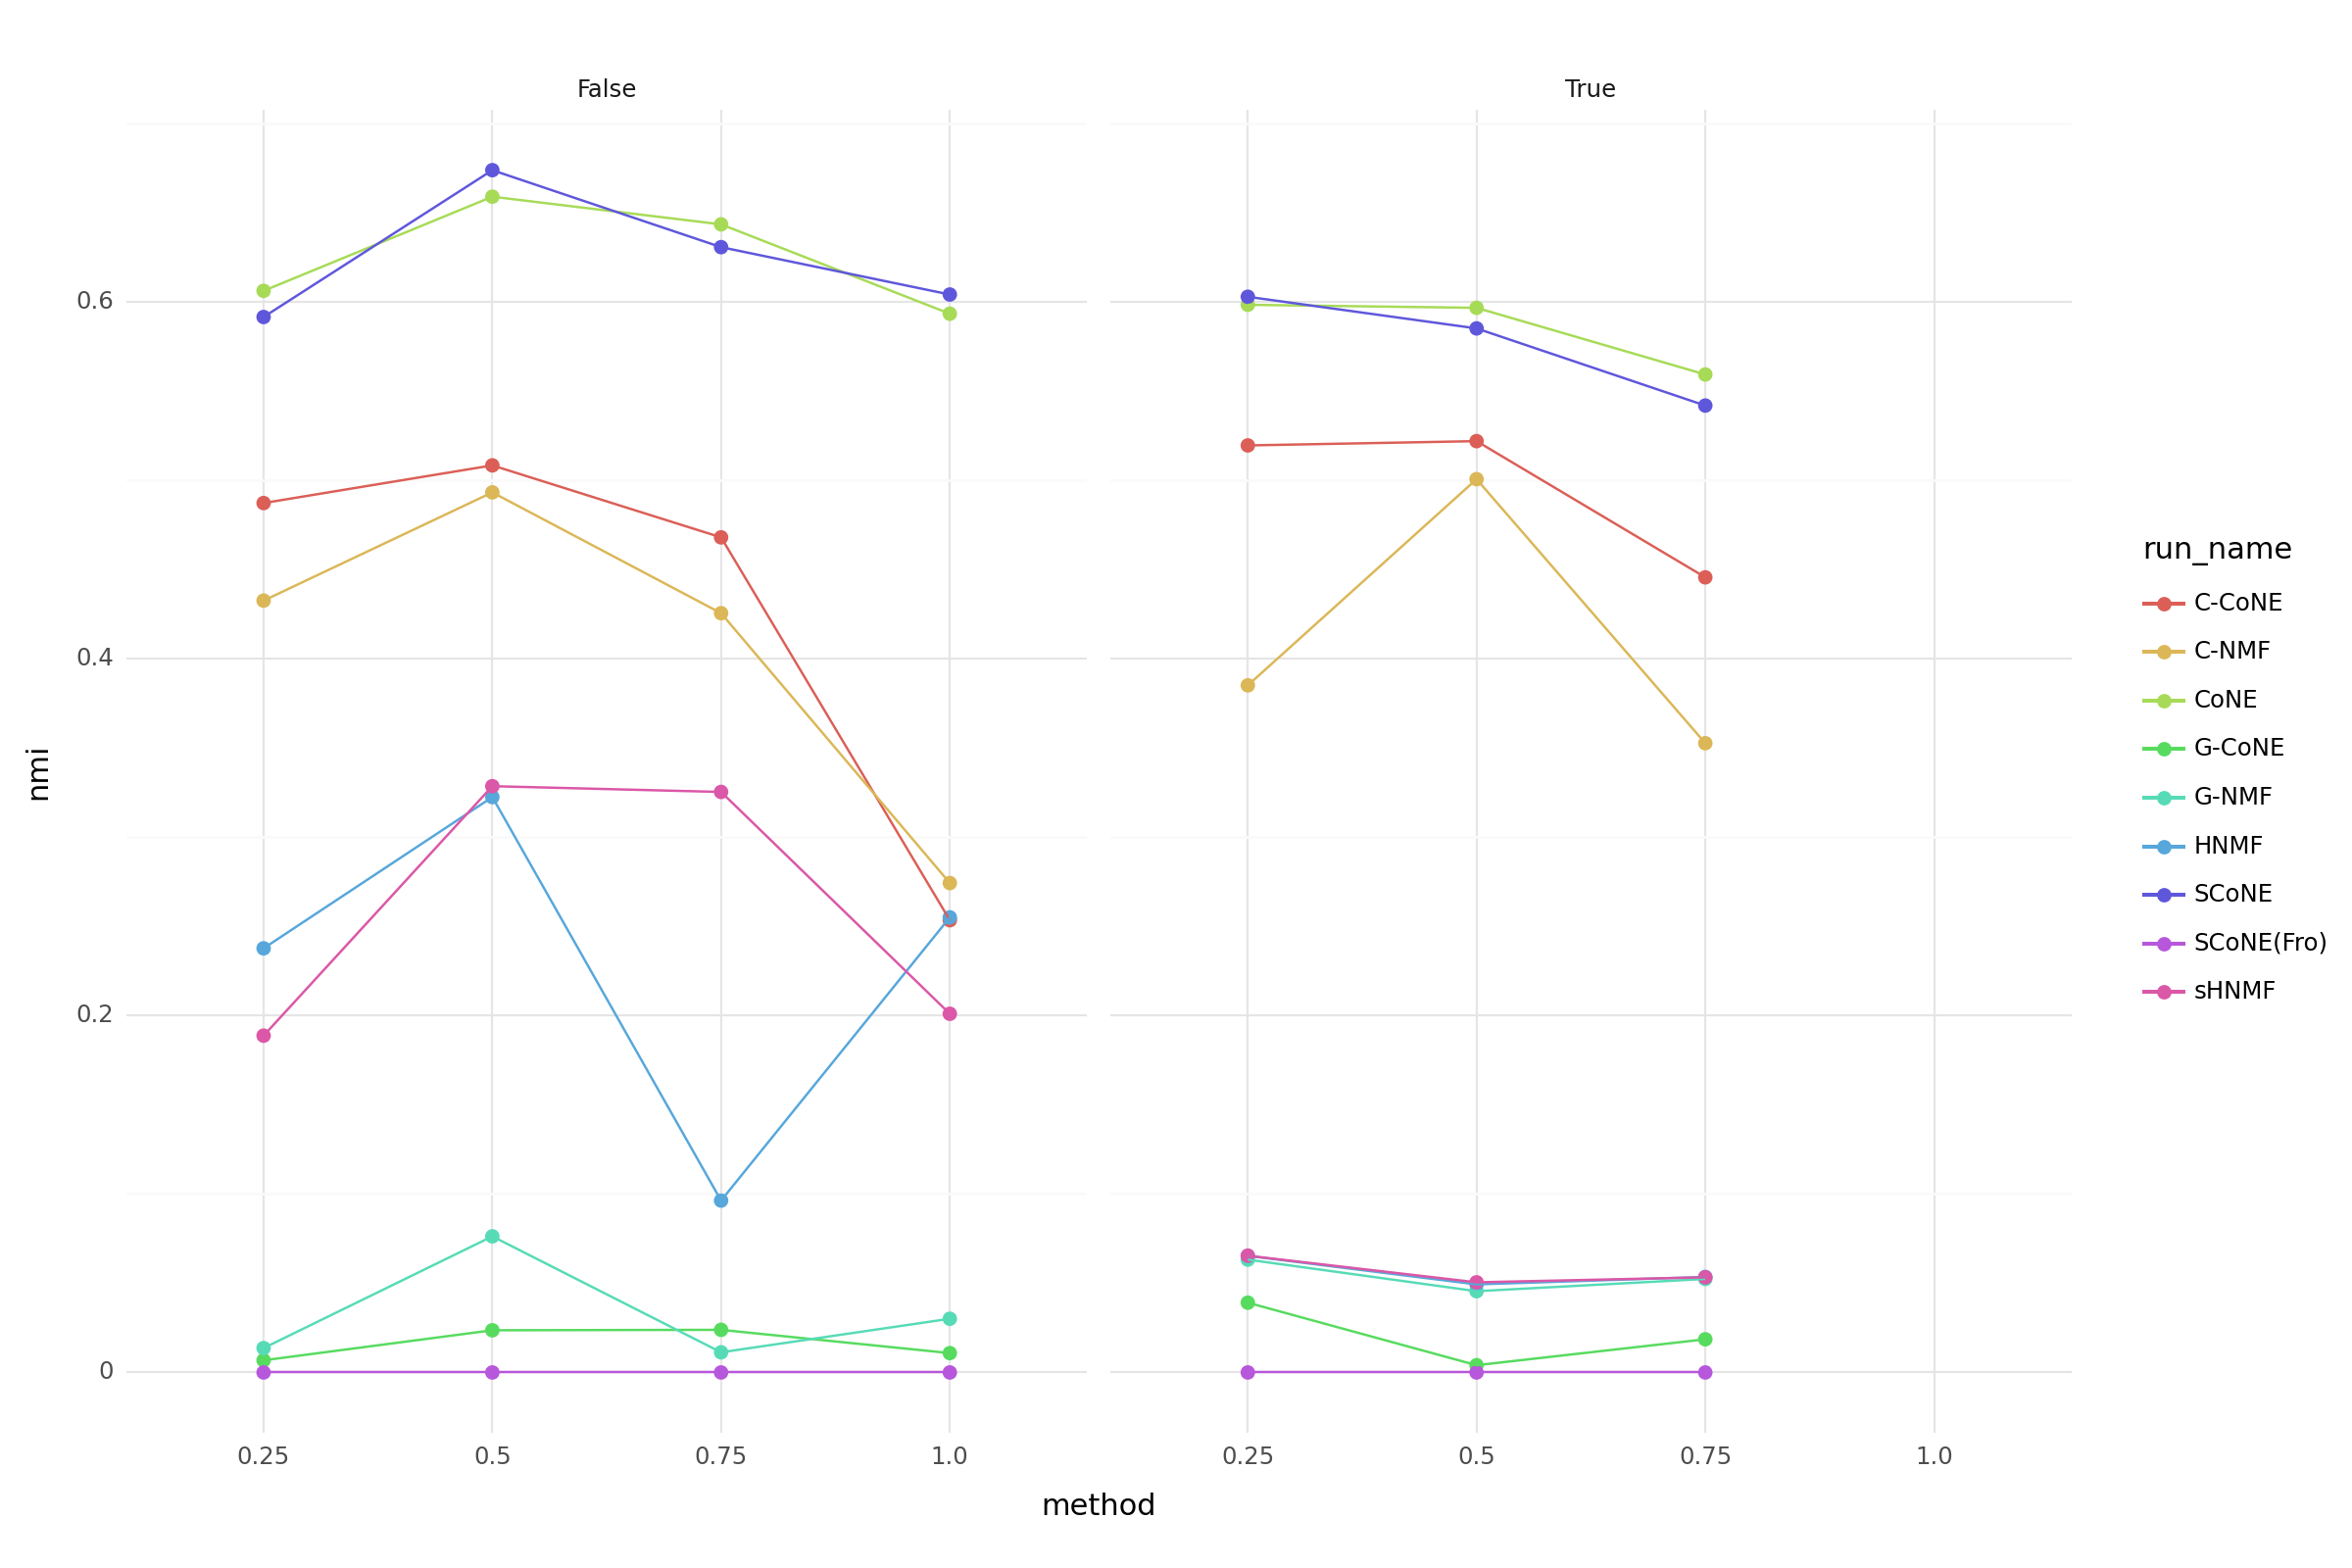

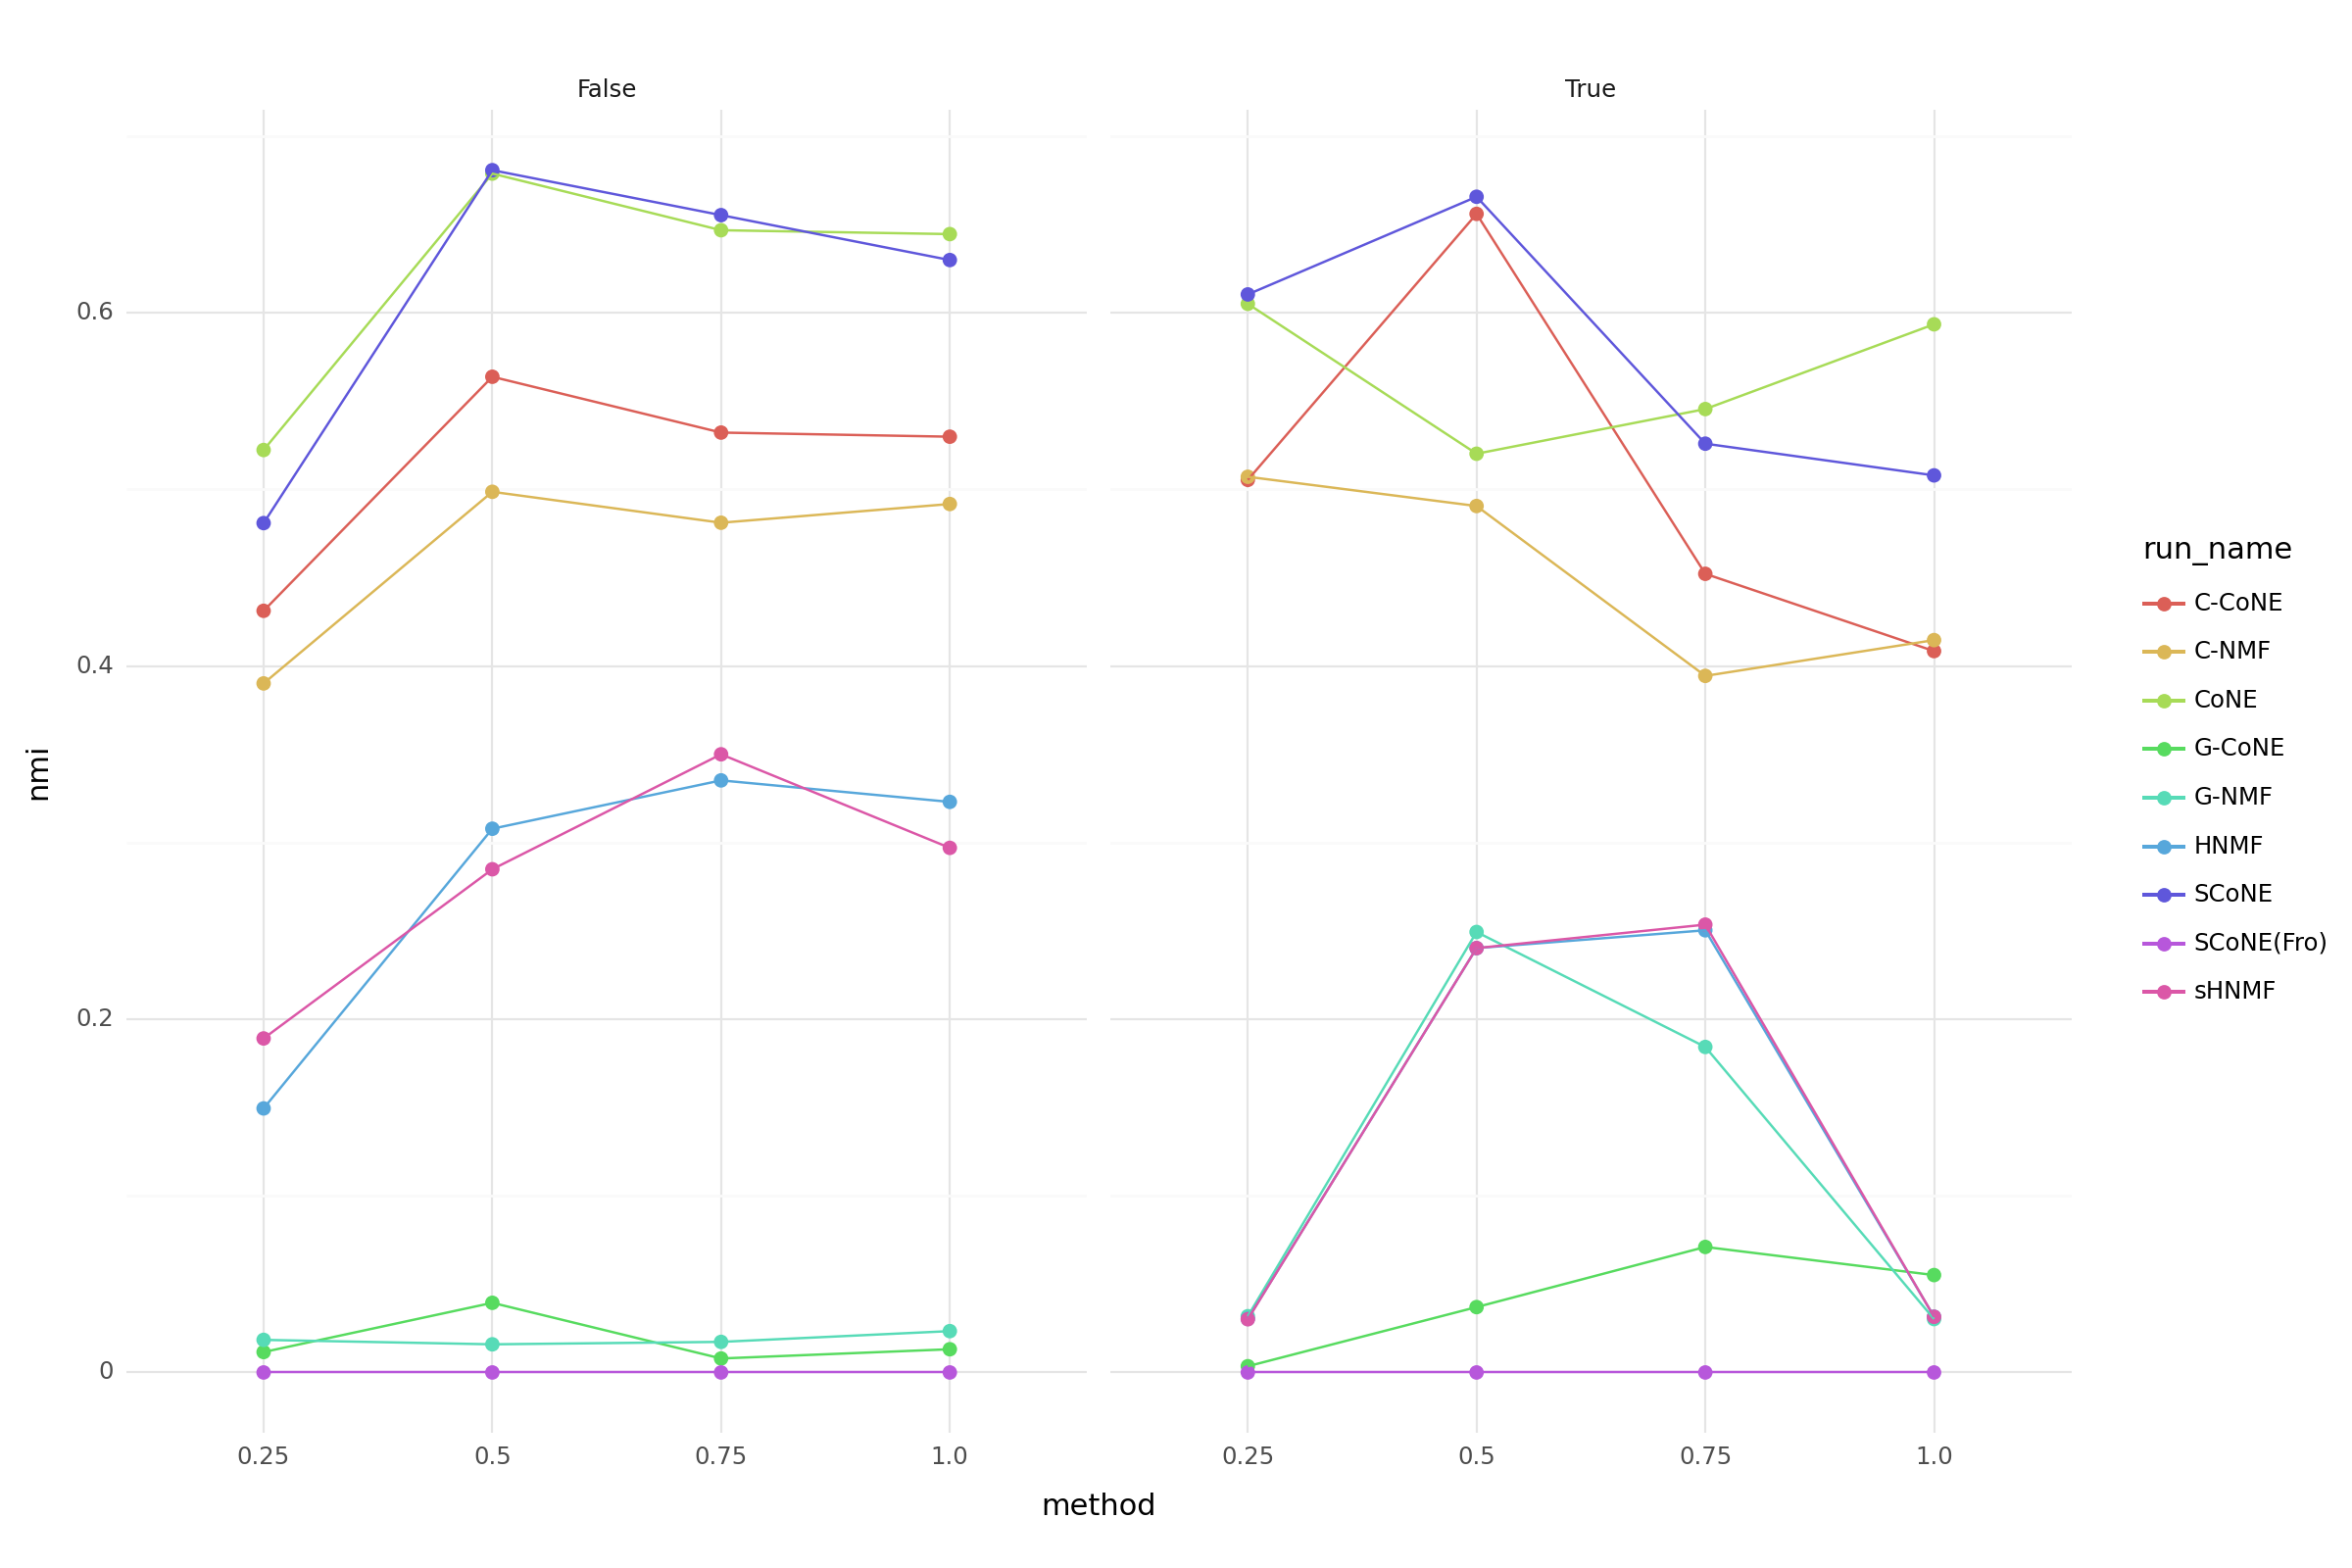

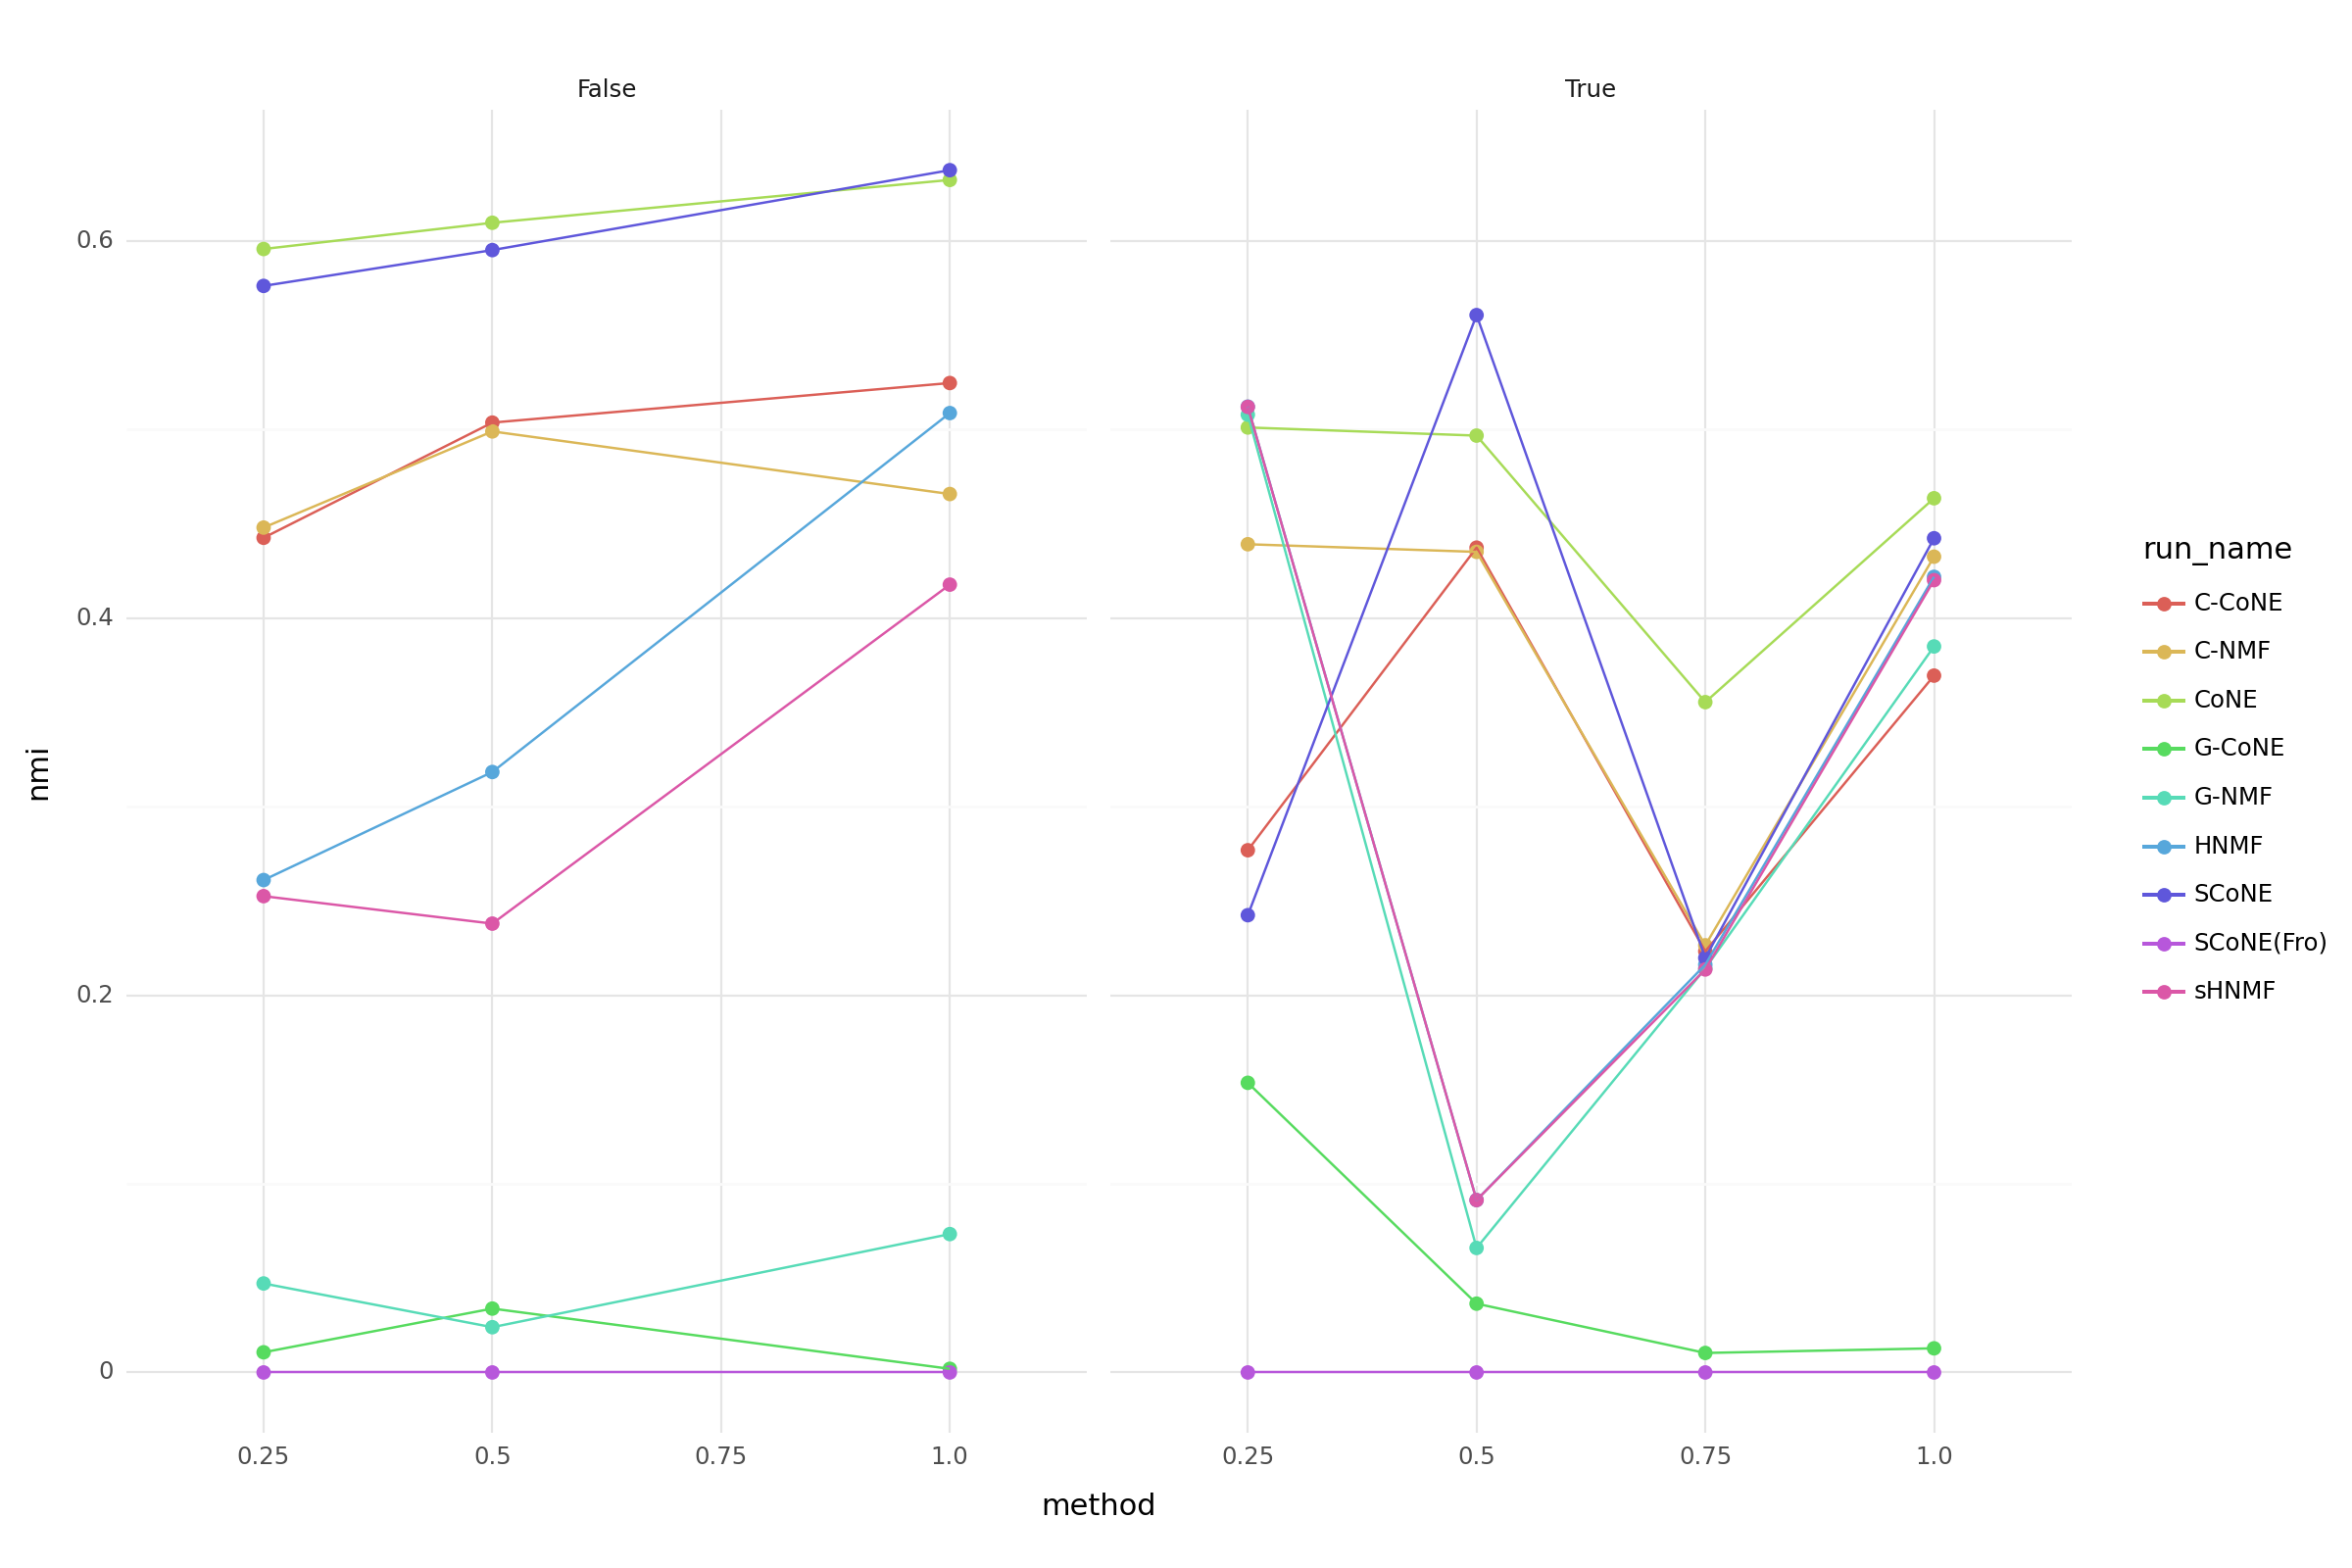

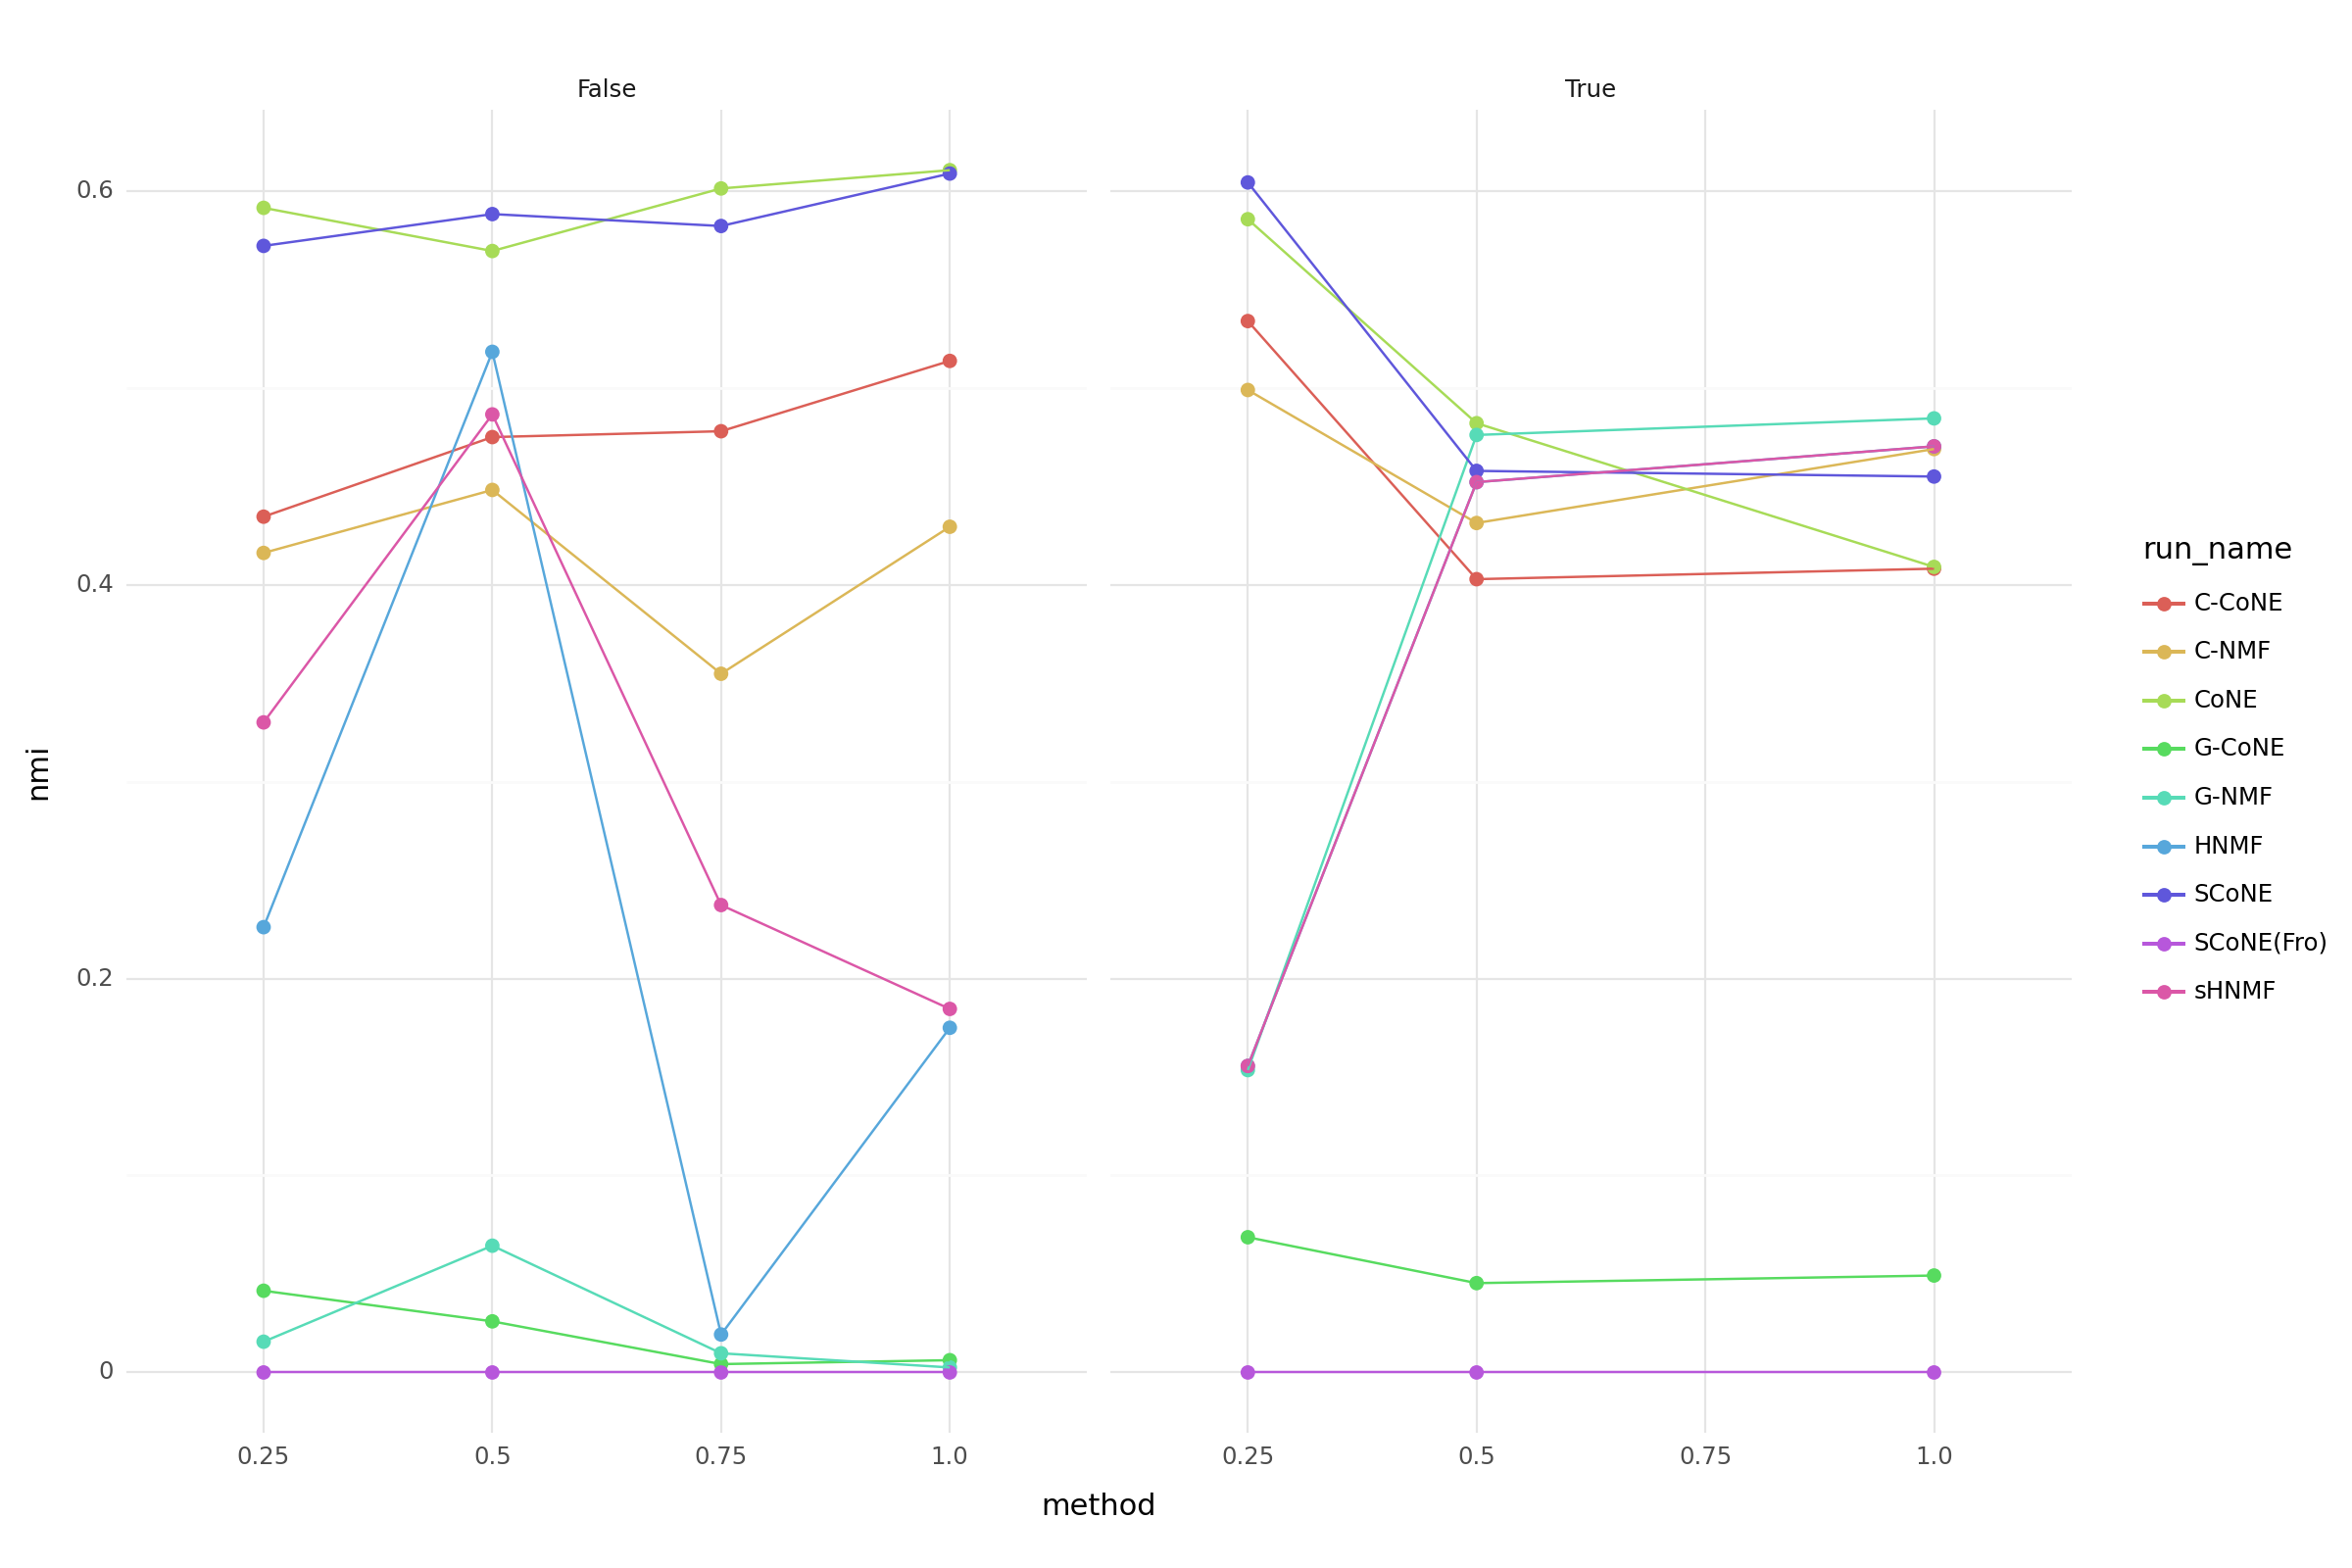

In [65]:
# get best model per total loss (since sparsity params fixed per run now) over initializations (within one experiment, dataset, run_name)
idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","run_name", "ps", "e", "g"])
      .reset_index(drop=True)
)
dodge = position_dodge(width=0.35)

# get CI over 10 random datasets
for dataset in range(11):
    dataset_best = best[best['dataset']==str(dataset)].copy()
    for metric in ['nmi']:
        p = (
        ggplot(dataset_best, aes(x="factor(e)", y=metric, color="run_name", group="run_name"))
        + geom_point(size=2)
        + geom_line()
        + labs(x="method", y=metric, title='')
        + facet_wrap('ps')
        + theme_minimal()
        + theme(figure_size=(12,8))
        )
        print(p)


In [54]:
all_runs['dataset']=='10'


0       False
1       False
2       False
3       False
4       False
        ...  
7195    False
7196    False
7197    False
7198     True
7199    False
Name: dataset, Length: 7200, dtype: bool